# Bangkok Traffic — Colab แบบไฟล์เดียว

เปิดไฟล์นี้ใน Google Colab แล้วเลือก **Runtime → Run all** จากนั้นอัปโหลด Excel ที่มีชีต `traffic_data` ไม่ต้องอัปโหลดโฟลเดอร์ src หรือใช้ Notebook เก่า

กติกาเดิม: ใช้ covid_period จากไฟล์; Date/month/year เป็นวันที่รายงาน; ช่องว่างและ - ของจำนวนรถเป็น 0; เก็บต้นฉบับและบันทึกค่าที่แทน วิเคราะห์เฉพาะชุดที่จับคู่ได้ ผลยังเป็นฉบับร่าง

In [1]:
from pathlib import Path
import os, sys, importlib.util, subprocess
packages = {'pandas':'pandas', 'numpy':'numpy', 'openpyxl':'openpyxl', 'matplotlib':'matplotlib', 'seaborn':'seaborn'}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
from IPython.display import display, Image, Markdown
import pandas as pd
IN_COLAB = 'google.colab' in sys.modules
if not IN_COLAB:
    try:
        import google.colab
        IN_COLAB = True
    except ImportError:
        pass
ROOT = (Path('/content') if IN_COLAB else Path.cwd()) / 'bangkok_traffic_project'
for folder in ['data/raw', 'data/interim', 'data/processed', 'outputs/current_audit', 'outputs/eda/figures']:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_rows', 12)
pd.set_option('display.max_columns', 10)

## เลือก Excel
บน Colab จะมีปุ่มอัปโหลด ถ้ารันในคอมพิวเตอร์ให้กรอก INPUT_PATH หรือกำหนด environment variable TRAFFIC_INPUT ไม่ต้องย้ายโฟลเดอร์โปรเจกต์

In [2]:
INPUT_PATH = ''  # Local example: r'C:/Downloads/traffic.xlsx'
chosen = INPUT_PATH or os.environ.get('TRAFFIC_INPUT', '')
if chosen:
    INPUT = Path(chosen).expanduser().resolve()
elif IN_COLAB:
    from google.colab import files
    uploaded = files.upload()
    excel_files = [name for name in uploaded if name.lower().endswith('.xlsx')]
    if len(excel_files) != 1:
        raise ValueError('กรุณาอัปโหลดไฟล์ .xlsx เพียงหนึ่งไฟล์ แล้วรันเซลล์นี้ใหม่')
    INPUT = Path(excel_files[0]).resolve()
else:
    raise ValueError('กรุณากรอก INPUT_PATH เป็นพาธไฟล์ Excel ในเซลล์นี้')
if not INPUT.is_file():
    raise FileNotFoundError(f'ไม่พบไฟล์ Excel: {INPUT}')
with pd.ExcelFile(INPUT) as workbook:
    if 'traffic_data' not in workbook.sheet_names:
        raise ValueError('ไฟล์นี้ไม่มีชีต traffic_data')
print('Input:', INPUT.name)

Input: bangkok_traffic_2560_Present (NotFinal) (1).xlsx


## ฟังก์ชันตรวจข้อมูลและ matching
โค้ดรวมอยู่ใน Notebook นี้แล้ว ไม่ต้อง import โมดูลของโปรเจกต์จาก src

In [3]:
"""Reproducible feasibility audit. No traffic-volume EDA or charts."""
from pathlib import Path
import argparse, datetime, hashlib, json, re, shutil, unicodedata
import numpy as np
import pandas as pd

VEHICLES = ['passenger_car','pickup_van','large_bus','small_bus','truck','tuk_tuk']
PERIODS = ['ก่อนโควิด','โควิด','หลังโควิด']
THAI_MONTHS = ['ม.ค.','ก.พ.','มี.ค.','เม.ย.','พ.ค.','มิ.ย.','ก.ค.','ส.ค.','ก.ย.','ต.ค.','พ.ย.','ธ.ค.']

def normalize(value):
    if pd.isna(value): return ''
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFC',str(value))).strip()

def survey_date(value):
    if pd.isna(value): return pd.NaT
    if isinstance(value,(datetime.date,datetime.datetime,pd.Timestamp)):
        return pd.Timestamp(value).normalize()
    text=normalize(value).translate(str.maketrans('๐๑๒๓๔๕๖๗๘๙','0123456789'))
    text=re.sub(r'\s*/\s*','/',text)
    match=re.search(r'(\d{1,2})\s*([ก-๙.]+)\s*(\d{2,4})',text)
    if match:
        day,month,year=match.groups(); year=int(year)
        if year<100: year+=2500
        if year>2400: year-=543
        try: return pd.Timestamp(year=year,month=THAI_MONTHS.index(month)+1,day=int(day))
        except ValueError: return pd.NaT
    # This workbook uses explicit day/month/year text (e.g. 29/5/2026).
    if re.fullmatch(r"\d{1,2}/\d{1,2}/\d{4}",text):
        return pd.to_datetime(text,format="%d/%m/%Y",errors="coerce")
    # ISO dates remain supported.
    if re.fullmatch(r'\d{4}-\d{2}-\d{2}(?:[ T].*)?',text):
        return pd.to_datetime(text,errors='coerce')
    return pd.NaT

def time_bounds(value):
    found=re.findall(r'(\d{1,2})[.:](\d{2})',normalize(value))
    if len(found)!=2: return None,None,None
    values=[int(h)*60+int(m) for h,m in found]
    if any(int(h)>23 or int(m)>59 for h,m in found) or values[1]<=values[0]:
        return None,None,None
    return f'{values[0]//60:02d}:{values[0]%60:02d}',f'{values[1]//60:02d}:{values[1]%60:02d}',(values[1]-values[0])/60

def save_csv(frame,path): frame.to_csv(path,index=False,encoding='utf-8-sig')

def matching(frame,keys):
    usable=frame.loc[frame.covid_period.isin(PERIODS)].dropna(subset=keys)
    matrix=usable.groupby(keys+['covid_period'],dropna=False).size().unstack(fill_value=0).reindex(columns=PERIODS,fill_value=0)
    complete=matrix.loc[matrix.gt(0).all(axis=1)]
    joined=usable.merge(complete.reset_index()[keys],on=keys,how='inner',validate='many_to_one')
    return matrix,complete,joined

def run_audit(source,output=None):
    source=Path(source).resolve()
    output=Path(output or ROOT/'outputs/current_audit').resolve();output.mkdir(parents=True,exist_ok=True)
    source_hash=hashlib.sha256(source.read_bytes()).hexdigest()
    snapshots=ROOT/'data/raw';snapshots.mkdir(parents=True,exist_ok=True)
    snapshot=snapshots/f'traffic_{source_hash[:12]}.xlsx'
    if not snapshot.exists(): shutil.copyfile(source,snapshot)
    assert hashlib.sha256(snapshot.read_bytes()).hexdigest()==source_hash
    raw=pd.read_excel(snapshot,sheet_name='traffic_data')
    required=['id','survey_date','Date','month','year','covid_period','intersection','road','time_period']+VEHICLES
    missing=set(required)-set(raw.columns)
    if missing: raise ValueError(f'Missing required columns: {sorted(missing)}')
    d=raw.copy();d.insert(0,'source_excel_row',np.arange(2,len(d)+2))
    d['source_sha256']=source_hash;d['source_sheet']='traffic_data'
    d['intersection_key']=d.intersection.map(normalize);d['road_key']=d.road.map(normalize)
    # Keep the supplied covid_period, including unexpected labels for the audit.
    d['report_day']=pd.to_numeric(d.Date,errors='coerce')
    d['report_month']=pd.to_numeric(d.month,errors='coerce')
    d['report_year']=pd.to_numeric(d.year,errors='coerce')
    d['report_date']=pd.to_datetime(dict(year=d.report_year,month=d.report_month,day=d.report_day),errors='coerce')
    d['survey_date_parsed']=d.survey_date.map(survey_date)
    d['survey_month']=d.survey_date_parsed.dt.month
    d['survey_year']=d.survey_date_parsed.dt.year
    d['report_quarter']=((d.report_month-1)//3+1).where(d.report_month.between(1,12))
    bounds=d.time_period.map(time_bounds)
    d[['start_time','end_time','period_hours']]=pd.DataFrame(bounds.tolist(),index=d.index)
    d['time_key']=d.start_time.fillna('')+'-'+d.end_time.fillna('')
    changes=[];numeric_profile=[]
    for col in VEHICLES:
        text=d[col].map(normalize)
        zero=d[col].isna() | text.isin(['','-'])
        cleaned=pd.to_numeric(text.str.replace(',','',regex=False).mask(zero,'0'),errors='coerce')
        d[col+'_clean']=cleaned;d[col+'_zero_assumed']=zero
        for row in d.index[zero]: changes.append({'source_excel_row':int(d.at[row,'source_excel_row']),'field':col,'original_value':d.at[row,col],'replacement':0,'reason':'user_rule_missing_or_dash_is_zero'})
        numeric_profile.append(dict(field=col,blank=int((d[col].isna()|text.eq('')).sum()),dash=int(text.eq('-').sum()),zero_assumed=int(zero.sum()),unresolved=int(cleaned.isna().sum()),negative=int(cleaned.lt(0).sum()),fractional=int((cleaned.notna()&cleaned.mod(1).ne(0)).sum())))
    numeric=d[[c+'_clean' for c in VEHICLES]]
    d['has_assumed_zero']=d[[c+'_zero_assumed' for c in VEHICLES]].any(axis=1)
    d['numeric_unresolved']=numeric.isna().any(axis=1)
    d['numeric_negative']=numeric.lt(0).any(axis=1)
    d['numeric_fractional']=(numeric.notna()&numeric.mod(1).ne(0)).any(axis=1)
    d['exact_repeat']=raw.drop(columns='id').duplicated(keep='first')
    # Repeated survey observations can appear in different reports: audit, do not silently delete.
    survey_key=['survey_date_parsed','intersection_key','road_key','time_key']
    d['repeated_survey_key']=d.survey_date_parsed.notna() & d.duplicated(survey_key,keep=False)
    report_key=['report_year','report_month','report_day','intersection_key','road_key','time_key']
    d['repeated_report_key']=d.duplicated(report_key,keep=False)
    # Distinct report and survey dates are legitimate; neither equality nor a valid report day
    # is needed to match by report month. Day validity is retained as a separate finding.
    d['candidate_eligible']=(d.covid_period.isin(PERIODS)&d.report_month.between(1,12)&d.report_year.between(2017,2026)&d.period_hours.notna()&d.intersection_key.ne('')&d.road_key.ne('')&~d.numeric_unresolved&~d.numeric_negative&~d.numeric_fractional&~d.exact_repeat&~d.repeated_survey_key)
    candidate=d.loc[d.candidate_eligible].copy()
    matrices={};matched={};rows={};stats=[]
    definitions=[('raw_location',d,['intersection_key','road_key']),('candidate_location',candidate,['intersection_key','road_key']),('candidate_location_time',candidate,['intersection_key','road_key','time_key']),('candidate_report_month_time',candidate,['intersection_key','road_key','report_month','time_key']),('candidate_report_quarter_time',candidate,['intersection_key','road_key','report_quarter','time_key']),('candidate_survey_month_time',candidate,['intersection_key','road_key','survey_month','time_key'])]
    for name,frame,keys in definitions:
        matrix,complete,selected=matching(frame,keys)
        matrices[name]=matrix;matched[name]=complete;rows[name]=selected
        save_csv(matrix.reset_index(),output/f'{name}_coverage.csv')
        save_csv(complete.reset_index(),output/f'{name}_matched.csv')
        save_csv(selected[['source_excel_row','covid_period','intersection','road','report_year','report_month','report_day','survey_date_parsed','time_key','has_assumed_zero']],output/f'{name}_rows.csv')
        stats.append(dict(design=name,groups=len(complete),locations=selected[['intersection_key','road_key']].drop_duplicates().shape[0],intersections=selected.intersection_key.nunique(),rows=len(selected),before_rows=int(selected.covid_period.eq(PERIODS[0]).sum()),during_rows=int(selected.covid_period.eq(PERIODS[1]).sum()),after_rows=int(selected.covid_period.eq(PERIODS[2]).sum())))
    year_rows=[]
    for year,g in d.groupby('report_year'):
        observed=sorted(int(m) for m in g.report_month.dropna().unique())
        expected=list(range(3,13)) if year==2017 else list(range(1,6)) if year==2026 else list(range(1,13))
        year_rows.append(dict(report_year=int(year),rows=len(g),months_present=','.join(map(str,observed)),months_missing_within_scope=','.join(map(str,sorted(set(expected)-set(observed)))),locations=len(g[['intersection_key','road_key']].drop_duplicates()),assumed_zero_rows=int(g.has_assumed_zero.sum())))
    save_csv(pd.DataFrame(year_rows),output/'year_coverage.csv')
    save_csv(pd.DataFrame(stats),output/'matching_summary.csv')
    save_csv(pd.DataFrame(numeric_profile),output/'numeric_profile.csv')
    save_csv(pd.DataFrame(changes),output/'zero_assumption_log.csv')
    save_csv(d[['intersection','road','intersection_key','road_key']].drop_duplicates(),output/'location_normalization.csv')
    save_csv(d.loc[d.report_date.isna(),['source_excel_row','Date','month','year','survey_date']],output/'report_date_review.csv')
    save_csv(d.loc[d.numeric_unresolved|d.numeric_fractional|d.numeric_negative,['source_excel_row']+VEHICLES],output/'numeric_review.csv')
    save_csv(d.loc[d.repeated_survey_key|d.repeated_report_key|d.exact_repeat],output/'duplicate_review.csv')
    save_csv(d.groupby(['report_year','time_period','start_time','end_time','period_hours'],dropna=False).size().reset_index(name='rows'),output/'time_period_inventory.csv')
    save_csv(d,ROOT/'data/interim/traffic_audited.csv')
    save_csv(candidate,ROOT/'data/processed/traffic_candidates.csv')
    info=dict(source_filename=source.name,source_sha256=source_hash,snapshot=str(snapshot.relative_to(ROOT)),sheet='traffic_data',audited_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),rows=len(d),columns=len(raw.columns),period_counts=d.covid_period.value_counts(dropna=False).to_dict(),unknown_period_rows=int((~d.covid_period.isin(PERIODS)).sum()),zero_assumed_cells=len(changes),zero_assumed_rows=int(d.has_assumed_zero.sum()),numeric_unresolved_rows=int(d.numeric_unresolved.sum()),numeric_fractional_rows=int(d.numeric_fractional.sum()),numeric_negative_rows=int(d.numeric_negative.sum()),exact_repeat_excess=int(d.exact_repeat.sum()),repeated_survey_key_rows=int(d.repeated_survey_key.sum()),repeated_report_key_rows=int(d.repeated_report_key.sum()),report_date_unparseable_rows=int(d.report_date.isna().sum()),survey_date_missing=int(d.survey_date.isna().sum()),survey_date_unparsed_nonblank=int((d.survey_date.notna()&d.survey_date_parsed.isna()).sum()),survey_date_min=str(d.survey_date_parsed.min()),survey_date_max=str(d.survey_date_parsed.max()),candidate_rows=len(candidate),matching=stats,year_coverage=year_rows,numeric_profile=numeric_profile)
    (output/'summary.json').write_text(json.dumps(info,ensure_ascii=False,indent=2),encoding='utf-8')
    assert d.covid_period.equals(raw.covid_period), 'Period labels changed'
    assert len(d)==len(raw), 'Rows dropped from audit staging'
    assert all(d.loc[d[c+'_zero_assumed'],c+'_clean'].eq(0).all() for c in VEHICLES)
    assert not candidate.numeric_unresolved.any()
    assert not candidate.repeated_survey_key.any()
    assert hashlib.sha256(source.read_bytes()).hexdigest()==source_hash,'Source changed during audit'
    return info


## ฟังก์ชันเขียนรายงาน audit
โค้ดรวมอยู่ใน Notebook นี้แล้ว ไม่ต้อง import โมดูลของโปรเจกต์จาก src

In [4]:
"""Generate the current audit report only from saved, executed audit evidence."""
from pathlib import Path
import json
import pandas as pd

def table(frame):
    frame=frame.fillna('')
    lines=['| '+' | '.join(map(str,frame.columns))+' |','|'+'|'.join(['---']*len(frame.columns))+'|']
    for row in frame.itertuples(index=False,name=None): lines.append('| '+' | '.join(str(x).replace('|','/') for x in row)+' |')
    return '\n'.join(lines)

def write_report():
    out=ROOT/'outputs/current_audit';s=json.loads((out/'summary.json').read_text(encoding='utf-8'))
    matrix=pd.DataFrame(s['matching']);quality={k:s[k] for k in ['zero_assumed_cells','zero_assumed_rows','numeric_unresolved_rows','numeric_fractional_rows','numeric_negative_rows','exact_repeat_excess','repeated_survey_key_rows','report_date_unparseable_rows','survey_date_missing','survey_date_unparsed_nonblank']}
    text=f"# Data Feasibility และ Matching Audit — ไฟล์ล่าสุด\n\nSource: {s['source_filename']} / traffic_data; {s['rows']:,} แถว {s['columns']} คอลัมน์\n\nSHA-256: {s['source_sha256']}\n\n"
    text+="## ข้อตกลง\n\nขอบเขตมีนาคม 2017–พฤษภาคม 2026 ใช้ covid_period ตามไฟล์ ไม่คำนวณกลุ่มใหม่ Date/month/year คือวันที่รายงาน แยกจาก survey_date ช่องว่างและ - ในจำนวนรถหกประเภทเป็น 0 ตามผู้ใช้ มี log เก็บค่าเดิม ไม่ตีความว่าไม่มีเดือน/สถานที่เท่ากับปริมาณรถ 0\n\n"
    text+="## Coverage ปีรายงาน\n\n"+table(pd.DataFrame(s['year_coverage']))+"\n\nจำนวนเดือนครบไม่แปลว่าทุกสถานที่มีครบปี ปี 2017 เริ่มมีนาคม ปี 2026 สิ้นสุดพฤษภาคมตามขอบเขต\n\n"
    text+="## Quality\n\n"+table(pd.DataFrame(quality.items(),columns=['check','count']))+"\n\nเก็บทุกแถวใน staging ชุด candidate กันคีย์สำรวจซ้ำทุกสมาชิกและตัวเลขที่ยังไม่ยืนยันออกชั่วคราว จำนวน flag อาจทับซ้อน ไม่ถือว่าทุกแถวที่ flag เป็นข้อมูลผิด\n\n"
    text+="ข้อความวัน/เดือน/ปีรองรับช่องว่างรอบ / และวันที่ไทย วันที่รายงานต่างจากวันที่สำรวจไม่ใช่เหตุให้ตัดแถว คอลัมน์ไม่มีชื่อยังไม่ใช้เป็นยอดรวมและยังไม่ตรวจ reconciliation กับ PDF ต้นทาง\n\n"
    text+="## Matching\n\n"+table(matrix)+"\n\nlocation นับ intersection+road; unit/group นับคีย์ตาม design; rows นับการสังเกตที่มีจริง ต้องมี covid_period ทั้งสามค่า ไม่หมายถึงทุกปี ชื่อ normalize เฉพาะ Unicode กับ whitespace ไม่ fuzzy match\n\n"
    text+="แบบรายเดือน/ไตรมาสรายงานและแบบเดือนสำรวจเป็นคนละนิยาม ใช้ดูความไวต่อชุดตัวอย่าง สำหรับ EDA ต้องคงเวลาเริ่ม–สิ้นสุดเดียวกัน คำนวณจำนวนรถต่อชั่วโมงตามชั่วโมงจริง และรายงาน sample ของแต่ละผล ห้ามอนุมานผลทั้งเมืองหรือปี 2026 จากการรวมกลุ่ม After หลายปี\n\n"
    text+="## สถานะ\n\nข้อมูลมีชุด candidate สำหรับทำ Mini Project ต่อ ผู้ใช้อนุญาตให้ทำ EDA แล้ว ผล EDA อยู่ใน outputs/eda/EDA_Findings.md และ Notebook 02 ยังต้องตรวจ numeric_review.csv, duplicate_review.csv และชื่อสถานที่กับต้นทางก่อนส่งฉบับ Final\n"
    target=out/'Data_Feasibility_Matching_Audit.md';target.write_text(text,encoding='utf-8');return target

## ฟังก์ชันวิเคราะห์และสร้างกราฟ
โค้ดรวมอยู่ใน Notebook นี้แล้ว ไม่ต้อง import โมดูลของโปรเจกต์จาก src

In [5]:
"""EDA for the supplied traffic_data snapshot. Groups always come from covid_period."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

LABELS=dict(zip(PERIODS,['Before','During','After']))
COLORS={'Before':'#6b7280','During':'#bf6532','After':'#28649c'}
OUT=ROOT/'outputs/eda'

def paired(frame,keys):
    _,_,matched=matching(frame,keys)
    cells=matched.groupby(keys+['covid_period']).vehicles_per_hour.agg(['median','mean','size']).reset_index()
    wide=cells.pivot(index=keys,columns='covid_period',values='median').reindex(columns=PERIODS)
    assert wide.notna().all().all()
    wide.columns=['Before','During','After']
    good=wide.Before.gt(0)
    index=wide.div(wide.Before.where(good),axis=0)*100
    info={'rows':len(matched),'units':len(wide),'locations':len(matched[['intersection_key','road_key']].drop_duplicates()),'positive_baseline_units':int(good.sum()),'zero_baseline_units':int((~good).sum()),'row_counts':matched.covid_period.map(LABELS).value_counts().to_dict(),'index_medians':index.median().to_dict(),'index_means':index.mean().to_dict(),'vph_medians':wide.median().to_dict(),'after_at_or_above_before_pct':float((wide.loc[good,'After']>=wide.loc[good,'Before']).mean()*100) if good.any() else None,'report_year_counts':matched.report_year.value_counts().sort_index().to_dict()}
    return matched,cells,wide,index,info

def finish(fig,name,note,left=.10):
    fig.text(.02,.025,note,fontsize=9,color='#4b5563',va='bottom')
    fig.subplots_adjust(bottom=.22,top=.86,left=left,right=.97)
    fig.savefig(OUT/'figures'/name,dpi=160,facecolor='white')
    plt.close(fig)

EXTRA_FIGURES = {
    '05_report_coverage.png': 'Coverage ของข้อมูลตามปีและเดือนรายงาน',
    '06_recovery_distribution.png': 'การกระจายดัชนีปริมาณรถใน matched units',
    '07_paired_morning_evening.png': 'เช้าและเย็นบนสถานที่และวันสำรวจชุดเดียวกัน',
    '08_morning_location_ranking.png': 'ตัวอย่างสถานที่ช่วงเช้าที่ควรติดตาม',
    '09_vehicle_share_change.png': 'การเปลี่ยนสัดส่วนรถเป็น percentage points',
    '10_2026_matched_months.png': 'ปี 2026 เทียบ Before เฉพาะเดือนตรงกัน'
}

def extended_eda(d,main,wide,index,mix,meta):
    """Question-driven additions. No external example data or code used."""
    result={}
    # 5. Sampling coverage: missing source months are not zero traffic volume.
    audited=pd.read_csv(ROOT/'data/interim/traffic_audited.csv',low_memory=False)
    coverage=audited.groupby(['report_year','report_month']).size().unstack(fill_value=0).reindex(index=range(2017,2027),columns=range(1,13),fill_value=0).astype(float)
    coverage.loc[2017,[1,2]]=np.nan;coverage.loc[2026,list(range(6,13))]=np.nan
    fig,ax=plt.subplots(figsize=(11,6.5))
    ax.set_facecolor('#e5e7eb')
    sns.heatmap(coverage,annot=True,fmt='.0f',cmap='Blues',linewidths=.5,cbar_kws={'label':'Source observations (rows)'},ax=ax)
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],rotation=0)
    ax.set_yticklabels([str(y) for y in range(2017,2027)],rotation=0);ax.set_xlabel('Report month');ax.set_ylabel('Report year')
    ax.set_title('Figure 5. Sampling coverage by report month',pad=18)
    finish(fig,'05_report_coverage.png','Source: supplied workbook, traffic_data; all source rows before exclusions. Numbers count observations, not vehicles.\n0 = no rows in that report month; grey = outside agreed scope. A populated month does not mean a full traffic census.')
    save_csv(coverage.reset_index(),OUT/'report_month_coverage.csv')
    # 6. Full empirical distributions retain high-index observations.
    fig,ax=plt.subplots(figsize=(10.5,5.8))
    for label in ['During','After']:
        values=np.sort(index[label].dropna().to_numpy());n=len(values)
        ax.step(np.r_[0,values],np.r_[0,np.arange(1,n+1)/n*100],where='post',color=COLORS[label],label=f'{label} (n={n})',linewidth=2)
    ax.axvline(100,color='#6b7280',linestyle='--',linewidth=1)
    ax.set_ylim(0,102);ax.set_xlim(left=0);ax.set_xlabel('Paired index (Before = 100)');ax.set_ylabel('Cumulative share of matched units (%)')
    ax.set_title('Figure 6. Distribution of paired traffic-volume indices',pad=18);ax.legend(loc='lower right')
    finish(fig,'06_recovery_distribution.png','Source: supplied workbook, traffic_data. Each location + exact time has equal weight; all positive-baseline units.\nThe curve shows the share at or below an index; it is not a confidence interval. No high-index units removed.')
    result['after_at_or_above_100_pct']=float(index.After.ge(100).mean()*100)
    save_csv(index[['During','After']].quantile([0,.25,.5,.75,1]).reset_index(names='quantile'),OUT/'paired_index_quantiles.csv')
    # 7. Match morning and evening observations within the same survey day first.
    loc=['intersection_key','road_key'];times=['07:00-09:00','16:00-19:00']
    visits=main.loc[main.time_key.isin(times)&main.survey_date_parsed.notna()].copy()
    visitkey=loc+['survey_date_parsed','covid_period']
    complete_visits=visits.groupby(visitkey).time_key.nunique();complete_visits=complete_visits[complete_visits.eq(2)].reset_index()[visitkey]
    visits=visits.merge(complete_visits,on=visitkey,validate='many_to_one')
    paired_windows=visits.groupby(loc+['covid_period','time_key']).vehicles_per_hour.median().unstack(['covid_period','time_key'])
    required=pd.MultiIndex.from_product([PERIODS,times],names=['covid_period','time_key'])
    paired_windows=paired_windows.reindex(columns=required).dropna()
    positive=(paired_windows[(PERIODS[0],times[0])]>0)&(paired_windows[(PERIODS[0],times[1])]>0)
    paired_windows=paired_windows.loc[positive]
    ampm={}
    for window in times:
        base=paired_windows[(PERIODS[0],window)]
        ampm[window]=pd.DataFrame({LABELS[p]:paired_windows[(p,window)]/base*100 for p in PERIODS})
    n=len(paired_windows)
    med=pd.DataFrame({window:ampm[window].median() for window in times}).reindex(['Before','During','After'])
    diffs=pd.DataFrame({label:ampm[times[1]][label]-ampm[times[0]][label] for label in ['During','After']})
    save_csv(med.reset_index(names='period'),OUT/'paired_am_pm_median_indices.csv')
    save_csv(diffs.reset_index(),OUT/'paired_am_pm_location_differences.csv')
    fig,axes=plt.subplots(1,2,figsize=(12,6))
    positions=np.arange(3)
    for j,(window,color) in enumerate(zip(times,['#28649c','#bf6532'])):
        bars=axes[0].bar(positions+(j-.5)*.32,med[window],.32,color=color,label=window)
        axes[0].bar_label(bars,fmt='%.1f',padding=3,fontsize=9)
    axes[0].set_xticks(positions,['Before','During','After']);axes[0].set_ylabel('Median paired index (Before = 100)')
    axes[0].axhline(100,color='#6b7280',linestyle='--',linewidth=1);axes[0].legend(fontsize=9);axes[0].set_ylim(0,max(120,float(med.max().max())*1.3))
    axes[0].set_title(f'Same locations, paired survey days (n={n})',fontsize=11)
    axes[1].boxplot([diffs.During,diffs.After],tick_labels=['During','After'],showfliers=True,medianprops={'color':'#28649c','linewidth':2})
    axes[1].axhline(0,color='#6b7280',linestyle='--',linewidth=1);axes[1].set_ylabel('Evening index minus morning index (points)')
    axes[1].set_title('Within-location difference',fontsize=11)
    fig.suptitle('Figure 7. Morning versus evening on a shared sample',fontweight='bold')
    finish(fig,'07_paired_morning_evening.png','Source: supplied workbook, traffic_data. Both windows observed on the same survey day within each period.\nEach window has its own Before baseline; box = IQR, whiskers = 1.5 IQR, points = tails (not confidence intervals).')
    result['paired_am_pm']={'locations':n,'median_after_pm_minus_am_points':float(diffs.After.median()),'median_during_pm_minus_am_points':float(diffs.During.median()),'median_indices':med.to_dict()}
    # 8. Require repeated observations in every period, hold window fixed.
    morning=main[main.time_key.eq(times[0])]
    counts=morning.groupby(loc+['covid_period']).size().unstack(fill_value=0).reindex(columns=PERIODS,fill_value=0)
    eligible=counts[counts.ge(2).all(axis=1)].index
    ranks=wide.xs(times[0],level='time_key').loc[eligible].copy()
    ranks['after_change_pct']=(ranks.After/ranks.Before-1)*100
    ranks=ranks[ranks.Before>0].sort_index();ranks['location_code']=[f'L{i+1:02d}' for i in range(len(ranks))]
    ranks=ranks.join(counts.rename(columns={p:f'n_{LABELS[p]}' for p in PERIODS})).reset_index()
    ordered=ranks.sort_values('after_change_pct')
    selected=pd.concat([ordered.head(5),ordered.tail(5)]).drop_duplicates(loc).sort_values('after_change_pct')
    save_csv(ranks,OUT/'morning_location_ranking_all.csv');save_csv(selected,OUT/'morning_location_ranking_displayed.csv')
    fig,ax=plt.subplots(figsize=(10.5,6.2));values=selected.after_change_pct
    bars=ax.barh(selected.location_code,values,color=np.where(values.ge(0),'#28649c','#bf6532'))
    ax.bar_label(bars,labels=[f'{x:+.1f}%' for x in values],padding=4,fontsize=10)
    ax.axvline(0,color='#6b7280',linewidth=1);ax.margins(x=.25)
    ax.set_xlabel('After versus Before: change in median vehicles/hour (%)');ax.set_ylabel('Location code (names in adjacent table)')
    ax.set_title(f'Figure 8. Morning locations with repeated observations\nFive lowest and five highest among {len(ranks)} eligible locations',fontsize=12,pad=18)
    finish(fig,'08_morning_location_ranking.png','Source: supplied workbook, traffic_data. 07:00-09:00 only; at least 2 observations in each supplied COVID period.\nRanks are within this eligible sample, not all Bangkok. Review source counts and baseline before targeting a location.')
    result['ranking_eligible_locations']=len(ranks)
    # 9. Small categories become visible on a percentage-point scale.
    delta=(mix.loc[PERIODS[2]]-mix.loc[PERIODS[0]]).sort_values()
    names=dict(zip(VEHICLES,['Passenger car','Pickup / van','Large bus','Small bus','Truck','Tuk-tuk']))
    fig,ax=plt.subplots(figsize=(10.5,5.8));bars=ax.barh([names[v] for v in delta.index],delta,color=np.where(delta.ge(0),'#28649c','#bf6532'))
    ax.bar_label(bars,labels=[f'{v:+.2f} pp' for v in delta],padding=4,fontsize=10);ax.axvline(0,color='#6b7280',linewidth=1);ax.margins(x=.3)
    ax.set_xlabel('After share minus Before share (percentage points)');ax.set_title('Figure 9. Vehicle-share changes in matched units',pad=18)
    finish(fig,'09_vehicle_share_change.png','Source: supplied workbook, traffic_data; same equal-unit share estimator as Figure 4.\nPercentage-point change is not percentage growth. Missing / dash = 0 can affect the smaller vehicle categories.',left=.20)
    save_csv(pd.DataFrame({'vehicle_type':delta.index,'share_change_pp':delta.values}),OUT/'vehicle_share_change_pp.csv')
    result['share_change_pp']=delta.to_dict()
    # 10. Latest YTD compared only on exact matched report month and time.
    ytd=d[((d.covid_period.eq(PERIODS[2]))&d.report_year.eq(2026))|d.covid_period.eq(PERIODS[0])].copy()
    ytd=ytd[ytd.report_month.between(1,5)]
    ytd['comparison']=np.where(ytd.report_year.eq(2026),'2026 YTD','Before')
    ykey=loc+['time_key','report_month']
    ywide=ytd.groupby(ykey+['comparison']).vehicles_per_hour.median().unstack().reindex(columns=['Before','2026 YTD']).dropna()
    ywide['paired_index']=ywide['2026 YTD']/ywide.Before.where(ywide.Before>0)*100
    yt=ywide.reset_index();yt['unit_code']=[f'Y{i+1:02d}' for i in range(len(yt))]
    save_csv(yt,OUT/'year2026_matched_month_units.csv')
    selected_rows=ytd.merge(yt[ykey],on=ykey,validate='many_to_one');save_csv(selected_rows[['source_excel_row','intersection_key','road_key','time_key','report_month','report_year','comparison','vehicles_per_hour']],OUT/'year2026_matched_month_rows.csv')
    fig,ax=plt.subplots(figsize=(10.5,5.8));positions=np.arange(len(yt))
    for i,row in yt.iterrows():ax.plot([row['Before'],row['2026 YTD']],[i,i],color='#c3c7cd',linewidth=2,zorder=1)
    ax.scatter(yt.Before,positions,color=COLORS['Before'],s=45,label='Before same month',zorder=2)
    ax.scatter(yt['2026 YTD'],positions,color=COLORS['After'],s=45,label='2026 YTD',zorder=2)
    ax.set_yticks(positions,[f"{r.unit_code} | month {int(r.report_month)} | {r.time_key}" for r in yt.itertuples()])
    ax.set_xlim(left=0);ax.set_xlabel('Median vehicles per hour');ax.set_title(f'Figure 10. 2026 YTD on matched report months\nExploratory only: {len(yt)} matched units',pad=18,fontsize=12);ax.legend(loc='best',fontsize=9)
    finish(fig,'10_2026_matched_months.png','Source: supplied workbook, traffic_data. Match location + exact time + report month (January-May only).\nBefore uses supplied Before labels; 2026 is a subset of supplied After. Small sample; no citywide recovery claim.',left=.34)
    result['year2026']={'units':len(yt),'rows':len(selected_rows),'median_paired_index':float(ywide.paired_index.median()),'locations':len(yt[loc].drop_duplicates())}
    notes=f'''\n\n## กราฟที่เพิ่มหลังทบทวนเกณฑ์ Mini Project และงานรุ่นพี่

กราฟเพิ่มเติมมีคำถามกำกับ ไม่ได้กำหนดจำนวนรูปตามงานรุ่นพี่ อ้างอิงแนวการเล่าเรื่อง: https://github.com/techasit239/Dads-5001-Accident-Is-You-Dont-Love ; รายละเอียดเกณฑ์ที่มีและแผน Pitch อยู่ใน docs/rubric_and_senior_review.md

### Figure 5 — Coverage
![Figure 5](figures/05_report_coverage.png)
Evidence: report_month_coverage.csv นับแถวข้อมูลทั้งหมดต่อปี/เดือนรายงาน ไม่ใช่จำนวนรถ Interpretation: ชี้ช่องว่างและขอบเขตเวลาที่ใช้จริง Limitation: มีแถวไม่ได้แปลว่าทุกสถานที่มีครบเดือน Action: ใช้ต้นเรื่องอธิบายเหตุผลที่ต้อง matching แทนเทียบยอดดิบรายปี

### Figure 6 — ผลกระจายทั่วหน่วยหรือไม่
![Figure 6](figures/06_recovery_distribution.png)
Evidence: หน่วยที่ After ไม่น้อยกว่าฐานมี {result['after_at_or_above_100_pct']:.1f}% ของ matched units Interpretation: ผลภาพรวมไม่เหมือนกันทุกสถานที่/เวลา Limitation: แต่ละหน่วยไม่อิสระจากกันเมื่ออยู่ทางแยกเดียวกัน Action: เลือกตรวจรายสถานที่ ไม่ใช้ค่า median เมืองตัดสินทุกแห่ง

### Figure 7 — เช้า/เย็นบนฐานเดียวกัน
![Figure 7](figures/07_paired_morning_evening.png)
Evidence: จับคู่เช้าและเย็นวันสำรวจเดียวกันและมีครบทุก COVID period ได้ {n} คู่สถานที่ ค่ามัธยฐานความต่างดัชนีเย็นลบเช้าช่วง After เท่ากับ {diffs.After.median():+.2f} จุดดัชนี Interpretation: เป็นการเปรียบเทียบ within-location ที่ตอบ H3 ได้ตรงกว่ารูป 2 Limitation: ไม่ควบคุมเดือน/ปีสำรวจข้าม COVID periods และไม่ได้ทดสอบ causal effect Action: ถ้าจะประเมินการเดินทางเช้าหรือเย็น ให้เก็บวัน/เดือน/สถานที่เดิมซ้ำ

### Figure 8 — สถานที่สำหรับติดตาม
![Figure 8](figures/08_morning_location_ranking.png)
{table(selected[['location_code','intersection_key','road_key','Before','After','after_change_pct','n_Before','n_During','n_After']].round(2))}
Evidence: {len(ranks)} คู่สถานที่ผ่านเกณฑ์เวลา 07:00–09:00 และอย่างน้อย 2 observations ในทุกกลุ่ม แสดง 5 ค่าต่ำสุดและ 5 ค่าสูงสุด Limitation: อันดับเป็นของ eligible sample เท่านั้น และข้อมูลซ้ำเพียง 2 ครั้งยังมีความไม่แน่นอนสูง Action: ทวนชื่อและต้นทางของสถานที่ในตารางก่อนเลือกตัวอย่างเล่าเรื่อง ไม่ใช้สั่งเปลี่ยนสัญญาณไฟจากดัชนีนี้อย่างเดียว

### Figure 9 — สัดส่วนรถชนิดที่พบน้อย
![Figure 9](figures/09_vehicle_share_change.png)
Evidence: vehicle_share_change_pp.csv แสดง After ลบ Before เป็น percentage points Interpretation: ทำให้ความเปลี่ยนของหมวดเล็กที่ stacked bar ซ่อนไว้เห็นชัด Limitation: เป็นสัดส่วนใน sample และสมมติฐานช่องว่าง=0 อาจมีผล Action: ตรวจนิยามรถเมล์/ประเภทรถก่อนตีความการเปลี่ยนพฤติกรรมการเดินทาง

### Figure 10 — ปีล่าสุดบนเดือนตรงกัน
![Figure 10](figures/10_2026_matched_months.png)
{table(yt.round(2))}
Evidence: ปี 2026 จับคู่ Before บนสถานที่+เดือนรายงาน+เวลาเดียวกันได้ {len(yt)} หน่วย {len(selected_rows)} แถว ค่ามัธยฐานดัชนี {ywide.paired_index.median():.1f} Interpretation: แสดงขอบเขตหลักฐานที่มีจริงสำหรับ Present Limitation: ขนาดเล็กและไม่ใช่ panel ทั้งเมือง Action: เก็บข้อมูลเพิ่มในสถานที่และเดือนเดิมก่อนใช้ปี 2026 เป็นข้อสรุปหลัก
'''
    p=OUT/'EDA_Findings.md';p.write_text(p.read_text(encoding='utf-8')+notes,encoding='utf-8')
    (OUT/'extended_findings.json').write_text(json.dumps(result,ensure_ascii=False,indent=2),encoding='utf-8')
    return result


def run_eda():
    OUT.mkdir(parents=True,exist_ok=True);(OUT/'figures').mkdir(exist_ok=True)
    meta=json.loads((ROOT/'outputs/current_audit/summary.json').read_text(encoding='utf-8'))
    d=pd.read_csv(ROOT/'data/processed/traffic_candidates.csv',low_memory=False)
    assert set(d.source_sha256)=={meta['source_sha256']}
    d['vehicle_total']=d[[c+'_clean' for c in VEHICLES]].sum(axis=1,min_count=6)
    d['vehicles_per_hour']=d.vehicle_total/d.period_hours
    assert d.period_hours.gt(0).all() and d.vehicles_per_hour.notna().all()
    assert np.isfinite(d.vehicles_per_hour).all()
    save_csv(d,ROOT/'data/processed/traffic_analysis_candidates.csv')
    key=['intersection_key','road_key','time_key']
    designs={'same_location_time':key,'same_report_quarter':key+['report_quarter'],'same_report_month':key+['report_month'],'same_survey_month':key+['survey_month']}
    samples={};summaries={}
    for name,keys in designs.items():
        sample,cells,wide,index,info=paired(d,keys)
        samples[name]=(sample,cells,wide,index);summaries[name]=info
        save_csv(cells,OUT/f'{name}_unit_statistics.csv')
        save_csv(wide.reset_index(),OUT/f'{name}_paired_vph.csv')
        save_csv(index.reset_index(),OUT/f'{name}_paired_indices.csv')
    main,cells,wide,index=samples['same_location_time']
    save_csv(main,ROOT/'data/processed/traffic_matched_analysis.csv')
    describe=main.groupby('covid_period').vehicles_per_hour.describe().reindex(PERIODS)
    save_csv(describe.reset_index(),OUT/'row_level_descriptive_statistics.csv')
    # Flag distribution tails, but do not discard high traffic counts.
    outliers=[]
    for label,g in main.groupby('covid_period'):
        q1,q3=g.vehicles_per_hour.quantile([.25,.75]);iqr=q3-q1
        mask=(g.vehicles_per_hour<q1-1.5*iqr)|(g.vehicles_per_hour>q3+1.5*iqr)
        outliers.append({'covid_period':label,'rows':len(g),'iqr_flagged_rows':int(mask.sum())})
    save_csv(pd.DataFrame(outliers),OUT/'outlier_review_counts.csv')
    # Type composition: observation shares -> mean within matched unit -> mean across units.
    mixrows=main.loc[main.vehicle_total.gt(0)].copy()
    shares=mixrows[[c+'_clean' for c in VEHICLES]].div(mixrows.vehicle_total,axis=0)
    shares.columns=VEHICLES
    sh=pd.concat([mixrows[key+['covid_period']].reset_index(drop=True),shares.reset_index(drop=True)],axis=1)
    unitshares=sh.groupby(key+['covid_period'])[VEHICLES].mean().reset_index()
    complete_mix=unitshares.groupby(key).covid_period.nunique();valid_mix=complete_mix[complete_mix.eq(3)].reset_index()[key]
    unitshares=unitshares.merge(valid_mix,on=key,validate='many_to_one')
    mix=unitshares.groupby('covid_period')[VEHICLES].mean().reindex(PERIODS)*100
    assert np.allclose(mix.sum(axis=1),100)
    save_csv(mix.reset_index(),OUT/'vehicle_mix_equal_unit_percent.csv')
    save_csv(main.groupby(['report_year','covid_period']).size().reset_index(name='rows'),OUT/'matched_year_coverage.csv')
    # Newest year is described by coverage only; no full-year totals versus YTD.
    ytd=main[main.report_year.eq(2026)]
    # Number of units represented in every report year (not assumed to exist).
    yearly=main.groupby(key).report_year.nunique()
    summaries['coverage']={'balanced_all_10_report_year_units':int(yearly.eq(10).sum()),'year_2026_rows':len(ytd),'year_2026_locations':len(ytd[['intersection_key','road_key']].drop_duplicates()),'main_assumed_zero_rows':int(main.has_assumed_zero.sum()),'mix_units':len(valid_mix),'all_zero_rows_excluded_from_mix':int(main.vehicle_total.eq(0).sum())}
    sns.set_theme(style='whitegrid',font='DejaVu Sans',font_scale=1.02)
    plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,'grid.alpha':.25,'axes.titleweight':'bold','figure.facecolor':'white'})
    # Figure 1: sensitivity to matching choices; each matched unit has equal weight.
    fig,ax=plt.subplots(figsize=(10.5,5.6))
    names=['same_location_time','same_report_quarter'];x=np.arange(2);width=.23
    for j,label in enumerate(['Before','During','After']):
        values=[summaries[n]['index_medians'][label] for n in names]
        bars=ax.bar(x+(j-1)*width,values,width,label=label,color=COLORS[label])
        ax.bar_label(bars,fmt='%.1f',padding=4,fontsize=10)
    ax.set_xticks(x,[f"Same location + time\nn={summaries[names[0]]['positive_baseline_units']} units",f"Also same report quarter\nn={summaries[names[1]]['positive_baseline_units']} units"])
    ax.axhline(100,color='#4b5563',linestyle='--',linewidth=1)
    ax.set_ylabel('Median paired index (Before = 100)');ax.set_ylim(0,max(ax.get_ylim()[1],115)*1.12)
    ax.set_title('Figure 1. Traffic volume indices by matching design',pad=22);ax.legend(ncol=3,loc='upper left')
    finish(fig,'01_matching_sensitivity.png','Source: supplied workbook, traffic_data. Equal weight per matched unit; within-unit median vehicles/hour.\nMissing / dash vehicle values = 0. Report quarter is not necessarily survey season. After is pooled, not 2026 alone.')
    # Figure 2: median within unit, then across units for each exact observation window.
    abs_table=wide.groupby(level='time_key').median()
    counts=wide.groupby(level='time_key').size()
    save_csv(abs_table.reset_index(),OUT/'time_window_median_vph.csv')
    fig,ax=plt.subplots(figsize=(11,5.8));x=np.arange(len(abs_table));width=.24
    for j,label in enumerate(['Before','During','After']):
        bars=ax.bar(x+(j-1)*width,abs_table[label],width,color=COLORS[label],label=label)
        ax.bar_label(bars,fmt='%.0f',padding=3,fontsize=9)
    ax.set_xticks(x,[f'{t}\nn={counts[t]} units' for t in abs_table.index]);ax.set_ylabel('Median vehicles per hour');ax.set_xlabel('Exact survey time window')
    ax.set_ylim(0,ax.get_ylim()[1]*1.18);ax.set_title('Figure 2. Traffic volume by survey time window',pad=22);ax.legend(ncol=3,loc='upper left')
    finish(fig,'02_time_window_vph.png','Source: supplied workbook, traffic_data. Median per unit-period, then median across units; equal unit weights.\nSame locations within each time window across all 3 periods. Month, year and weekday composition can differ.')
    # Figure 3: paired locations, not independent samples from changing station sets.
    fig,axes=plt.subplots(1,2,figsize=(11,5.7),sharex=True,sharey=True)
    maximum=float(wide[['Before','During','After']].max().max())*1.05
    for ax,label in zip(axes,['During','After']):
        ax.scatter(wide.Before,wide[label],s=23,alpha=.55,color=COLORS[label],edgecolors='none')
        ax.plot([0,maximum],[0,maximum],color='#6b7280',linestyle='--',linewidth=1)
        ax.set_xlim(0,maximum);ax.set_ylim(0,maximum);ax.set_title(label);ax.set_xlabel('Before: median vehicles/hour')
    axes[0].set_ylabel('Comparison: median vehicles/hour');fig.suptitle('Figure 3. Paired traffic volumes at the same location and time',fontweight='bold')
    finish(fig,'03_paired_scatter.png',f'Source: supplied workbook, traffic_data. One point = one matched location + time unit (n={len(wide)}).\nDashed line: equal volume. Shared linear axes; high-volume points retained. No causal interpretation.')
    # Figure 4: whole composition at equal unit weight, not fleet/population estimates.
    fig,ax=plt.subplots(figsize=(10.5,5.8));bottom=np.zeros(3)
    palette=['#28649c','#d49842','#6b7280','#b85b78','#6f8051','#9b79b4']
    typenames=['Passenger car','Pickup / van','Large bus','Small bus','Truck','Tuk-tuk']
    for col,color,label in zip(VEHICLES,palette,typenames):
        values=mix[col].to_numpy();ax.bar(['Before','During','After'],values,bottom=bottom,color=color,label=label,width=.55)
        for j,value in enumerate(values):
            if value>=6:ax.text(j,bottom[j]+value/2,f'{value:.1f}%',ha='center',va='center',color='white',fontsize=10)
        bottom+=values
    ax.set_ylim(0,100);ax.set_ylabel('Mean vehicle share (%)');ax.set_title('Figure 4. Vehicle mix in matched units',pad=32)
    ax.legend(ncol=3,loc='upper center',bbox_to_anchor=(.5,1.12),fontsize=9,frameon=False)
    finish(fig,'04_vehicle_mix.png',f'Source: supplied workbook, traffic_data. Observation shares averaged within unit, then equally across {len(valid_mix)} units.\nOnly units with positive-total observations in all periods. Missing / dash = 0; not a citywide fleet estimate.')
    evidence={'source':meta,'results':summaries}
    (OUT/'eda_summary.json').write_text(json.dumps(evidence,ensure_ascii=False,indent=2),encoding='utf-8')
    broad=summaries['same_location_time'];quarter=summaries['same_report_quarter']
    comparison=pd.DataFrame([{'design':name,'rows':v['rows'],'units':v['units'],'Before':v['index_medians']['Before'],'During':v['index_medians']['During'],'After':v['index_medians']['After']} for name,v in summaries.items() if name!='coverage'])
    save_csv(comparison,OUT/'sensitivity_summary.csv')
    period_notes='; '.join(f"{name}: {count:,}" for name,count in broad['row_counts'].items())
    report=f'''# Bangkok Traffic — EDA ฉบับร่าง

ใช้ไฟล์ {meta['source_filename']} ชีต traffic_data จำนวน {meta['rows']:,} แถว ขอบเขตมีนาคม 2017–พฤษภาคม 2026

## ผลหลัก

ชุดสถานที่และเวลาเดียวกันมี {broad['rows']:,} แถว จาก {broad['locations']} คู่ทางแยก–ถนน และ {broad['units']} หน่วย location+time ({period_notes}) ค่ามัธยฐานดัชนีปริมาณรถต่อชั่วโมงเทียบกับ Before=100 เป็น **During {broad['index_medians']['During']:.1f} และ After {broad['index_medians']['After']:.1f}**

เมื่อเพิ่มเงื่อนไขไตรมาสรายงานเดียวกัน เหลือ {quarter['rows']} แถว {quarter['units']} หน่วย ดัชนีเป็น **During {quarter['index_medians']['During']:.1f} และ After {quarter['index_medians']['After']:.1f}** จึงต้องประเมินความไวต่อการเลือกชุดตัวอย่างก่อนสรุปการฟื้นตัว

## วิธีคำนวณและข้อกำหนด

- กลุ่มใช้ covid_period จากไฟล์โดยตรง ไม่คำนวณใหม่จากวันสำรวจหรือวันรายงาน
- Date/month/year คือวันที่รายงาน เก็บแยกจาก survey_date ความต่างกันไม่เป็นเหตุให้ตัดแถว
- ช่องว่างและ - ของจำนวนรถ 6 ประเภทเป็น 0 ตามผู้ใช้; เก็บค่าเดิมและ log จำนวน {meta['zero_assumed_cells']:,} เซลล์
- ปริมาณรถต่อชั่วโมง = ผลบวกรถ 6 ประเภท / ชั่วโมงตาม time_period จริง ไม่เทียบยอดช่วง 2 ชั่วโมงกับ 7–8 ชั่วโมงตรง ๆ
- ภายในแต่ละหน่วย location+exact-time และ covid_period ใช้ median vehicles/hour จากการสำรวจที่มี แล้วหารด้วย median ของ Before ของหน่วยเดียวกัน ดัชนีภาพรวมคือ median ของดัชนีหน่วย โดยทุกหน่วยมีน้ำหนักเท่ากัน
- หน่วยที่ Before=0 ไม่คำนวณอัตราส่วน (ชุดหลัก {broad['zero_baseline_units']} หน่วย) ไม่มีการเติมเดือนหรือสถานที่ที่ขาดเป็นศูนย์
- เก็บค่าปริมาณสูงไว้ ไม่ลบเพียงเพราะเป็น outlier ไม่ทดสอบ causal effect และแถวหลายช่วงเวลาของสถานที่เดียวกันไม่ใช่ตัวอย่างอิสระ
- กันคีย์สำรวจซ้ำและจำนวนรถทศนิยมออกจาก candidate ชั่วคราว ดูรายการ audit ไม่ถือว่าตัดสินความผิดของต้นทางแล้ว

## ผลและหลักฐาน

![Figure 1](figures/01_matching_sensitivity.png)

**Evidence:** ดัชนีจากแต่ละ matched unit ใน same_location_time_paired_indices.csv และ sensitivity_summary.csv

**Interpretation:** ผลที่เห็นเป็นการเปลี่ยนของปริมาณรถในตัวอย่างที่จับคู่ได้ การเปลี่ยนวิธีควบคุมเวลาอาจเปลี่ยนขนาดผล

**Limitation:** เดือน/ปี/วันในสัปดาห์ที่สำรวจไม่สมดุล ไตรมาสรายงานไม่จำเป็นต้องเป็นฤดูกาลสำรวจเดียวกัน และกลุ่ม After รวมหลายปี

**Implication:** ใช้หลาย matching designs ประกอบกันก่อนเลือกประเด็นนำเสนอ ไม่เลือกเฉพาะชุดที่ให้ผลตรงสมมติฐาน

{table(comparison.round(2))}

![Figure 2](figures/02_time_window_vph.png)

**Evidence:** time_window_median_vph.csv เปรียบเทียบสถานที่เดียวกันภายในเวลาเริ่ม–สิ้นสุดเดียวกัน

**Interpretation:** ใช้ดูว่าปริมาณต่อชั่วโมงต่างกันตามช่วงเวลาหรือไม่โดยคงหน่วยให้เทียบได้

**Limitation:** ชุดสถานที่ระหว่างเวลาเช้ากับเย็นอาจไม่เท่ากัน จึงยังไม่ใช่ผล paired morning-versus-evening และช่วง 09:00–17:00/17:00–19:00 อาจไม่ครบทั้งสามกลุ่ม

**Implication:** หากจะสรุปว่าเช้าฟื้นตัวดีกว่าเย็น ต้องทำ intersection ของชุดสถานที่ทั้งสองเวลาก่อน

![Figure 3](figures/03_paired_scatter.png)

**Evidence:** {broad['after_at_or_above_before_pct']:.1f}% ของหน่วยที่มี Before>0 มี After ไม่น้อยกว่า Before ในชุดกว้าง

**Interpretation:** ไม่ควรแทนทุกสถานที่ด้วยค่าเฉลี่ยเมืองเพียงค่าเดียว

**Limitation:** แต่ละจุดเป็น location+time และอาจมีทางแยกเดียวกันหลายถนน/เวลา ชื่อจับคู่ด้วย Unicode/whitespace ยังไม่ได้ยืนยันพิกัด

**Implication:** เลือกตัวอย่างสถานที่สำหรับนำเสนอหลังทวนชื่อและการตรวจนับต้นทาง

![Figure 4](figures/04_vehicle_mix.png)

**Evidence:** vehicle_mix_equal_unit_percent.csv เฉลี่ยสัดส่วนภายในหน่วยก่อนให้น้ำหนักหน่วยเท่ากัน

**Interpretation:** แสดงองค์ประกอบรถที่รายงานใน matched sample

**Limitation:** การแทนช่องว่าง/- เป็น 0 มีผลต่อสัดส่วน โดยเฉพาะรถที่พบน้อย ไม่ใช่สัดส่วนรถทั้งหมดในกรุงเทพฯ

**Implication:** ระบุสมมติฐาน 0 ใต้กราฟและตรวจชนิดรถก่อนใช้เสนอเชิงนโยบาย

## ปีล่าสุดและความครบถ้วน

ชุดหลักมีปีรายงาน 2026 จำนวน {len(ytd)} แถว จาก {summaries['coverage']['year_2026_locations']} คู่สถานที่ และมีหน่วยที่ครอบคลุมครบทุกปีรายงานทั้ง 10 ปีจำนวน {summaries['coverage']['balanced_all_10_report_year_units']} หน่วย จึงไม่ทำเส้นแนวโน้มรายปีจากคนละชุดตัวอย่าง และไม่เทียบยอดบางปี 2026 กับยอดเต็มปี

## สรุปขอบเขตข้อกล่าวอ้าง

ผลนี้ตอบเชิงพรรณนาว่าปริมาณรถใน matched sample ต่างกันอย่างไรระหว่าง label COVID ที่ผู้ใช้ให้มา ยังยืนยันไม่ได้ว่า COVID เป็นสาเหตุ หรือปริมาณรถทั้งกรุงเทพฯ กลับสู่ระดับเดิม และไม่ใช้ปริมาณรถสรุปความเร็ว เวลาเดินทาง หรือความติดขัด

## ตรวจย้อนและรันใหม่

Notebook: notebooks/02_eda_and_visualization.ipynb; โค้ด: src/traffic_eda.py; รูปและตารางอยู่ใน outputs/eda; ข้อมูลพร้อม metrics ใน data/processed/traffic_matched_analysis.csv

SHA-256: `{meta['source_sha256']}`

AI ช่วยจัดข้อมูล เขียนโค้ด สร้างกราฟและร่างคำอธิบาย สมาชิกยังต้องตรวจตัวเลขและชื่อกับหลักฐานต้นทางและเลือกขอบเขตข้อสรุป ไฟล์นี้ยังเป็น NotFinal
'''
    (OUT/'EDA_Findings.md').write_text(report,encoding='utf-8')
    evidence["extended"] = extended_eda(d,main,wide,index,mix,meta)
    (OUT/"eda_summary.json").write_text(json.dumps(evidence,ensure_ascii=False,indent=2),encoding="utf-8")
    return evidence


## รัน Data Feasibility และ Matching Audit

In [6]:
summary = run_audit(INPUT)
write_report()
print('Rows:', summary['rows'])
print('Source SHA-256:', summary['source_sha256'])
display(pd.DataFrame(summary['matching']))
display(pd.DataFrame(summary['numeric_profile']))

Rows: 17005
Source SHA-256: 6e1b556f353c66fec5c8a664f3e1e5b5e52e5a756f75c2ae28562c5c0fa6118b


,design,groups,locations,intersections,rows,before_rows,during_rows,after_rows
0,raw_location,357,357,177,5072,1587,1295,2190
1,candidate_location,357,357,177,5047,1587,1289,2171
2,candidate_location_time,623,352,175,2612,902,733,977
3,candidate_report_month_time,15,11,6,47,17,15,15
4,candidate_report_quarter_time,70,52,29,226,81,70,75
5,candidate_survey_month_time,15,11,6,47,17,15,15


,field,blank,dash,zero_assumed,unresolved,negative,fractional
0,passenger_car,0,31,31,0,0,1
1,pickup_van,0,33,33,0,0,3
2,large_bus,0,428,428,0,0,2
3,small_bus,0,1458,1458,0,0,0
4,truck,0,118,118,0,0,0
5,tuk_tuk,0,220,220,0,0,0


## รัน EDA
เปรียบเทียบค่า median ต่อ location+time ภายในกลุ่ม และสร้างดัชนีเทียบ Before ของหน่วยเดียวกัน ไม่ใช้ค่าเฉลี่ยคนละสถานที่เป็น panel

In [7]:
evidence = run_eda()
OUT = ROOT / 'outputs/eda'
display(pd.read_csv(OUT / 'sensitivity_summary.csv').round(2))

,design,rows,units,Before,During,After
0,same_location_time,2612,623,100.0,91.59,90.36
1,same_report_quarter,226,70,100.0,87.68,87.82
2,same_report_month,47,15,100.0,85.49,96.14
3,same_survey_month,47,15,100.0,85.49,96.14


## Figure 1 — 01_matching_sensitivity.png

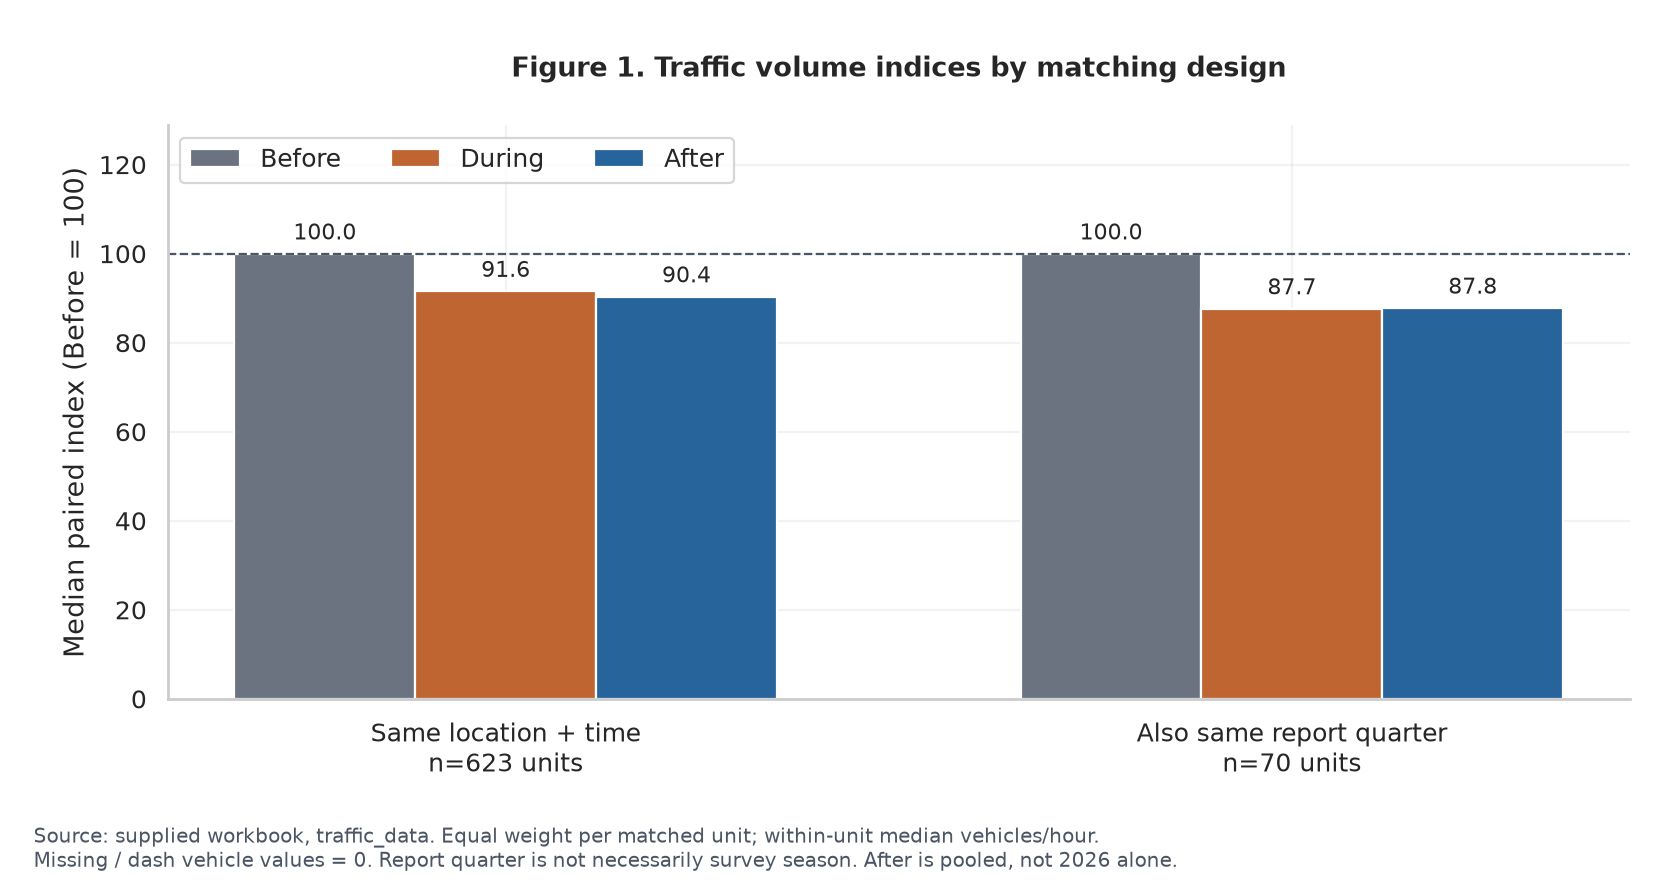

In [8]:
display(Image(filename=str(OUT / 'figures' / '01_matching_sensitivity.png'), width=950))

## Figure 2 — 02_time_window_vph.png

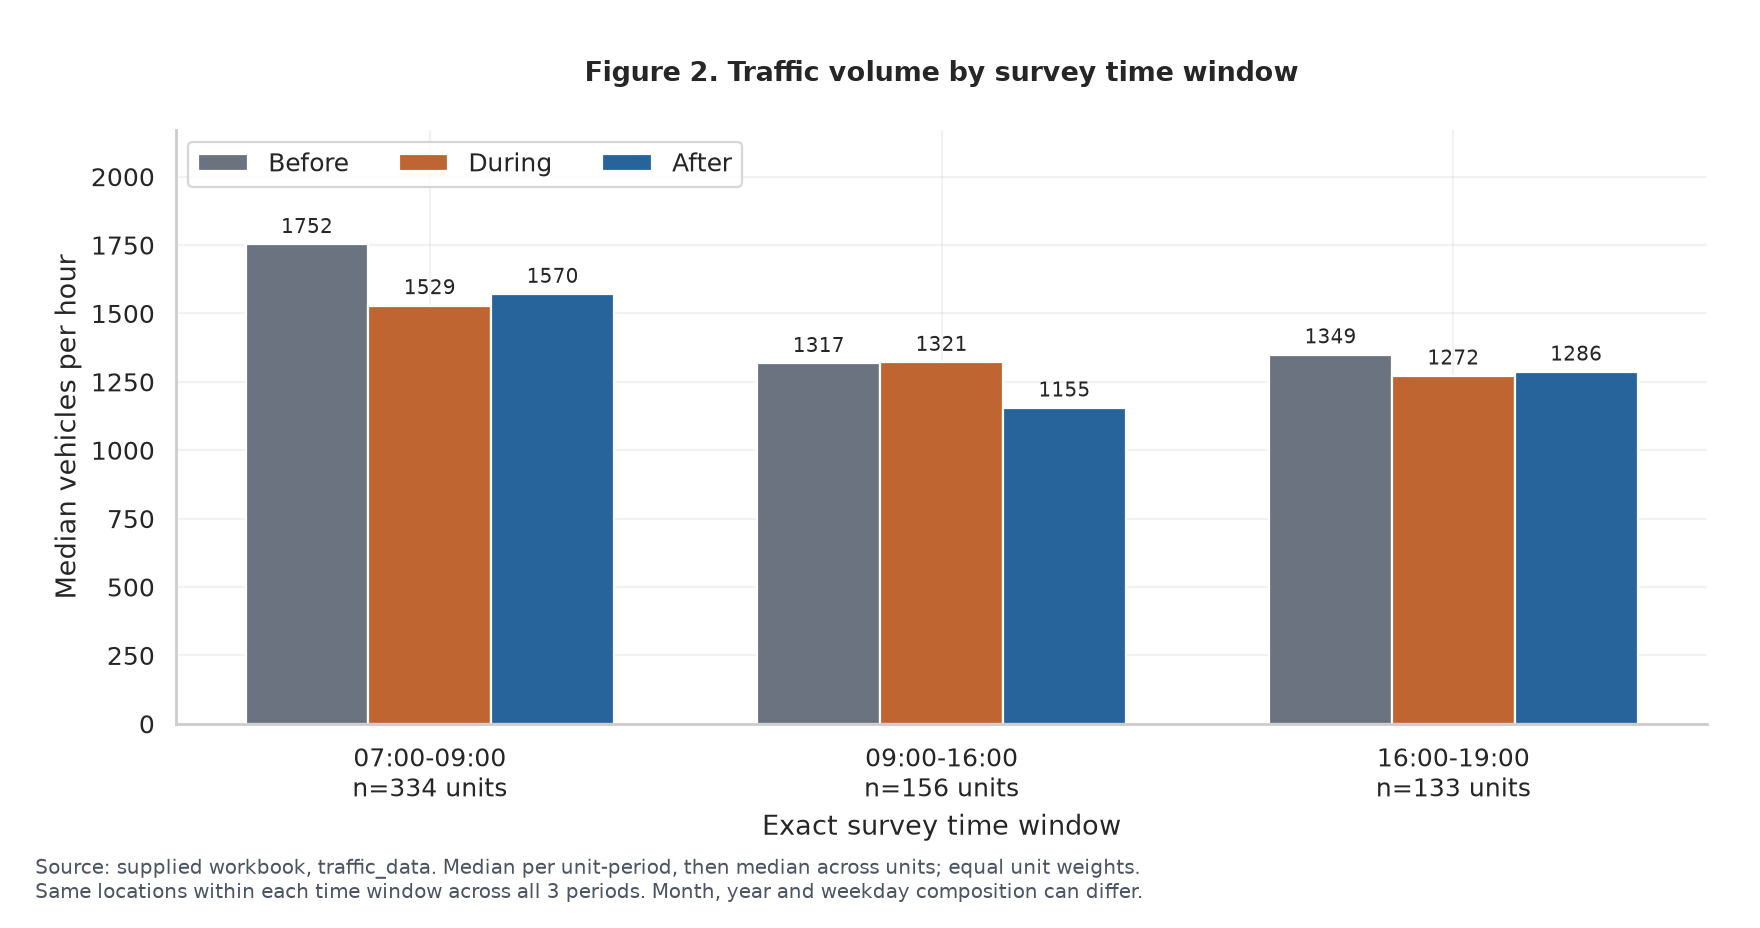

In [9]:
display(Image(filename=str(OUT / 'figures' / '02_time_window_vph.png'), width=950))

## Figure 3 — 03_paired_scatter.png

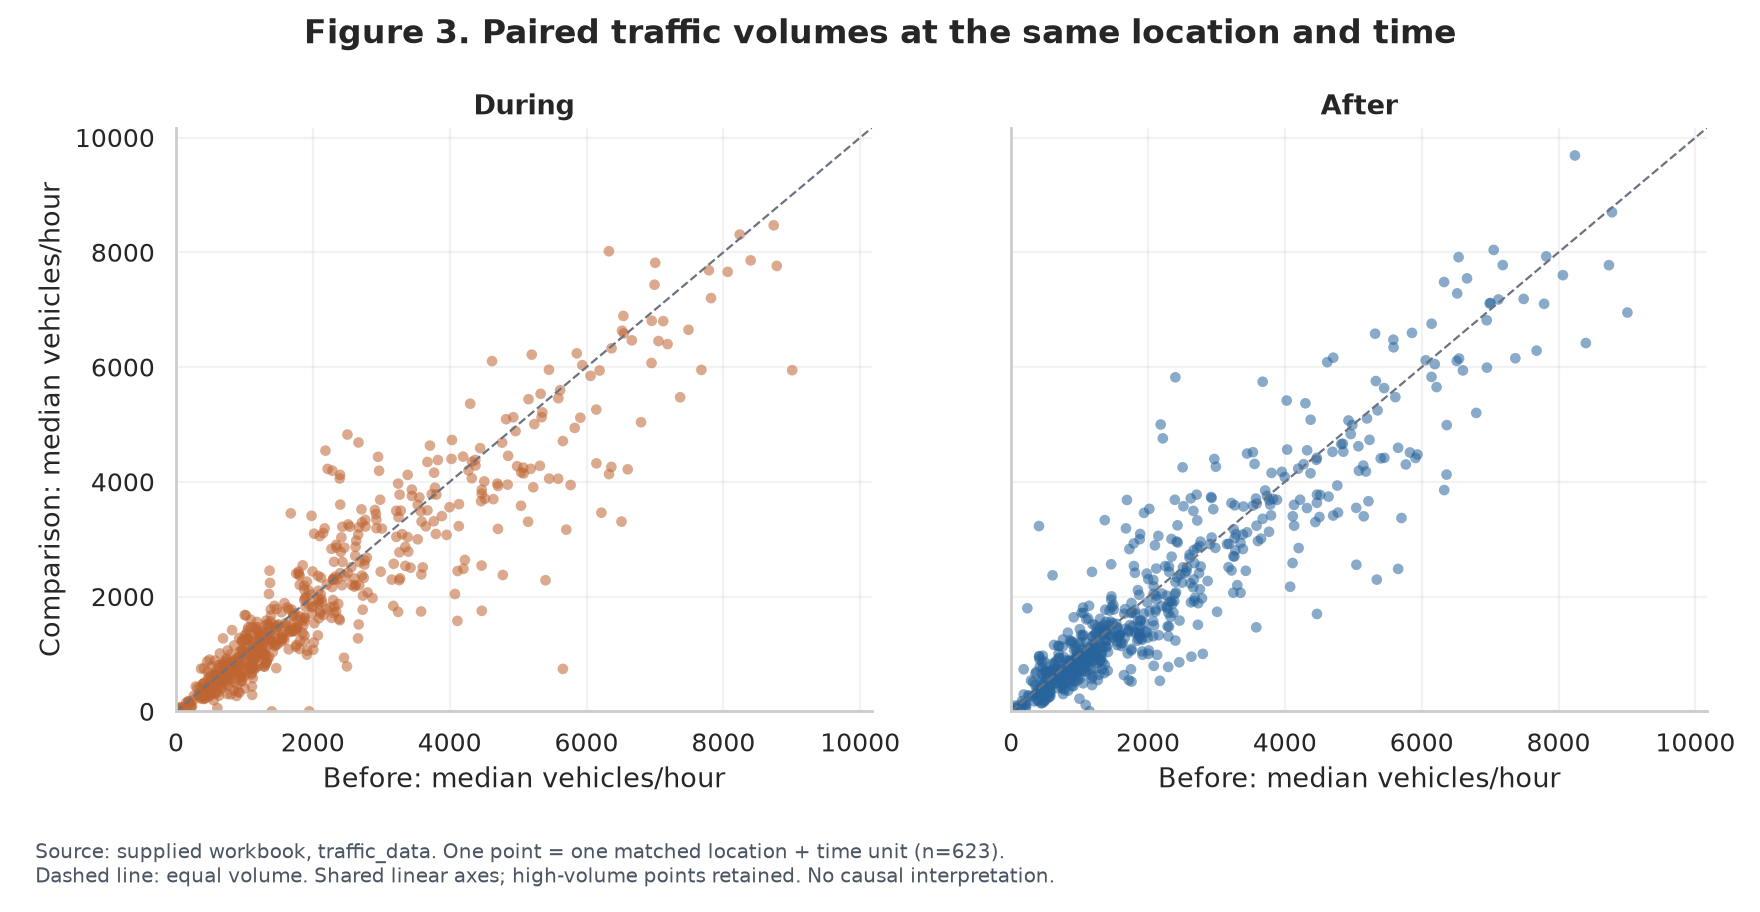

In [10]:
display(Image(filename=str(OUT / 'figures' / '03_paired_scatter.png'), width=950))

## Figure 4 — 04_vehicle_mix.png

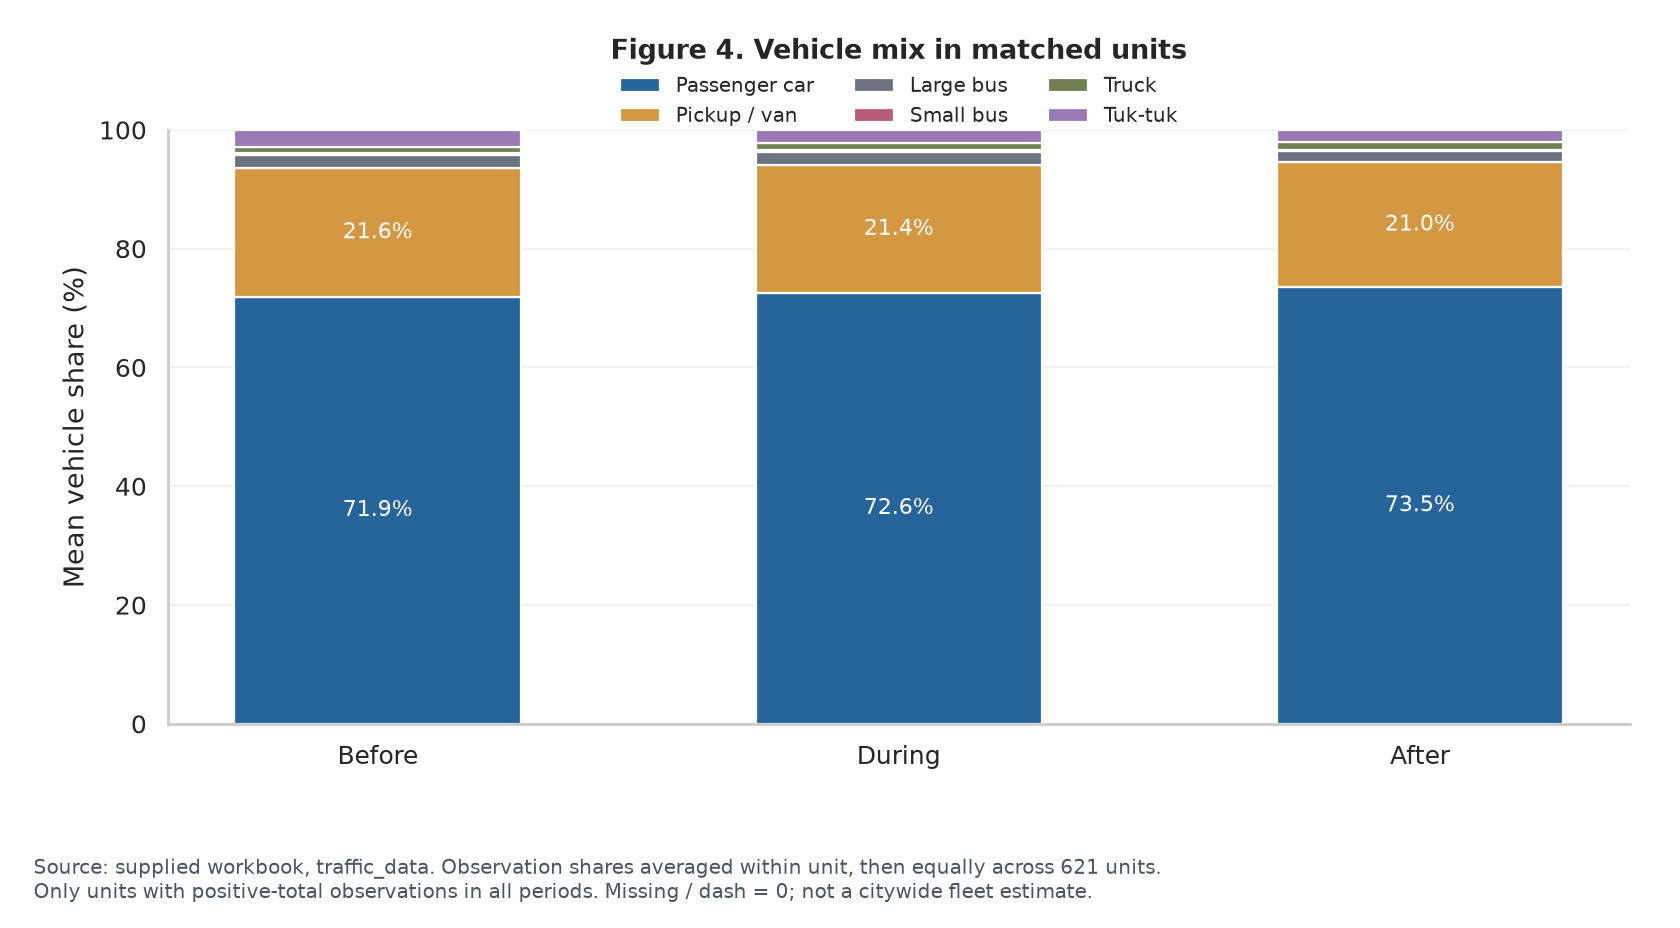

In [11]:
display(Image(filename=str(OUT / 'figures' / '04_vehicle_mix.png'), width=950))

## Figure 5 — Coverage ของข้อมูลตามปีและเดือนรายงาน

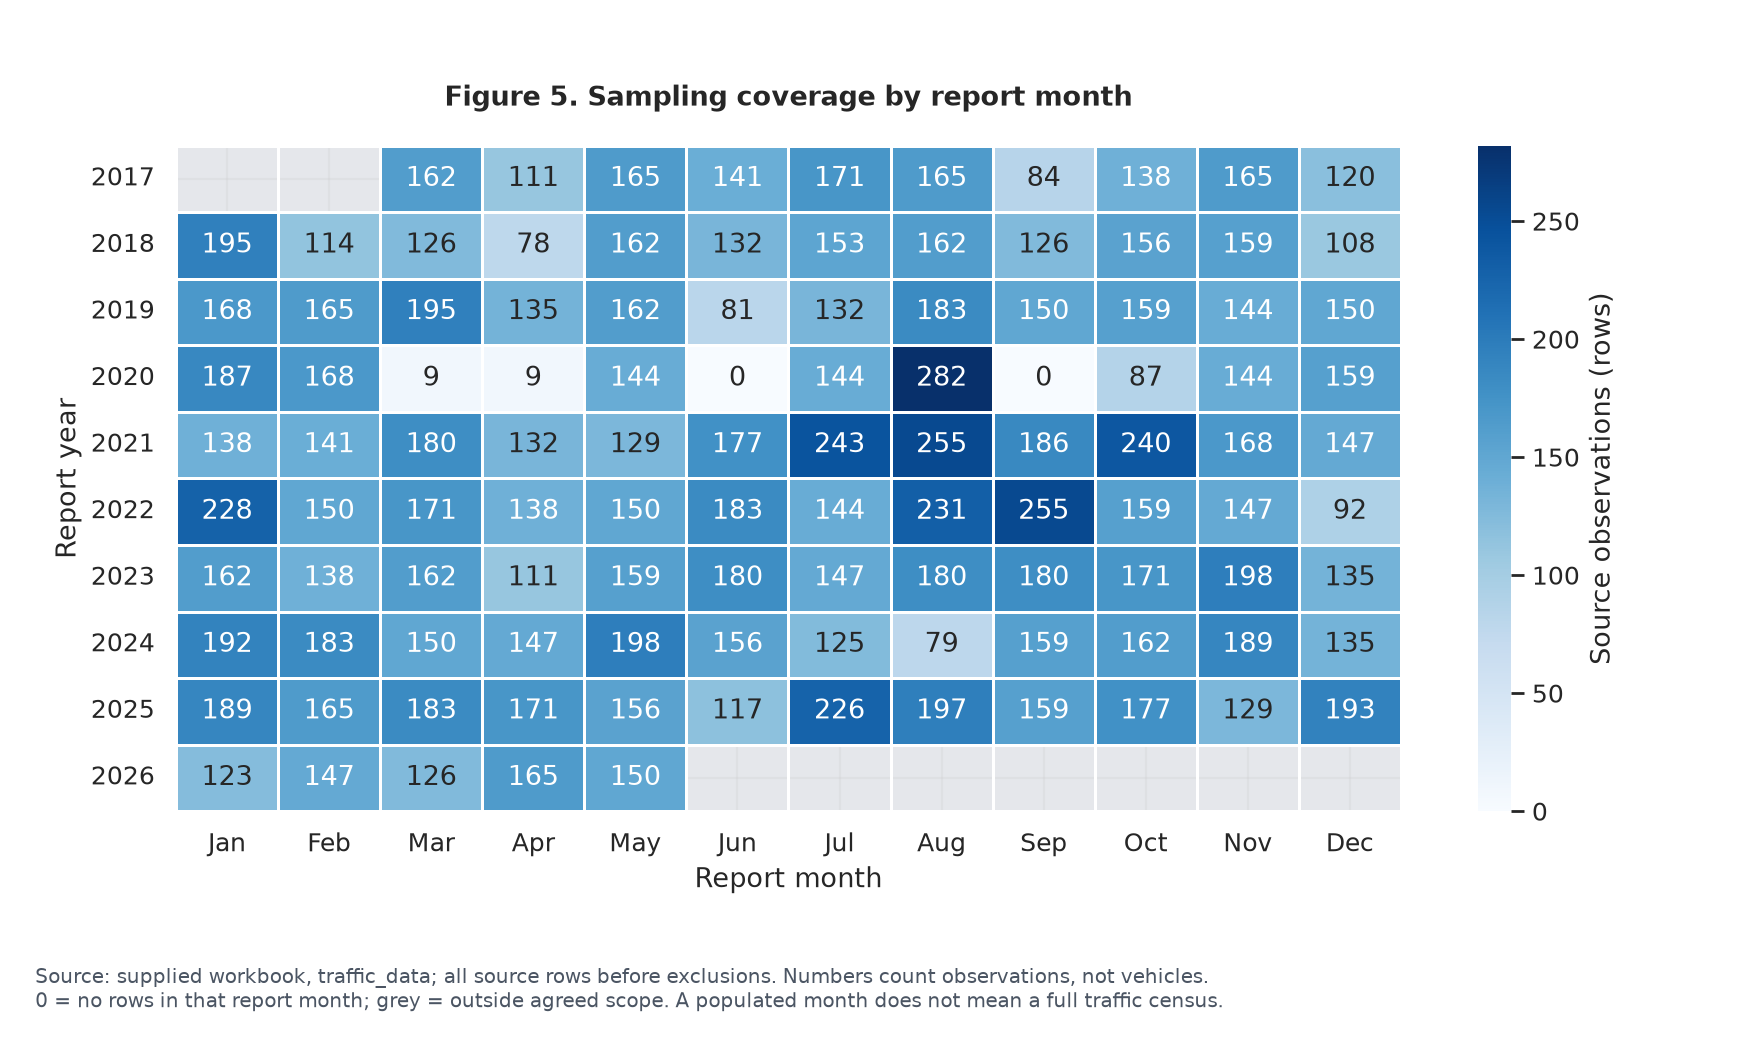

In [12]:
display(Image(filename=str(OUT / 'figures' / '05_report_coverage.png'), width=950))

## Figure 6 — การกระจายดัชนีปริมาณรถใน matched units

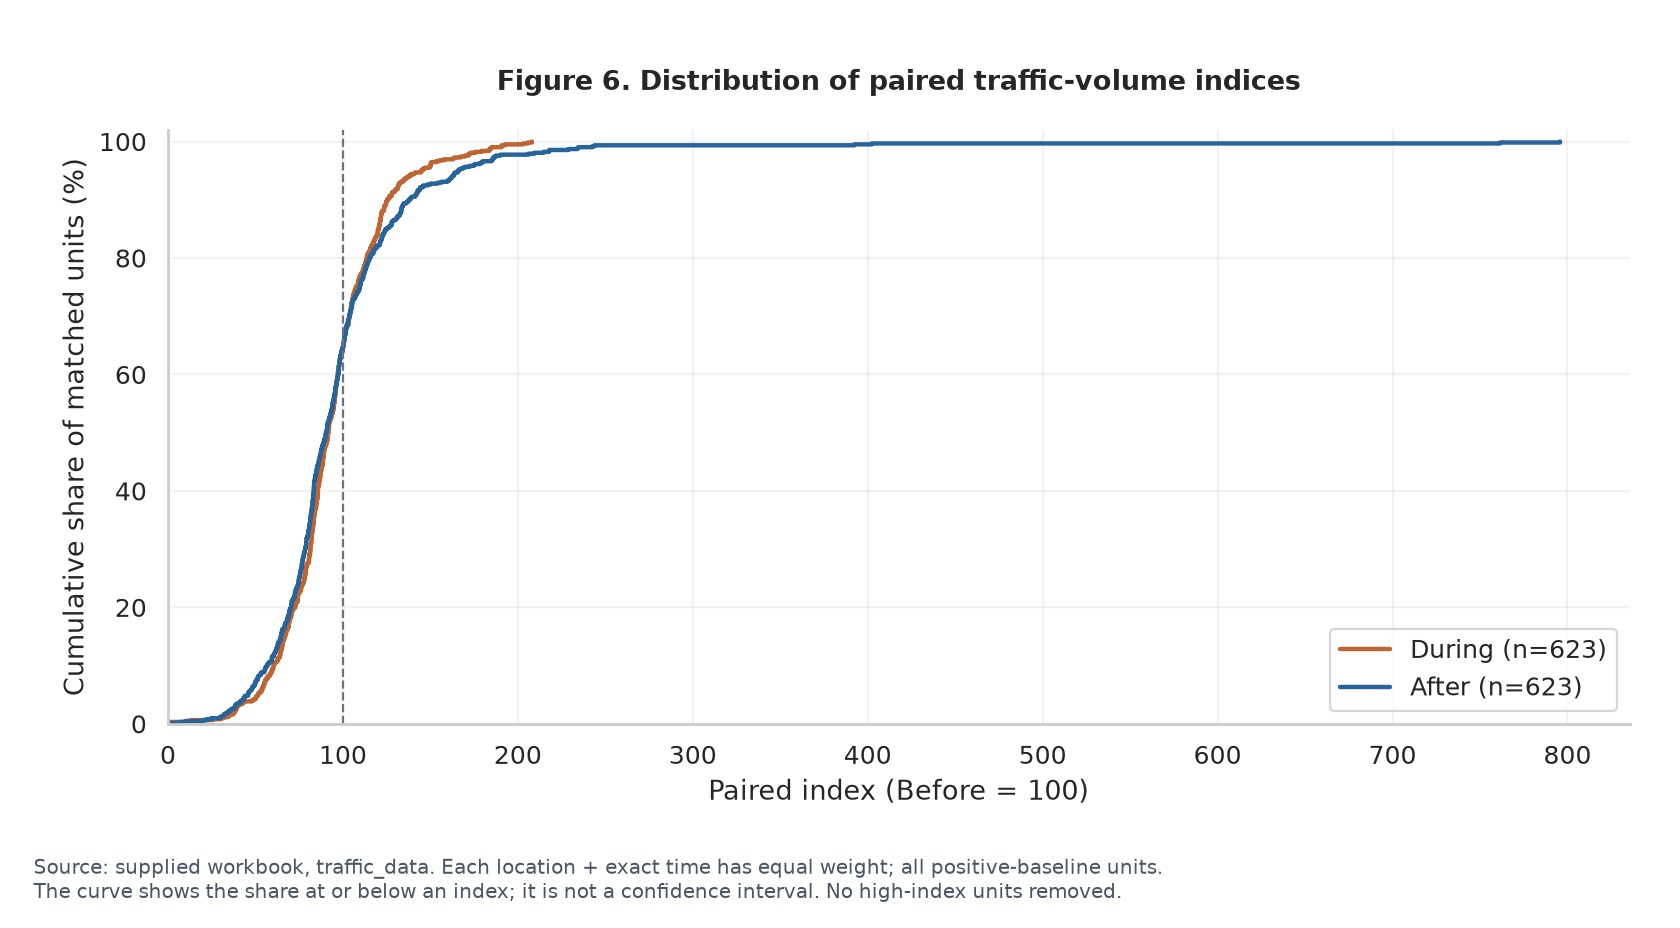

In [13]:
display(Image(filename=str(OUT / 'figures' / '06_recovery_distribution.png'), width=950))

## Figure 7 — เช้าและเย็นบนสถานที่และวันสำรวจชุดเดียวกัน

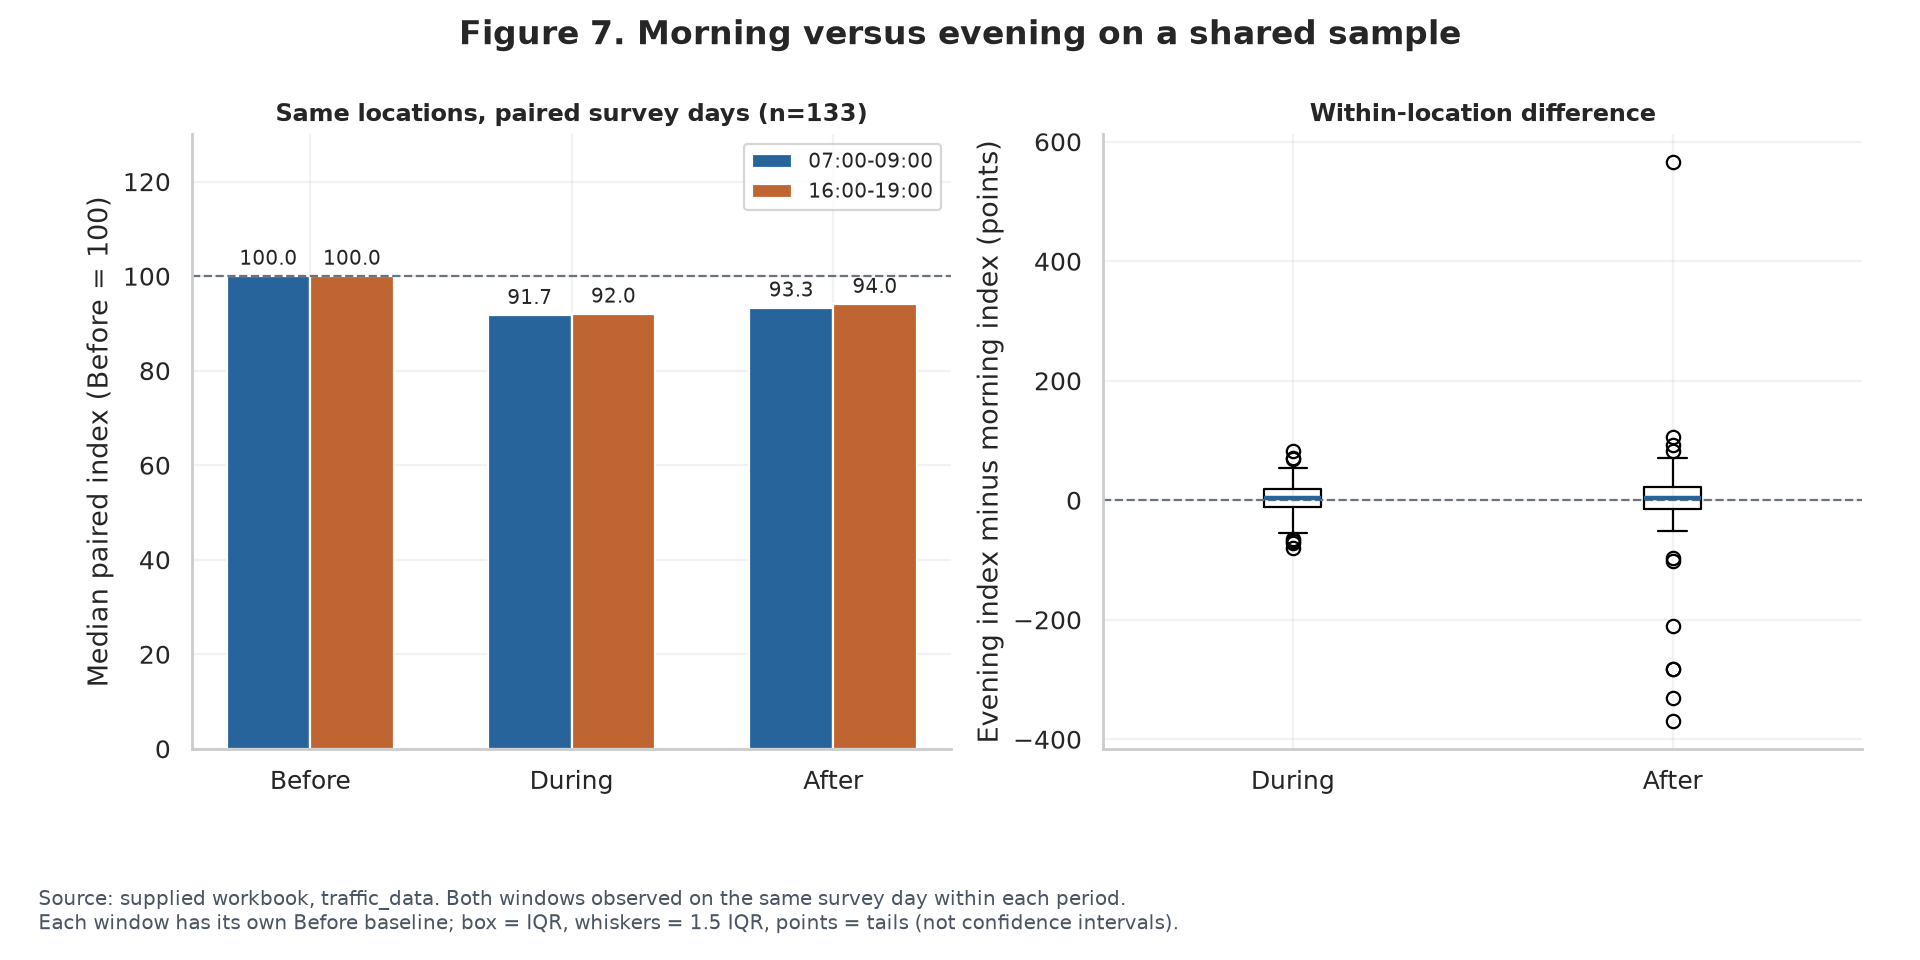

In [14]:
display(Image(filename=str(OUT / 'figures' / '07_paired_morning_evening.png'), width=950))

## Figure 8 — ตัวอย่างสถานที่ช่วงเช้าที่ควรติดตาม

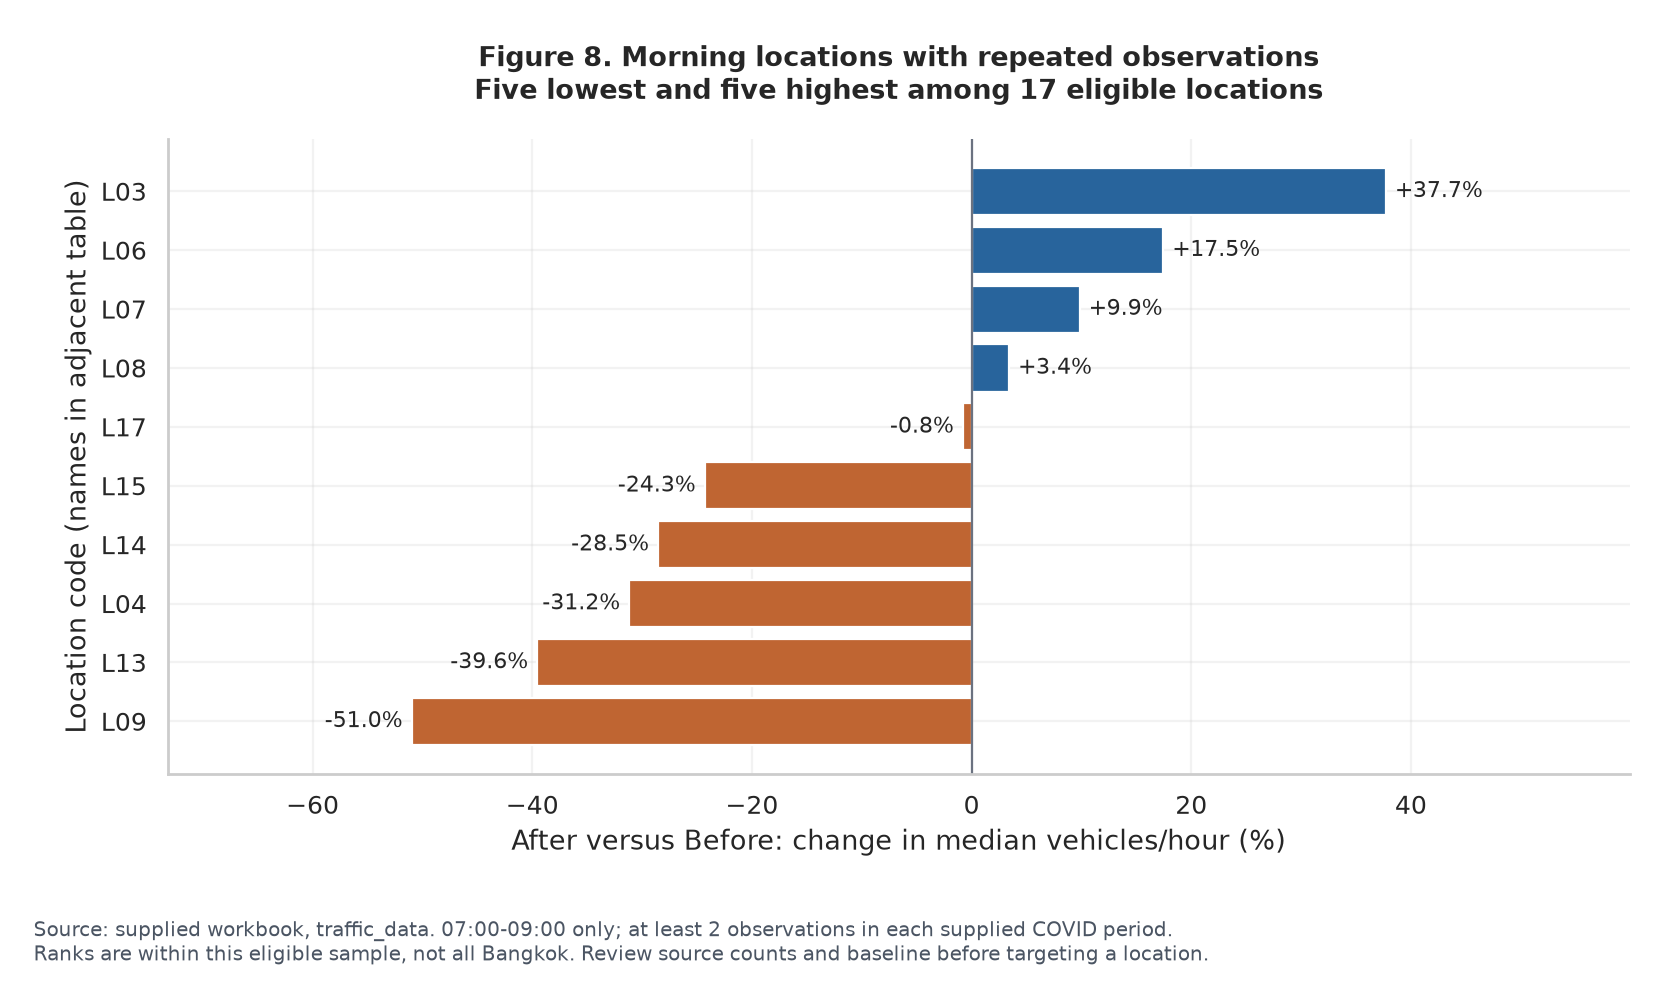

In [15]:
display(Image(filename=str(OUT / 'figures' / '08_morning_location_ranking.png'), width=950))

In [16]:
display(pd.read_csv(OUT/'morning_location_ranking_displayed.csv').round(2))

,intersection_key,road_key,Before,During,After,after_change_pct,location_code,n_Before,n_During,n_After
0,มิตรไมตรี - มิตรไมตรี 2,มิตรไมตรี,1360.75,946.50,667.00,-50.98,L09,2,3,3
1,หลักสี่,กำแพงเพชร 6,1756.00,1391.00,1061.50,-39.55,L13,2,2,3
2,บางยี่เรือ,เทอดไท,733.00,887.00,504.50,-31.17,L04,2,2,3
3,หลักสี่,แจ้งวัฒนะ,3428.75,2503.25,2450.00,-28.55,L14,2,2,3
4,ห้วยขวาง,ประชาสงเคราะห์,641.00,1010.50,485.25,-24.30,L15,2,2,4
5,เตาปูน,ประชาราษฎร์สาย 2,1537.75,1212.00,1525.50,-0.80,L17,2,2,2
6,พระราม 9,อโศกดินแดง,2929.50,3192.25,3029.75,3.42,L08,2,2,2
7,พระราม 9,รัชดาภิเษก,3268.50,3777.25,3590.50,9.85,L07,2,2,2
8,พระราม 9,พระราม 9,2119.25,2331.50,2489.25,17.46,L06,2,2,2
9,บางขุนนนท์,จรัญสนิทวงศ์,2100.50,3054.00,2893.00,37.73,L03,2,2,3


## Figure 9 — การเปลี่ยนสัดส่วนรถเป็น percentage points

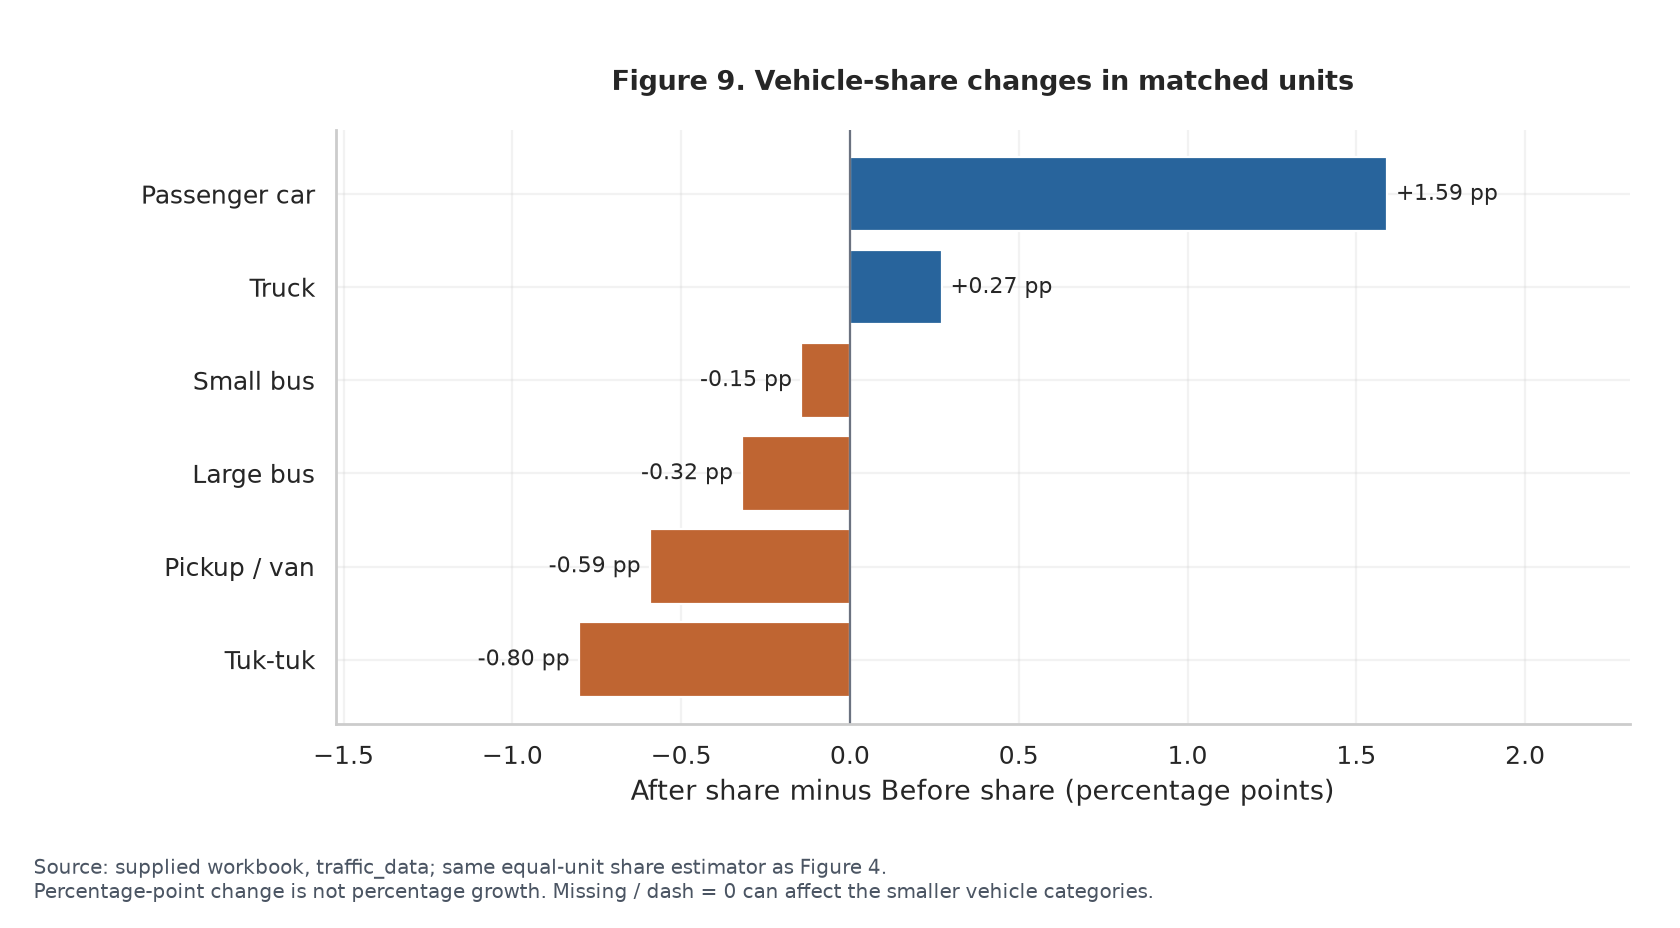

In [17]:
display(Image(filename=str(OUT / 'figures' / '09_vehicle_share_change.png'), width=950))

## Figure 10 — ปี 2026 เทียบ Before เฉพาะเดือนตรงกัน

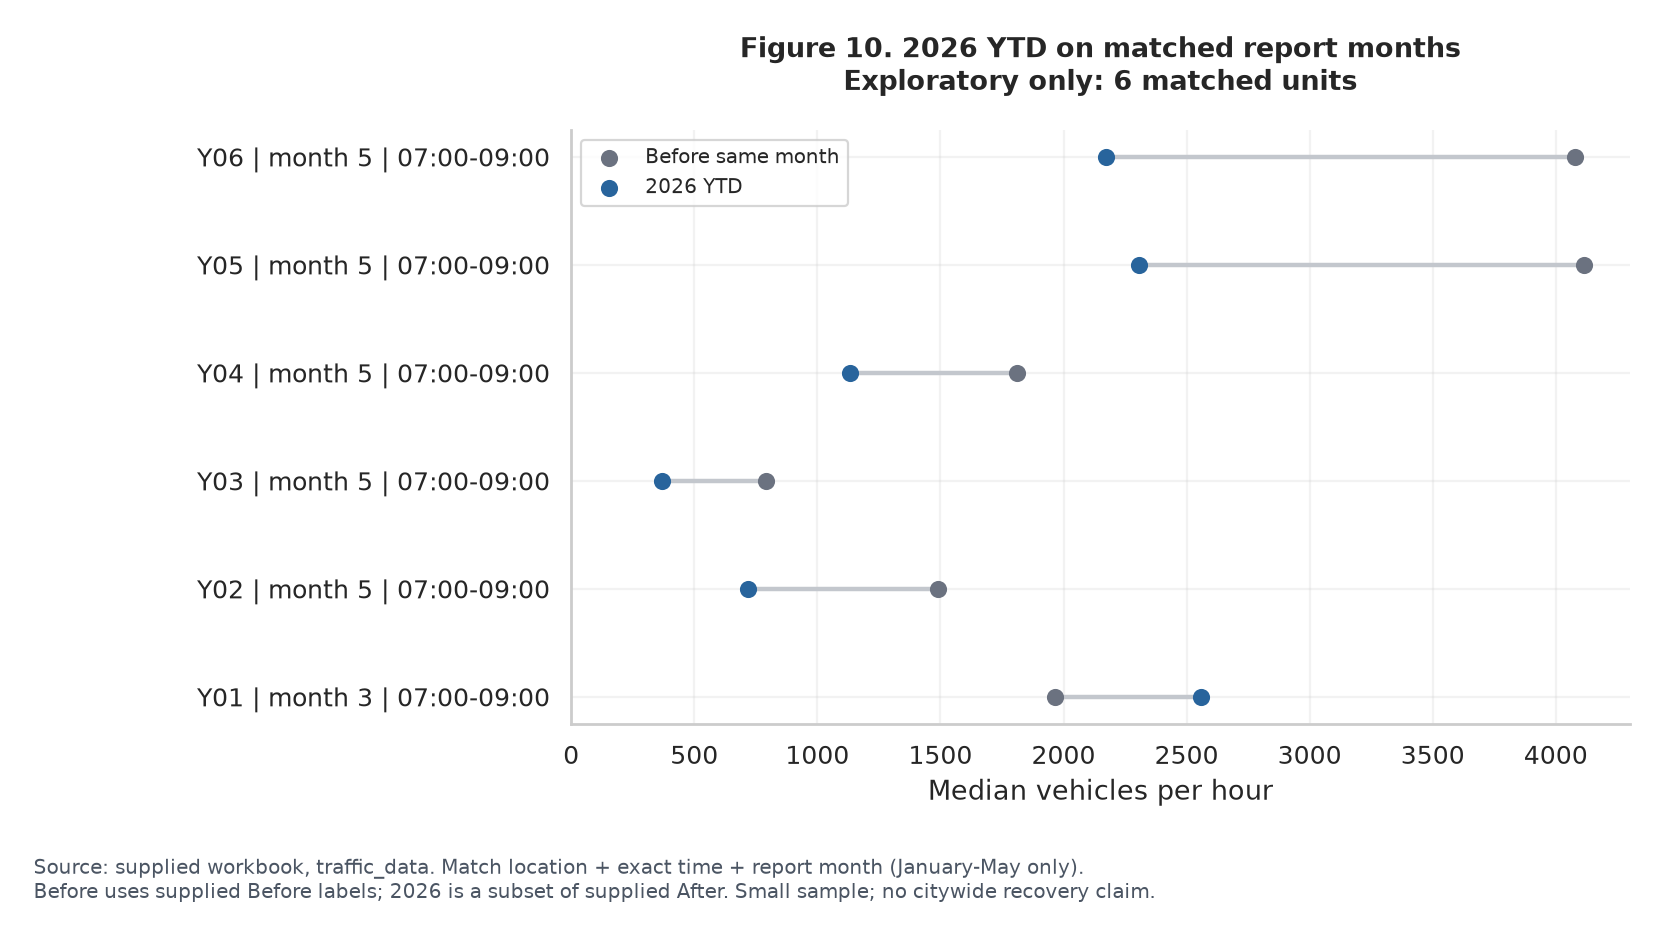

In [18]:
display(Image(filename=str(OUT / 'figures' / '10_2026_matched_months.png'), width=950))

In [19]:
display(pd.read_csv(OUT/'year2026_matched_month_units.csv').round(2))

,intersection_key,road_key,time_key,report_month,Before,2026 YTD,paired_index,unit_code
0,บางขุนนนท์,จรัญสนิทวงศ์,07:00-09:00,3,1967.0,2560.5,130.17,Y01
1,บางยี่เรือ,อินทรพิทักษ์,07:00-09:00,5,1489.5,717.5,48.17,Y02
2,บางยี่เรือ,เทอดไท,07:00-09:00,5,792.5,368.5,46.50,Y03
3,บางยี่เรือ,เพชรเกษม,07:00-09:00,5,1813.0,1131.0,62.38,Y04
4,อุรุพงษ์,พระรามที่ 6,07:00-09:00,5,4112.5,2305.5,56.06,Y05
5,อุรุพงษ์,เพชรบุรี,07:00-09:00,5,4077.5,2172.0,53.27,Y06


## สมมติฐานและการเลือกกราฟสำหรับ Pitch
H1: ระดับ During ต่ำกว่า Before ใน matched sample; H2: ทิศทาง After เทียบ During เปลี่ยนตามการ matching; H3: มีการจับคู่เช้า–เย็นบนสถานที่และวันเดียวกันแล้ว ดูรูป 7; H4: การเปลี่ยนแปลงกระจายไม่เท่ากัน ดูรูป 6/8; H5: สัดส่วนรถเปลี่ยน ดูรูป 4/9 แต่ขึ้นกับสมมติฐาน 0

สำหรับ Pitch แนะนำภาพรวม → coverage → ผลหลัก → เช้า/เย็น → ตัวอย่างสถานที่ → ข้อเสนอแนะ ไม่จำเป็นต้องแสดงทุกกราฟ งานรุ่นพี่ที่ใช้ศึกษาโครงเรื่อง: https://github.com/techasit239/Dads-5001-Accident-Is-You-Dont-Love ไม่ได้นำโค้ดหรือข้อมูลอุบัติเหตุมาใช้

## ตรวจผลและข้อจำกัด
After รวมหลายปี ไม่ใช่ผลเฉพาะปี 2026; กลุ่มไตรมาสรายงานไม่รับรองฤดูกาลสำรวจตรงกัน; ค่า 0 ที่แทนเป็นสมมติฐานผู้ใช้ ไม่สรุปเหตุและผลจาก COVID หรือใช้จำนวนรถแทนความเร็ว/รถติด

In [20]:
analysis = pd.read_csv(ROOT / 'data/processed/traffic_matched_analysis.csv', low_memory=False)
assert set(analysis.source_sha256) == {summary['source_sha256']}
assert np.allclose(analysis.vehicle_total, analysis[[c+'_clean' for c in VEHICLES]].sum(axis=1))
assert np.allclose(analysis.vehicles_per_hour * analysis.period_hours, analysis.vehicle_total)
print('Checks passed. Original Excel unchanged.')

Checks passed. Original Excel unchanged.


## ดาวน์โหลดผลลัพธ์
ZIP รวมรายงาน ตาราง กราฟ และข้อมูลที่ประมวลผล ไม่รวม Excel ต้นฉบับ บน Colab คลิกไฟล์ในแถบ Files เพื่อดาวน์โหลด

## ตรวจเพิ่มเติม: วันสำรวจ ความไม่แน่นอน ค่าว่าง และปีภายใน After
ผลเป็นความสัมพันธ์ในข้อมูล ไม่ใช่ผลเชิงสาเหตุของโควิด; รายงานบริบทพื้นที่และการทวน PDF อยู่ในโปรเจค Read.md

In [21]:
"""Supplementary diagnostics. Run from the project root; preserves supplied periods and source."""
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
OUT=ROOT/'outputs/diagnostics'
OUT.mkdir(parents=True,exist_ok=True)
KEY=['intersection_key','road_key','time_key'];V=['passenger_car','pickup_van','large_bus','small_bus','truck','tuk_tuk'];P=['ก่อนโควิด','โควิด','หลังโควิด'];L=dict(zip(P,['Before','During','After']))
def save(x,n):x.to_csv(OUT/n,index=False,encoding='utf-8-sig')
def paired(x,keys=KEY):
 w=x.groupby(keys+['covid_period']).vehicles_per_hour.median().unstack('covid_period').reindex(columns=P).dropna()
 w=w[w[P[0]]>0];idx=w.div(w[P[0]],axis=0)*100;idx.columns=['Before','During','After'];return w,idx

def mix(x):
 x=x[x.vehicle_total.gt(0)].copy()
 for v in V:x[v]=x[v+'_clean']/x.vehicle_total*100
 u=x.groupby(KEY+['covid_period'])[V].mean().reset_index()
 k=u.groupby(KEY).covid_period.nunique();k=k[k.eq(3)].reset_index()[KEY]
 u=u.merge(k,on=KEY);return u.groupby('covid_period')[V].mean().reindex(P),k

def md(x):
    x=x.round(3).fillna('NA'); rows=[list(x.columns)]+x.astype(str).values.tolist()
    out=['| '+' | '.join(map(str,rows[0]))+' |','| '+' | '.join(['---']*len(x.columns))+' |']
    out.extend('| '+' | '.join(str(v).replace('|','/') for v in row)+' |' for row in rows[1:])
    return '\n'.join(out)
def main():
 d=pd.read_csv(ROOT/'data/processed/traffic_analysis_candidates.csv',low_memory=False)
 d['survey_date_parsed']=pd.to_datetime(d.survey_date_parsed)
 d['survey_weekday']=d.survey_date_parsed.dt.day_name();d['actual_month']=d.survey_date_parsed.dt.month
 w,idx=paired(d);keys=w.reset_index()[KEY];m=d.merge(keys,on=KEY,validate='many_to_one')
 # Intersection-cluster bootstrap retains every location-time unit and original equal-unit median estimand.
 groups=[g[['During','After']].to_numpy() for _,g in idx.reset_index().groupby('intersection_key')]
 rng=np.random.default_rng(5001);boot=np.empty((3000,2))
 for i in range(len(boot)):boot[i]=np.median(np.concatenate([groups[j] for j in rng.integers(0,len(groups),len(groups))]),axis=0)
 ci=pd.DataFrame({'period':['During','After'],'median_index':idx[['During','After']].median().values,'bootstrap_p025':np.quantile(boot,.025,axis=0),'bootstrap_p975':np.quantile(boot,.975,axis=0),'units':len(idx),'intersection_clusters':len(groups),'replicates':len(boot),'seed':5001});save(ci,'cluster_bootstrap.csv')
 # Complete-number sensitivity with common-unit controls.
 complete=d.loc[~d.has_assumed_zero].copy();wc,ic=paired(complete)
 rows=[]
 for name,z in [('main_zero_assumption',d),('main_restricted_to_complete_units',d.merge(wc.reset_index()[KEY],on=KEY)),('complete_numeric_only',complete)]:
  a,b=paired(z);rows.append({'design':name,'rows':len(z.merge(a.reset_index()[KEY],on=KEY)),'units':len(a),'During':b.During.median(),'After':b.After.median()})
 sensitivity=pd.DataFrame(rows);save(sensitivity,'zero_sensitivity.csv')
 mx,k=mix(m);c0=complete.merge(wc.reset_index()[KEY],on=KEY);mc,kc=mix(c0)
 # same mix units for a clearer sensitivity comparison
 original_common=m.merge(kc,on=KEY);mo,ko=mix(original_common)
 mixes=[]
 for name,a,ks in [('main',mx,k),('original_common_units',mo,ko),('complete_numeric_common_units',mc,kc)]:
  for v in V:mixes.append({'design':name,'vehicle':v,'Before_share':a.loc[P[0],v],'After_share':a.loc[P[2],v],'change_pp':a.loc[P[2],v]-a.loc[P[0],v],'units':len(ks)})
 save(pd.DataFrame(mixes),'zero_vehicle_mix_sensitivity.csv')
 # Survey weekday/month matching (not holiday adjustment).
 strict=[]
 for name,kk in [('same_weekday',KEY+['survey_weekday']),('same_survey_month_weekday',KEY+['actual_month','survey_weekday'])]:
  a,b=paired(d,kk);strict.append({'design':name,'units':len(a),'During':float(b.During.median()) if len(b) else None,'After':float(b.After.median()) if len(b) else None})
 save(pd.DataFrame(strict),'weekday_sensitivity.csv')
 # Separate report years; each matches the same actual survey month as its own Before comparison.
 years=[];year_units=[]
 for year in range(2022,2027):
  pre=d[d.covid_period.eq(P[0])].groupby(KEY+['actual_month']).vehicles_per_hour.median().rename('Before')
  post=d[d.covid_period.eq(P[2])&d.report_year.eq(year)].groupby(KEY+['actual_month']).vehicles_per_hour.median().rename('After_year')
  y=pd.concat([pre,post],axis=1).dropna();y=y[y.Before.gt(0)];y['paired_index']=y.After_year/y.Before*100
  q=y.reset_index();q['report_year']=year;year_units.append(q)
  years.append({'report_year':year,'units':len(y),'locations':len(q[['intersection_key','road_key']].drop_duplicates()),'median_index':y.paired_index.median(),'months':','.join(map(str,sorted(q.actual_month.unique()))),'interpretation':'different matched sample each year; no trend line'})
 yu=pd.concat(year_units,ignore_index=True);save(yu,'after_year_matched_units.csv');save(pd.DataFrame(years),'after_year_summary.csv')
 # All ten displayed locations, exact observed dates and low-assumption calendar windows.
 r=pd.read_csv(ROOT/'outputs/eda/morning_location_ranking_displayed.csv')
 case=d[d.time_key.eq('07:00-09:00')].merge(r[['intersection_key','road_key','location_code']],on=['intersection_key','road_key'])
 def flag(t):
  if (t.month==12 and t.day>=25) or (t.month==1 and t.day<=3):return 'near_new_year_window_not_official_holiday_flag'
  if t.month==4 and 10<=t.day<=17:return 'near_songkran_window_not_official_holiday_flag'
  if t.strftime('%m-%d')=='05-02':return 'day_after_May1_not_itself_confirmed_holiday'
  return 'no_selected_calendar_window; other_events_not_ruled_out'
 case['calendar_screen']=case.survey_date_parsed.map(flag)
 case['period_before_emergency']=case.covid_period.eq(P[1])&case.survey_date_parsed.lt('2020-03-26')
 cols=['location_code','intersection_key','road_key','covid_period','survey_date_parsed','survey_weekday','report_date','vehicles_per_hour','has_assumed_zero','calendar_screen','period_before_emergency','source_excel_row']
 case=case.sort_values(['location_code','survey_date_parsed']);save(case[cols],'case_survey_dates.csv')
 # Descriptive leave-one-visit-out ranges (not confidence intervals).
 loo=[];components=[]
 for code,g in case.groupby('location_code'):
  b=g[g.covid_period.eq(P[0])];a=g[g.covid_period.eq(P[2])];base=b.vehicles_per_hour.median();post=a.vehicles_per_hour.median();vals=[]
  for j in b.index:vals.append((post/b.drop(j).vehicles_per_hour.median()-1)*100)
  for j in a.index:vals.append((a.drop(j).vehicles_per_hour.median()/base-1)*100)
  counts=g.covid_period.value_counts();loo.append({'code':code,'intersection':g.intersection_key.iloc[0],'road':g.road_key.iloc[0],'Before_n':counts.get(P[0],0),'During_n':counts.get(P[1],0),'After_n':counts.get(P[2],0),'after_change_pct':(post/base-1)*100,'leave_one_visit_min_pct':min(vals),'leave_one_visit_max_pct':max(vals),'all_weekdays':bool((g.survey_date_parsed.dt.dayofweek<5).all())})
  for v in V:components.append({'code':code,'vehicle':v,'before_mean_vph':(b[v+'_clean']/b.period_hours).mean(),'after_mean_vph':(a[v+'_clean']/a.period_hours).mean(),'mean_vph_difference':(a[v+'_clean']/a.period_hours).mean()-(b[v+'_clean']/b.period_hours).mean()})
  cc=sum(x['mean_vph_difference'] for x in components if x['code']==code)
  assert np.isclose(cc,a.vehicles_per_hour.mean()-b.vehicles_per_hour.mean())
 save(pd.DataFrame(loo),'case_leave_one_visit_out.csv');save(pd.DataFrame(components),'case_vehicle_mean_decomposition.csv')
 # Sample receipt for each of the original ten figures.
 receipt=[{'figure':1,'sample':'623 same-time units; 70 same-report-quarter units'},{'figure':2,'sample':str(w.groupby(level='time_key').size().to_dict())},{'figure':3,'sample':f'{len(w)} units; {len(m)} rows'},{'figure':4,'sample':f'{len(k)} positive-total complete mix units'},{'figure':5,'sample':'17005 raw source rows; counts per report month'},{'figure':6,'sample':f'{len(idx)} positive-baseline units'},{'figure':7,'sample':'133 paired AM/PM locations'},{'figure':8,'sample':'10 displayed / 17 eligible locations; individual period n in case table'},{'figure':9,'sample':f'{len(k)} mix units'},{'figure':10,'sample':'6 report-month matched units; 12 observations'}];save(pd.DataFrame(receipt),'figure_sample_sizes.csv')
 result={'source_sha256':d.source_sha256.iloc[0],'matched_rows':len(m),'clusters':len(groups),'case_rows':len(case),'case_dates':case.survey_date_parsed.nunique(),'case_weekend_rows':int((case.survey_date_parsed.dt.dayofweek>=5).sum()),'during_before_2020_03_26_rows_in_main':int((m.covid_period.eq(P[1])&m.survey_date_parsed.lt('2020-03-26')).sum()),'bootstrap':ci.to_dict('records'),'zero_sensitivity':rows,'weekday_sensitivity':strict,'annual':years}
 (OUT/'summary.json').write_text(json.dumps(result,ensure_ascii=False,indent=2),encoding='utf-8')
 report='# ผลตรวจเพิ่มเติม: ความไม่แน่นอน ค่าว่าง วันสำรวจ และปีภายใน After\n\n'
 report+='สูตรหลักและ covid_period คงเดิม ผลนี้เป็นภาคผนวกของ EDA ไม่ใช่ causal effect\n\n## Bootstrap ตามกลุ่มทางแยก\n\n'+md(ci)+'\n\nสุ่มทางแยกพร้อมหน่วยถนน–เวลาภายใน 3,000 รอบ seed=5001; percentile 95% เป็นความไม่แน่นอนภายในตัวอย่าง ไม่รวม selection bias ความผิดการวัด หรือความต่างวันสำรวจ\n\n## สมมติฐานค่าว่าง=0\n\n'+md(sensitivity)+'\n\nแถว original restricted ใช้หน่วยชุดเดียวกับ complete numeric เพื่อแยกการเปลี่ยนสมาชิกบางส่วน แต่การลบวันสำรวจยังเปลี่ยนองค์ประกอบเวลา ไม่แทนวิธีหลักโดยอัตโนมัติ ดู zero_vehicle_mix_sensitivity.csv สำหรับผลสัดส่วนรถ\n\n## วันในสัปดาห์\n\n'+md(pd.DataFrame(strict))+'\n\nใช้วันสำรวจจริงและไม่ได้ปรับวันหยุด การเพิ่มเงื่อนไขทำให้ชุดตัวอย่างเปลี่ยน\n\n## แยกปี After\n\n'+md(pd.DataFrame(years))+'\n\nแต่ละปีจับคู่กับ Before บนสถานที่+เวลา+เดือนสำรวจเดียวกัน แต่คนละชุดระหว่างปี จึงไม่ลากเส้นแนวโน้ม\n\n## สถานที่แสดงในกราฟ 8\n\n'+md(pd.DataFrame(loo))+'\n\nช่วง leave-one-visit-out แสดงความไวเมื่อเอาวันสำรวจ Before หรือ After ออกทีละหนึ่งรายการ ไม่ใช่ confidence interval และไม่ใช่ข้อเสนอให้ลบข้อมูล\n\nทุกวันสำรวจของสิบสถานที่เป็นจันทร์–ศุกร์ แต่ไม่ได้หมายความว่าทุกวันเป็นวันทำงานปกติ ต้องตรวจวันหยุดและกิจกรรมแยก\n\n'
 for code,g in case.groupby('location_code'):
  report+='### '+code+' '+g.intersection_key.iloc[0]+' / '+g.road_key.iloc[0]+'\n\n'+md(g[['covid_period','survey_date_parsed','survey_weekday','vehicles_per_hour','calendar_screen','source_excel_row']].assign(survey_date_parsed=lambda z:z.survey_date_parsed.dt.strftime('%Y-%m-%d')))+'\n\n'
 report+='## จำนวนตัวอย่างกราฟเดิม\n\n'+md(pd.DataFrame(receipt))+'\n'
 (OUT/'Statistical_Diagnostics.md').write_text(report,encoding='utf-8')
 print(json.dumps(result,ensure_ascii=False,indent=2))
main()

{
  "source_sha256": "6e1b556f353c66fec5c8a664f3e1e5b5e52e5a756f75c2ae28562c5c0fa6118b",
  "matched_rows": 2612,
  "clusters": 175,
  "case_rows": 68,
  "case_dates": 49,
  "case_weekend_rows": 0,
  "during_before_2020_03_26_rows_in_main": 82,
  "bootstrap": [
    {
      "period": "During",
      "median_index": 91.58761857214178,
      "bootstrap_p025": 88.43243243243244,
      "bootstrap_p975": 94.93127350148214,
      "units": 623,
      "intersection_clusters": 175,
      "replicates": 3000,
      "seed": 5001
    },
    {
      "period": "After",
      "median_index": 90.3570746610655,
      "bootstrap_p025": 86.61825726141079,
      "bootstrap_p975": 93.77401272008171,
      "units": 623,
      "intersection_clusters": 175,
      "replicates": 3000,
      "seed": 5001
    }
  ],
  "zero_sensitivity": [
    {
      "design": "main_zero_assumption",
      "rows": 2612,
      "units": 623,
      "During": 91.58761857214178,
      "After": 90.3570746610655
    },
    {
      "design

In [22]:
display(Markdown((ROOT/'outputs/diagnostics/Statistical_Diagnostics.md').read_text(encoding='utf-8')))

# ผลตรวจเพิ่มเติม: ความไม่แน่นอน ค่าว่าง วันสำรวจ และปีภายใน After

สูตรหลักและ covid_period คงเดิม ผลนี้เป็นภาคผนวกของ EDA ไม่ใช่ causal effect

## Bootstrap ตามกลุ่มทางแยก

| period | median_index | bootstrap_p025 | bootstrap_p975 | units | intersection_clusters | replicates | seed |
| --- | --- | --- | --- | --- | --- | --- | --- |
| During | 91.588 | 88.432 | 94.931 | 623 | 175 | 3000 | 5001 |
| After | 90.357 | 86.618 | 93.774 | 623 | 175 | 3000 | 5001 |

สุ่มทางแยกพร้อมหน่วยถนน–เวลาภายใน 3,000 รอบ seed=5001; percentile 95% เป็นความไม่แน่นอนภายในตัวอย่าง ไม่รวม selection bias ความผิดการวัด หรือความต่างวันสำรวจ

## สมมติฐานค่าว่าง=0

| design | rows | units | During | After |
| --- | --- | --- | --- | --- |
| main_zero_assumption | 2612 | 623 | 91.588 | 90.357 |
| main_restricted_to_complete_units | 1913 | 440 | 92.086 | 91.168 |
| complete_numeric_only | 1858 | 440 | 91.831 | 91.101 |

แถว original restricted ใช้หน่วยชุดเดียวกับ complete numeric เพื่อแยกการเปลี่ยนสมาชิกบางส่วน แต่การลบวันสำรวจยังเปลี่ยนองค์ประกอบเวลา ไม่แทนวิธีหลักโดยอัตโนมัติ ดู zero_vehicle_mix_sensitivity.csv สำหรับผลสัดส่วนรถ

## วันในสัปดาห์

| design | units | During | After |
| --- | --- | --- | --- |
| same_weekday | 50 | 92.147 | 88.992 |
| same_survey_month_weekday | 0 | NA | NA |

ใช้วันสำรวจจริงและไม่ได้ปรับวันหยุด การเพิ่มเงื่อนไขทำให้ชุดตัวอย่างเปลี่ยน

## แยกปี After

| report_year | units | locations | median_index | months | interpretation |
| --- | --- | --- | --- | --- | --- |
| 2022 | 50 | 20 | 92.642 | 1,3,4,5,6,7,8,11 | different matched sample each year; no trend line |
| 2023 | 34 | 34 | 102.748 | 1,2,3,4,5,6,7,9,10,11 | different matched sample each year; no trend line |
| 2024 | 13 | 13 | 94.857 | 3,6,9,10,12 | different matched sample each year; no trend line |
| 2025 | 30 | 28 | 86.773 | 4,6,7,10,11,12 | different matched sample each year; no trend line |
| 2026 | 6 | 6 | 54.664 | 3,5 | different matched sample each year; no trend line |

แต่ละปีจับคู่กับ Before บนสถานที่+เวลา+เดือนสำรวจเดียวกัน แต่คนละชุดระหว่างปี จึงไม่ลากเส้นแนวโน้ม

## สถานที่แสดงในกราฟ 8

| code | intersection | road | Before_n | During_n | After_n | after_change_pct | leave_one_visit_min_pct | leave_one_visit_max_pct | all_weekdays |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| L03 | บางขุนนนท์ | จรัญสนิทวงศ์ | 2 | 2 | 3 | 37.729 | 29.499 | 47.077 | True |
| L04 | บางยี่เรือ | เทอดไท | 2 | 2 | 3 | -31.173 | -40.45 | -6.037 | True |
| L06 | พระราม 9 | พระราม 9 | 2 | 2 | 2 | 17.459 | 8.175 | 26.743 | True |
| L07 | พระราม 9 | รัชดาภิเษก | 2 | 2 | 2 | 9.852 | 0.405 | 21.26 | True |
| L08 | พระราม 9 | อโศกดินแดง | 2 | 2 | 2 | 3.422 | -7.489 | 17.25 | True |
| L09 | มิตรไมตรี - มิตรไมตรี 2 | มิตรไมตรี | 2 | 3 | 3 | -50.983 | -58.712 | -39.693 | True |
| L13 | หลักสี่ | กำแพงเพชร 6 | 2 | 2 | 3 | -39.55 | -50.176 | -19.277 | True |
| L14 | หลักสี่ | แจ้งวัฒนะ | 2 | 2 | 3 | -28.545 | -37.107 | -17.286 | True |
| L15 | ห้วยขวาง | ประชาสงเคราะห์ | 2 | 2 | 4 | -24.298 | -43.543 | 14.852 | True |
| L17 | เตาปูน | ประชาราษฎร์สาย 2 | 2 | 2 | 2 | -0.797 | -14.42 | 12.827 | True |

ช่วง leave-one-visit-out แสดงความไวเมื่อเอาวันสำรวจ Before หรือ After ออกทีละหนึ่งรายการ ไม่ใช่ confidence interval และไม่ใช่ข้อเสนอให้ลบข้อมูล

ทุกวันสำรวจของสิบสถานที่เป็นจันทร์–ศุกร์ แต่ไม่ได้หมายความว่าทุกวันเป็นวันทำงานปกติ ต้องตรวจวันหยุดและกิจกรรมแยก

### L03 บางขุนนนท์ / จรัญสนิทวงศ์

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-03-13 | Monday | 1967.0 | no_selected_calendar_window; other_events_not_ruled_out | 62 |
| ก่อนโควิด | 2019-02-08 | Friday | 2234.0 | no_selected_calendar_window; other_events_not_ruled_out | 3299 |
| โควิด | 2020-08-28 | Friday | 3770.0 | no_selected_calendar_window; other_events_not_ruled_out | 5831 |
| โควิด | 2021-09-13 | Monday | 2338.0 | no_selected_calendar_window; other_events_not_ruled_out | 7724 |
| หลังโควิด | 2023-08-28 | Monday | 2893.0 | no_selected_calendar_window; other_events_not_ruled_out | 11724 |
| หลังโควิด | 2024-01-11 | Thursday | 3049.0 | no_selected_calendar_window; other_events_not_ruled_out | 12489 |
| หลังโควิด | 2026-03-19 | Thursday | 2560.5 | no_selected_calendar_window; other_events_not_ruled_out | 16635 |

### L04 บางยี่เรือ / เทอดไท

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-05-25 | Thursday | 792.5 | no_selected_calendar_window; other_events_not_ruled_out | 404 |
| ก่อนโควิด | 2019-03-22 | Friday | 673.5 | no_selected_calendar_window; other_events_not_ruled_out | 3575 |
| โควิด | 2021-03-04 | Thursday | 565.5 | no_selected_calendar_window; other_events_not_ruled_out | 6552 |
| โควิด | 2021-08-25 | Wednesday | 1208.5 | no_selected_calendar_window; other_events_not_ruled_out | 7599 |
| หลังโควิด | 2022-11-30 | Wednesday | 873.0 | no_selected_calendar_window; other_events_not_ruled_out | 10335 |
| หลังโควิด | 2024-06-19 | Wednesday | 504.5 | no_selected_calendar_window; other_events_not_ruled_out | 13404 |
| หลังโควิด | 2026-05-08 | Friday | 368.5 | no_selected_calendar_window; other_events_not_ruled_out | 16887 |

### L06 พระราม 9 / พระราม 9

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-10-17 | Tuesday | 2022.0 | no_selected_calendar_window; other_events_not_ruled_out | 1076 |
| ก่อนโควิด | 2019-02-07 | Thursday | 2216.5 | no_selected_calendar_window; other_events_not_ruled_out | 3296 |
| โควิด | 2020-11-12 | Thursday | 2049.5 | no_selected_calendar_window; other_events_not_ruled_out | 6014 |
| โควิด | 2021-12-13 | Monday | 2613.5 | no_selected_calendar_window; other_events_not_ruled_out | 8291 |
| หลังโควิด | 2023-02-08 | Wednesday | 2292.5 | no_selected_calendar_window; other_events_not_ruled_out | 10722 |
| หลังโควิด | 2025-09-26 | Friday | 2686.0 | no_selected_calendar_window; other_events_not_ruled_out | 15855 |

### L07 พระราม 9 / รัชดาภิเษก

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-10-17 | Tuesday | 2961.0 | no_selected_calendar_window; other_events_not_ruled_out | 1070 |
| ก่อนโควิด | 2019-02-07 | Thursday | 3576.0 | no_selected_calendar_window; other_events_not_ruled_out | 3290 |
| โควิด | 2020-11-12 | Thursday | 3569.5 | no_selected_calendar_window; other_events_not_ruled_out | 6012 |
| โควิด | 2021-12-13 | Monday | 3985.0 | no_selected_calendar_window; other_events_not_ruled_out | 8289 |
| หลังโควิด | 2023-02-08 | Wednesday | 3860.0 | no_selected_calendar_window; other_events_not_ruled_out | 10716 |
| หลังโควิด | 2025-09-26 | Friday | 3321.0 | no_selected_calendar_window; other_events_not_ruled_out | 15849 |

### L08 พระราม 9 / อโศกดินแดง

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-10-17 | Tuesday | 3275.0 | no_selected_calendar_window; other_events_not_ruled_out | 1073 |
| ก่อนโควิด | 2019-02-07 | Thursday | 2584.0 | no_selected_calendar_window; other_events_not_ruled_out | 3293 |
| โควิด | 2020-11-12 | Thursday | 3532.0 | no_selected_calendar_window; other_events_not_ruled_out | 6013 |
| โควิด | 2021-12-13 | Monday | 2852.5 | no_selected_calendar_window; other_events_not_ruled_out | 8290 |
| หลังโควิด | 2023-02-08 | Wednesday | 2876.0 | no_selected_calendar_window; other_events_not_ruled_out | 10719 |
| หลังโควิด | 2025-09-26 | Friday | 3183.5 | no_selected_calendar_window; other_events_not_ruled_out | 15852 |

### L09 มิตรไมตรี - มิตรไมตรี 2 / มิตรไมตรี

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-07-25 | Tuesday | 1615.5 | no_selected_calendar_window; other_events_not_ruled_out | 704 |
| ก่อนโควิด | 2019-08-22 | Thursday | 1106.0 | no_selected_calendar_window; other_events_not_ruled_out | 4256 |
| โควิด | 2020-02-04 | Tuesday | 946.5 | no_selected_calendar_window; other_events_not_ruled_out | 5124 |
| โควิด | 2020-02-12 | Wednesday | 1382.5 | no_selected_calendar_window; other_events_not_ruled_out | 5175 |
| โควิด | 2021-12-29 | Wednesday | 590.5 | near_new_year_window_not_official_holiday_flag | 8376 |
| หลังโควิด | 2022-06-16 | Thursday | 569.0 | no_selected_calendar_window; other_events_not_ruled_out | 9312 |
| หลังโควิด | 2024-05-02 | Thursday | 667.0 | day_after_May1_not_itself_confirmed_holiday | 13122 |
| หลังโควิด | 2025-09-25 | Thursday | 734.5 | no_selected_calendar_window; other_events_not_ruled_out | 15843 |

### L13 หลักสี่ / กำแพงเพชร 6

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-06-19 | Monday | 2130.5 | no_selected_calendar_window; other_events_not_ruled_out | 509 |
| ก่อนโควิด | 2018-08-21 | Tuesday | 1381.5 | no_selected_calendar_window; other_events_not_ruled_out | 2480 |
| โควิด | 2021-05-20 | Thursday | 918.5 | no_selected_calendar_window; other_events_not_ruled_out | 6927 |
| โควิด | 2021-10-06 | Wednesday | 1863.5 | no_selected_calendar_window; other_events_not_ruled_out | 7863 |
| หลังโควิด | 2023-07-25 | Tuesday | 1061.5 | no_selected_calendar_window; other_events_not_ruled_out | 11550 |
| หลังโควิด | 2024-01-18 | Thursday | 1773.5 | no_selected_calendar_window; other_events_not_ruled_out | 12528 |
| หลังโควิด | 2026-05-20 | Wednesday | 1049.0 | no_selected_calendar_window; other_events_not_ruled_out | 16950 |

### L14 หลักสี่ / แจ้งวัฒนะ

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-06-19 | Monday | 2962.0 | no_selected_calendar_window; other_events_not_ruled_out | 512 |
| ก่อนโควิด | 2018-08-21 | Tuesday | 3895.5 | no_selected_calendar_window; other_events_not_ruled_out | 2483 |
| โควิด | 2021-05-20 | Thursday | 2121.5 | no_selected_calendar_window; other_events_not_ruled_out | 6928 |
| โควิด | 2021-10-06 | Wednesday | 2885.0 | no_selected_calendar_window; other_events_not_ruled_out | 7864 |
| หลังโควิด | 2023-07-25 | Tuesday | 2417.0 | no_selected_calendar_window; other_events_not_ruled_out | 11553 |
| หลังโควิด | 2024-01-18 | Thursday | 2455.0 | no_selected_calendar_window; other_events_not_ruled_out | 12531 |
| หลังโควิด | 2026-05-20 | Wednesday | 2450.0 | no_selected_calendar_window; other_events_not_ruled_out | 16953 |

### L15 ห้วยขวาง / ประชาสงเคราะห์

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2018-03-27 | Tuesday | 422.5 | no_selected_calendar_window; other_events_not_ruled_out | 1844 |
| ก่อนโควิด | 2019-12-24 | Tuesday | 859.5 | no_selected_calendar_window; other_events_not_ruled_out | 4904 |
| โควิด | 2021-08-16 | Monday | 496.0 | no_selected_calendar_window; other_events_not_ruled_out | 7516 |
| โควิด | 2021-12-22 | Wednesday | 1525.0 | no_selected_calendar_window; other_events_not_ruled_out | 8350 |
| หลังโควิด | 2022-07-11 | Monday | 466.0 | no_selected_calendar_window; other_events_not_ruled_out | 9474 |
| หลังโควิด | 2023-03-28 | Tuesday | 482.0 | no_selected_calendar_window; other_events_not_ruled_out | 10950 |
| หลังโควิด | 2024-09-12 | Thursday | 583.0 | no_selected_calendar_window; other_events_not_ruled_out | 13881 |
| หลังโควิด | 2026-01-09 | Friday | 488.5 | no_selected_calendar_window; other_events_not_ruled_out | 16311 |

### L17 เตาปูน / ประชาราษฎร์สาย 2

| covid_period | survey_date_parsed | survey_weekday | vehicles_per_hour | calendar_screen | source_excel_row |
| --- | --- | --- | --- | --- | --- |
| ก่อนโควิด | 2017-08-04 | Friday | 1682.5 | no_selected_calendar_window; other_events_not_ruled_out | 776 |
| ก่อนโควิด | 2019-10-04 | Friday | 1393.0 | no_selected_calendar_window; other_events_not_ruled_out | 4490 |
| โควิด | 2021-06-15 | Tuesday | 1383.0 | no_selected_calendar_window; other_events_not_ruled_out | 7058 |
| โควิด | 2021-09-06 | Monday | 1041.0 | no_selected_calendar_window; other_events_not_ruled_out | 7679 |
| หลังโควิด | 2023-07-21 | Friday | 1735.0 | no_selected_calendar_window; other_events_not_ruled_out | 11535 |
| หลังโควิด | 2025-10-30 | Thursday | 1316.0 | no_selected_calendar_window; other_events_not_ruled_out | 16044 |

## จำนวนตัวอย่างกราฟเดิม

| figure | sample |
| --- | --- |
| 1 | 623 same-time units; 70 same-report-quarter units |
| 2 | {'07:00-09:00': 334, '09:00-16:00': 156, '16:00-19:00': 133} |
| 3 | 623 units; 2612 rows |
| 4 | 621 positive-total complete mix units |
| 5 | 17005 raw source rows; counts per report month |
| 6 | 623 positive-baseline units |
| 7 | 133 paired AM/PM locations |
| 8 | 10 displayed / 17 eligible locations; individual period n in case table |
| 9 | 621 mix units |
| 10 | 6 report-month matched units; 12 observations |


ข้อสังเกตจากการทวนต้นทางวันที่ 14 ก.ย. 2026: ไฟล์รวมรุ่น SHA 6e1b556f… แถว Excel 704 มี truck=0 และ tuk_tuk=0 แต่ PDF กรกฎาคม 2560 หน้า 6 ระบุ 32 และ 15 ตามลำดับ ยังไม่ได้แก้ต้นฉบับ ผลกรณีศึกษาจึงเป็นฉบับร่าง ข้อสังเกตนี้เฉพาะรุ่นข้อมูลเดิม ไม่ใช่ผลตรวจอัตโนมัติสำหรับไฟล์ใหม่

## กราฟเพิ่มเติม 11–16 และพิกัดที่ตรวจแล้ว
แผนที่เป็นบางส่วนของกรุงเทพฯ พิกัดอ้างอิงจาก OpenStreetMap และขอบเขต geoBoundaries ไม่ใช่ GPS วันสำรวจ

In [23]:
embedded_assets = {'data\\reference\\map_coordinates_reviewed.csv': 'osm_id,latitude,longitude,osm_name,intersection_key,road_key,osm_connected_roads,accepted,review_rule,osm_url,access_date\n61713461,13.7499708,100.5544539,แยกมิตรสัมพันธ์,มิตรสัมพันธ์,นิคมมักกะสัน,ซอยสุขุมวิท 3 / นิคมมักกะสัน / เพชรบุรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/61713461,2026-09-14\n61713461,13.7499708,100.5544539,แยกมิตรสัมพันธ์,มิตรสัมพันธ์,เพชรบุรี,ซอยสุขุมวิท 3 / นิคมมักกะสัน / เพชรบุรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/61713461,2026-09-14\n68163665,13.7735857,100.5191003,แยกราชวิถี,ราชวิถี,พระรามที่ 5,พระรามที่ 5 / ราชวิถี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/68163665,2026-09-14\n68163665,13.7735857,100.5191003,แยกราชวิถี,ราชวิถี,ราชวิถี,พระรามที่ 5 / ราชวิถี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/68163665,2026-09-14\n268267467,13.7761727,100.5283651,แยกสามเสน,สามเสน,นครไชยศรี,นครไชยศรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/268267467,2026-09-14\n281145536,13.7698729,100.5864665,แยกประชาอุทิศ,ประชาอุทิศ,ประชาอุทิศ,ซอยรัชดานิเวศน์ / ประชาอุทิศ / เทียมร่วมมิตร,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/281145536,2026-09-14\n281145536,13.7698729,100.5864665,แยกประชาอุทิศ,ประชาอุทิศ,เทียมร่วมมิตร,ซอยรัชดานิเวศน์ / ประชาอุทิศ / เทียมร่วมมิตร,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/281145536,2026-09-14\n303606610,13.723617,100.57949,แยกทองหล่อ,ทองหล่อ,สุขุมวิท, / ซอยสุขุมวิท 55 / สุขุมวิท,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/303606610,2026-09-14\n312063216,13.76836,100.5076045,แยกวังแดง,วังแดง,พิษณุโลก,นครราชสีมา / พิษณุโลก,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/312063216,2026-09-14\n373456021,13.7853492,100.5117902,แยกศรีย่าน,ศรีย่าน,นครไชยศรี,นครไชยศรี / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456021,2026-09-14\n373456021,13.7853492,100.5117902,แยกศรีย่าน,ศรีย่าน,สามเสน,นครไชยศรี / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456021,2026-09-14\n373456028,13.7972807,100.5213412,แยกเกียกกาย,เกียกกาย,ทหาร,ทหาร / ประชาราษฎร์สาย 1 / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456028,2026-09-14\n373456028,13.7972807,100.5213412,แยกเกียกกาย,เกียกกาย,ประชาราษฎร์สาย 1,ทหาร / ประชาราษฎร์สาย 1 / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456028,2026-09-14\n373456028,13.7972807,100.5213412,แยกเกียกกาย,เกียกกาย,สามเสน,ทหาร / ประชาราษฎร์สาย 1 / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456028,2026-09-14\n446286820,13.7934578,100.5299073,แยกสะพานแดง,สะพานแดง,ทหาร,ทหาร / ประดิพัทธ์ / พระรามที่ 5 / เตชะวนิช,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446286820,2026-09-14\n446286820,13.7934578,100.5299073,แยกสะพานแดง,สะพานแดง,ประดิพัทธ์,ทหาร / ประดิพัทธ์ / พระรามที่ 5 / เตชะวนิช,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446286820,2026-09-14\n446286820,13.7934578,100.5299073,แยกสะพานแดง,สะพานแดง,พระรามที่ 5,ทหาร / ประดิพัทธ์ / พระรามที่ 5 / เตชะวนิช,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446286820,2026-09-14\n446298019,13.78936,100.5146193,แยกบางกระบือ,บางกระบือ,สามเสน,สามเสน / อำนวยสงคราม / เขียวไข่กา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298019,2026-09-14\n446298019,13.78936,100.5146193,แยกบางกระบือ,บางกระบือ,อำนวยสงคราม,สามเสน / อำนวยสงคราม / เขียวไข่กา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298019,2026-09-14\n446298019,13.78936,100.5146193,แยกบางกระบือ,บางกระบือ,เขียวไข่กา,สามเสน / อำนวยสงคราม / เขียวไข่กา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298019,2026-09-14\n446298085,13.783349,100.5244063,แยกเกษะโกมล,เกษะโกมล,พระรามที่ 5,พระรามที่ 5 / อำนวยสงคราม / เศรษฐศิริ,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298085,2026-09-14\n446298085,13.783349,100.5244063,แยกเกษะโกมล,เกษะโกมล,อำนวยสงคราม,พระรามที่ 5 / อำนวยสงคราม / เศรษฐศิริ,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298085,2026-09-14\n446298085,13.783349,100.5244063,แยกเกษะโกมล,เกษะโกมล,เศรษฐศิริ,พระรามที่ 5 / อำนวยสงคราม / เศรษฐศิริ,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298085,2026-09-14\n496755241,13.7323064,100.5022527,แยกท่าดินแดง,ท่าดินแดง,ท่าดินแดง,ท่าดินแดง / สมเด็จเจ้าพระยา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/496755241,2026-09-14\n496755241,13.7323064,100.5022527,แยกท่าดินแดง,ท่าดินแดง,สมเด็จเจ้าพระยา,ท่าดินแดง / สมเด็จเจ้าพระยา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/496755241,2026-09-14\n1677796097,13.7794575,100.5223134,แยกราชวัตร,ราชวัตร,พระรามที่ 5,พระรามที่ 5,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1677796097,2026-09-14\n1699503382,13.7582471,100.5095265,แยกจักรพรรดิพงษ์,จักรพรรดิพงษ์,จักรพรรดิพงษ์,จักรพรรดิพงษ์ / นครสวรรค์,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1699503382,2026-09-14\n1699503382,13.7582471,100.5095265,แยกจักรพรรดิพงษ์,จักรพรรดิพงษ์,นครสวรรค์,จักรพรรดิพงษ์ / นครสวรรค์,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1699503382,2026-09-14\n3495383061,13.7100585,100.5112737,แยกตรอกจันทน์,ตรอกจันทน์,จันทน์,จันทน์ / ซอยเจริญกรุง 70 / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/3495383061,2026-09-14\n3495383061,13.7100585,100.5112737,แยกตรอกจันทน์,ตรอกจันทน์,เจริญกรุง,จันทน์ / ซอยเจริญกรุง 70 / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/3495383061,2026-09-14\n4087023894,13.7531983,100.5316981,แยกราชเทวี,ราชเทวี,พญาไท,พญาไท / เพชรบุรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4087023894,2026-09-14\n4087023894,13.7531983,100.5316981,แยกราชเทวี,ราชเทวี,เพชรบุรี,พญาไท / เพชรบุรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4087023894,2026-09-14\n4599130224,13.7898139,100.5482078,สะพานควาย,สะพานควาย,ประดิพัทธ์,ประดิพัทธ์ / พหลโยธิน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4599130224,2026-09-14\n4599130224,13.7898139,100.5482078,สะพานควาย,สะพานควาย,พหลโยธิน,ประดิพัทธ์ / พหลโยธิน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4599130224,2026-09-14\n7265755159,13.806486,100.5215457,แยกบางโพ,บางโพ,ประชาราษฎร์สาย 1,ประชาราษฎร์สาย 1 / ประชาราษฎร์สาย 2,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/7265755159,2026-09-14\n7265755159,13.806486,100.5215457,แยกบางโพ,บางโพ,ประชาราษฎร์สาย 2,ประชาราษฎร์สาย 1 / ประชาราษฎร์สาย 2,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/7265755159,2026-09-14\n13167186218,13.7471239,100.4997484,แยกเฉลิมกรุง,เฉลิมกรุง,ตรีเพชร,ตรีเพชร / ตีทอง / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186218,2026-09-14\n13167186218,13.7471239,100.4997484,แยกเฉลิมกรุง,เฉลิมกรุง,เจริญกรุง,ตรีเพชร / ตีทอง / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186218,2026-09-14\n13167186222,13.747057,100.5010887,แยกอุณากรรณ,อุณากรรณ,อุณากรรณ,บูรพา / อุณากรรณ / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186222,2026-09-14\n13167186222,13.747057,100.5010887,แยกอุณากรรณ,อุณากรรณ,เจริญกรุง,บูรพา / อุณากรรณ / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186222,2026-09-14\n13167186226,13.7469531,100.5031696,แยกสามยอด,สามยอด,มหาไชย,มหาไชย / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186226,2026-09-14\n13167186226,13.7469531,100.5031696,แยกสามยอด,สามยอด,เจริญกรุง,มหาไชย / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186226,2026-09-14\n', 'data\\reference\\map_coordinate_matching_audit.csv': 'osm_id,latitude,longitude,osm_name,intersection_key,road_key,osm_connected_roads,accepted,review_rule,osm_url,access_date\n61713461,13.7499708,100.5544539,แยกมิตรสัมพันธ์,มิตรสัมพันธ์,นิคมมักกะสัน,ซอยสุขุมวิท 3 / นิคมมักกะสัน / เพชรบุรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/61713461,2026-09-14\n61713461,13.7499708,100.5544539,แยกมิตรสัมพันธ์,มิตรสัมพันธ์,เพชรบุรี,ซอยสุขุมวิท 3 / นิคมมักกะสัน / เพชรบุรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/61713461,2026-09-14\n68163665,13.7735857,100.5191003,แยกราชวิถี,ราชวิถี,พระรามที่ 5,พระรามที่ 5 / ราชวิถี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/68163665,2026-09-14\n68163665,13.7735857,100.5191003,แยกราชวิถี,ราชวิถี,ราชวิถี,พระรามที่ 5 / ราชวิถี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/68163665,2026-09-14\n268267467,13.7761727,100.5283651,แยกสามเสน,สามเสน,นครไชยศรี,นครไชยศรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/268267467,2026-09-14\n268267467,13.7761727,100.5283651,แยกสามเสน,สามเสน,สวรรคโลก,นครไชยศรี,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/268267467,2026-09-14\n268267467,13.7761727,100.5283651,แยกสามเสน,สามเสน,เทอดดำริ,นครไชยศรี,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/268267467,2026-09-14\n269348004,13.7769469,100.5117499,แยกการเรือน,การเรือน,ราชวิถี,นครราชสีมา,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/269348004,2026-09-14\n269348004,13.7769469,100.5117499,แยกการเรือน,การเรือน,ราชสีมา,นครราชสีมา,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/269348004,2026-09-14\n281145536,13.7698729,100.5864665,แยกประชาอุทิศ,ประชาอุทิศ,ประชาอุทิศ,ซอยรัชดานิเวศน์ / ประชาอุทิศ / เทียมร่วมมิตร,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/281145536,2026-09-14\n281145536,13.7698729,100.5864665,แยกประชาอุทิศ,ประชาอุทิศ,สุขสวัสดิ์,ซอยรัชดานิเวศน์ / ประชาอุทิศ / เทียมร่วมมิตร,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/281145536,2026-09-14\n281145536,13.7698729,100.5864665,แยกประชาอุทิศ,ประชาอุทิศ,เทียมร่วมมิตร,ซอยรัชดานิเวศน์ / ประชาอุทิศ / เทียมร่วมมิตร,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/281145536,2026-09-14\n303606610,13.723617,100.57949,แยกทองหล่อ,ทองหล่อ,สุขุมวิท, / ซอยสุขุมวิท 55 / สุขุมวิท,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/303606610,2026-09-14\n312063216,13.76836,100.5076045,แยกวังแดง,วังแดง,พิษณุโลก,นครราชสีมา / พิษณุโลก,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/312063216,2026-09-14\n312063216,13.76836,100.5076045,แยกวังแดง,วังแดง,ราชสีมา,นครราชสีมา / พิษณุโลก,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/312063216,2026-09-14\n373456021,13.7853492,100.5117902,แยกศรีย่าน,ศรีย่าน,นครไชยศรี,นครไชยศรี / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456021,2026-09-14\n373456021,13.7853492,100.5117902,แยกศรีย่าน,ศรีย่าน,สามเสน,นครไชยศรี / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456021,2026-09-14\n373456028,13.7972807,100.5213412,แยกเกียกกาย,เกียกกาย,ทหาร,ทหาร / ประชาราษฎร์สาย 1 / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456028,2026-09-14\n373456028,13.7972807,100.5213412,แยกเกียกกาย,เกียกกาย,ประชาราษฎร์สาย 1,ทหาร / ประชาราษฎร์สาย 1 / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456028,2026-09-14\n373456028,13.7972807,100.5213412,แยกเกียกกาย,เกียกกาย,สามเสน,ทหาร / ประชาราษฎร์สาย 1 / สามเสน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/373456028,2026-09-14\n446286820,13.7934578,100.5299073,แยกสะพานแดง,สะพานแดง,ทหาร,ทหาร / ประดิพัทธ์ / พระรามที่ 5 / เตชะวนิช,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446286820,2026-09-14\n446286820,13.7934578,100.5299073,แยกสะพานแดง,สะพานแดง,ประดิพัทธ์,ทหาร / ประดิพัทธ์ / พระรามที่ 5 / เตชะวนิช,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446286820,2026-09-14\n446286820,13.7934578,100.5299073,แยกสะพานแดง,สะพานแดง,พระรามที่ 5,ทหาร / ประดิพัทธ์ / พระรามที่ 5 / เตชะวนิช,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446286820,2026-09-14\n446286820,13.7934578,100.5299073,แยกสะพานแดง,สะพานแดง,เตชะวณิช,ทหาร / ประดิพัทธ์ / พระรามที่ 5 / เตชะวนิช,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446286820,2026-09-14\n446298019,13.78936,100.5146193,แยกบางกระบือ,บางกระบือ,สามเสน,สามเสน / อำนวยสงคราม / เขียวไข่กา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298019,2026-09-14\n446298019,13.78936,100.5146193,แยกบางกระบือ,บางกระบือ,อำนวยสงคราม,สามเสน / อำนวยสงคราม / เขียวไข่กา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298019,2026-09-14\n446298019,13.78936,100.5146193,แยกบางกระบือ,บางกระบือ,เขียวไข่กา,สามเสน / อำนวยสงคราม / เขียวไข่กา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298019,2026-09-14\n446298085,13.783349,100.5244063,แยกเกษะโกมล,เกษะโกมล,พระรามที่ 5,พระรามที่ 5 / อำนวยสงคราม / เศรษฐศิริ,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298085,2026-09-14\n446298085,13.783349,100.5244063,แยกเกษะโกมล,เกษะโกมล,อำนวยสงคราม,พระรามที่ 5 / อำนวยสงคราม / เศรษฐศิริ,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298085,2026-09-14\n446298085,13.783349,100.5244063,แยกเกษะโกมล,เกษะโกมล,เศรษฐศิริ,พระรามที่ 5 / อำนวยสงคราม / เศรษฐศิริ,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/446298085,2026-09-14\n496755241,13.7323064,100.5022527,แยกท่าดินแดง,ท่าดินแดง,ท่าดินแดง,ท่าดินแดง / สมเด็จเจ้าพระยา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/496755241,2026-09-14\n496755241,13.7323064,100.5022527,แยกท่าดินแดง,ท่าดินแดง,สมเด็จเจ้าพระยา,ท่าดินแดง / สมเด็จเจ้าพระยา,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/496755241,2026-09-14\n1114715411,13.7034751,100.4214373,แยกพัฒนาการ,พัฒนาการ,พัฒนาการ,บางแค / เทอดไท,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1114715411,2026-09-14\n1114715411,13.7034751,100.4214373,แยกพัฒนาการ,พัฒนาการ,ศรีนครินทร์,บางแค / เทอดไท,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1114715411,2026-09-14\n1677796097,13.7794575,100.5223134,แยกราชวัตร,ราชวัตร,นครไชยศรี,พระรามที่ 5,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1677796097,2026-09-14\n1677796097,13.7794575,100.5223134,แยกราชวัตร,ราชวัตร,พระรามที่ 5,พระรามที่ 5,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1677796097,2026-09-14\n1699503382,13.7582471,100.5095265,แยกจักรพรรดิพงษ์,จักรพรรดิพงษ์,จักรพรรดิพงษ์,จักรพรรดิพงษ์ / นครสวรรค์,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1699503382,2026-09-14\n1699503382,13.7582471,100.5095265,แยกจักรพรรดิพงษ์,จักรพรรดิพงษ์,นครสวรรค์,จักรพรรดิพงษ์ / นครสวรรค์,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/1699503382,2026-09-14\n3368090630,13.7409429,100.6007876,แยกคลองตัน,คลองตัน,พัฒนาการ,,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/3368090630,2026-09-14\n3368090630,13.7409429,100.6007876,แยกคลองตัน,คลองตัน,รามคำแหง,,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/3368090630,2026-09-14\n3368090630,13.7409429,100.6007876,แยกคลองตัน,คลองตัน,สุขุมวิท 71,,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/3368090630,2026-09-14\n3368090630,13.7409429,100.6007876,แยกคลองตัน,คลองตัน,เพชรบุรี,,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/3368090630,2026-09-14\n3495383061,13.7100585,100.5112737,แยกตรอกจันทน์,ตรอกจันทน์,จันทน์,จันทน์ / ซอยเจริญกรุง 70 / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/3495383061,2026-09-14\n3495383061,13.7100585,100.5112737,แยกตรอกจันทน์,ตรอกจันทน์,เจริญกรุง,จันทน์ / ซอยเจริญกรุง 70 / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/3495383061,2026-09-14\n4087023894,13.7531983,100.5316981,แยกราชเทวี,ราชเทวี,พญาไท,พญาไท / เพชรบุรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4087023894,2026-09-14\n4087023894,13.7531983,100.5316981,แยกราชเทวี,ราชเทวี,เพชรบุรี,พญาไท / เพชรบุรี,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4087023894,2026-09-14\n4599130224,13.7898139,100.5482078,สะพานควาย,สะพานควาย,ประดิพัทธ์,ประดิพัทธ์ / พหลโยธิน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4599130224,2026-09-14\n4599130224,13.7898139,100.5482078,สะพานควาย,สะพานควาย,พหลโยธิน,ประดิพัทธ์ / พหลโยธิน,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4599130224,2026-09-14\n4599130224,13.7898139,100.5482078,สะพานควาย,สะพานควาย,สุทธิสาร,ประดิพัทธ์ / พหลโยธิน,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/4599130224,2026-09-14\n7265755159,13.806486,100.5215457,แยกบางโพ,บางโพ,ประชาราษฎร์สาย 1,ประชาราษฎร์สาย 1 / ประชาราษฎร์สาย 2,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/7265755159,2026-09-14\n7265755159,13.806486,100.5215457,แยกบางโพ,บางโพ,ประชาราษฎร์สาย 2,ประชาราษฎร์สาย 1 / ประชาราษฎร์สาย 2,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/7265755159,2026-09-14\n12287680104,13.7263134,100.5443777,แยกวิทยุ,วิทยุ,พระรามที่ 4,,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/12287680104,2026-09-14\n12287680104,13.7263134,100.5443777,แยกวิทยุ,วิทยุ,วิทยุ,,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/12287680104,2026-09-14\n12287680104,13.7263134,100.5443777,แยกวิทยุ,วิทยุ,สาทร,,False,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/12287680104,2026-09-14\n13167186218,13.7471239,100.4997484,แยกเฉลิมกรุง,เฉลิมกรุง,ตรีเพชร,ตรีเพชร / ตีทอง / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186218,2026-09-14\n13167186218,13.7471239,100.4997484,แยกเฉลิมกรุง,เฉลิมกรุง,เจริญกรุง,ตรีเพชร / ตีทอง / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186218,2026-09-14\n13167186222,13.747057,100.5010887,แยกอุณากรรณ,อุณากรรณ,อุณากรรณ,บูรพา / อุณากรรณ / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186222,2026-09-14\n13167186222,13.747057,100.5010887,แยกอุณากรรณ,อุณากรรณ,เจริญกรุง,บูรพา / อุณากรรณ / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186222,2026-09-14\n13167186226,13.7469531,100.5031696,แยกสามยอด,สามยอด,มหาไชย,มหาไชย / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186226,2026-09-14\n13167186226,13.7469531,100.5031696,แยกสามยอด,สามยอด,เจริญกรุง,มหาไชย / เจริญกรุง,True,exact intersection after prefix removal AND exact connected road after ถนน removal,https://www.openstreetmap.org/node/13167186226,2026-09-14\n', 'data\\reference\\bangkok_boundary.geojson': '{"type": "FeatureCollection", "features": [{"type": "Feature", "properties": {"shapeName": "Bangkok", "shapeISO": "TH-10", "shapeID": "36821470B28205534186964", "shapeGroup": "THA", "shapeType": "ADM1"}, "geometry": {"type": "Polygon", "coordinates": [[[100.9141408, 13.9462063], [100.7925758, 13.9316117], [100.7526675, 13.9184792], [100.6868292, 13.9162736], [100.6897725, 13.9310221], [100.6408959, 13.9314009], [100.6396066, 13.9326618], [100.6397859, 13.9372884], [100.6248996, 13.9379826], [100.6245989, 13.9487696], [100.6128074, 13.9551875], [100.6067546, 13.9550172], [100.6068662, 13.9537896], [100.6043548, 13.9535051], [100.6056577, 13.9441192], [100.5899972, 13.9509287], [100.5740049, 13.9546146], [100.5675998, 13.951353], [100.543703, 13.8497479], [100.5360603, 13.8460891], [100.5131447, 13.8260984], [100.5131104, 13.8247565], [100.5117886, 13.8260567], [100.5092566, 13.8254983], [100.5099604, 13.8240564], [100.5075743, 13.8226396], [100.5063218, 13.816492], [100.5148118, 13.8133685], [100.5010877, 13.8010047], [100.4662677, 13.7891559], [100.4697407, 13.7947483], [100.458854, 13.7982595], [100.4152199, 13.8011558], [100.3278772, 13.8041844], [100.331776, 13.7959918], [100.3312246, 13.7929684], [100.3338779, 13.7833948], [100.3302061, 13.7729728], [100.3302275, 13.7612496], [100.3330197, 13.7601783], [100.3327949, 13.7553659], [100.3354417, 13.7533921], [100.3357491, 13.741273], [100.3375172, 13.7359709], [100.337566, 13.732726], [100.3350126, 13.7322257], [100.3345191, 13.7304018], [100.3366788, 13.726237], [100.3362158, 13.7230076], [100.3329945, 13.7210924], [100.3387832, 13.7127792], [100.3352803, 13.7111266], [100.3340684, 13.713069], [100.3323111, 13.7124681], [100.3334354, 13.7076594], [100.3301632, 13.702763], [100.3335429, 13.6813712], [100.3360435, 13.6769534], [100.33759, 13.6773767], [100.3412801, 13.6608554], [100.3393685, 13.6549652], [100.3467236, 13.6553193], [100.346216, 13.6491171], [100.3449539, 13.6487709], [100.3459802, 13.6436009], [100.3486176, 13.6437812], [100.3484118, 13.6407102], [100.354271, 13.63991], [100.3552478, 13.6365442], [100.3589264, 13.6374487], [100.359408, 13.6329059], [100.3659647, 13.6336906], [100.3713019, 13.6252319], [100.3720796, 13.6209099], [100.3755366, 13.6188015], [100.3790688, 13.5973765], [100.3784852, 13.5941896], [100.3841929, 13.5895511], [100.3859181, 13.5854047], [100.3839076, 13.576744], [100.3851092, 13.5720717], [100.3864825, 13.5697356], [100.3906024, 13.5675663], [100.3947222, 13.55722], [100.4132617, 13.5607244], [100.414635, 13.5565525], [100.4127467, 13.5532149], [100.4202998, 13.5453714], [100.4168665, 13.5393634], [100.4170382, 13.535358], [100.4063952, 13.535358], [100.4055369, 13.5078189], [100.4090046, 13.4934205], [100.4097724, 13.4958008], [100.4121436, 13.4941569], [100.4134885, 13.4952286], [100.4143852, 13.4943022], [100.4145199, 13.495937], [100.4167575, 13.4944112], [100.4215209, 13.4949561], [100.425672, 13.497817], [100.4270238, 13.4961896], [100.4345126, 13.49644], [100.4353499, 13.4981325], [100.4371519, 13.4968155], [100.4382677, 13.4992985], [100.4418082, 13.4986308], [100.4533529, 13.5041207], [100.4448474, 13.555885], [100.4458773, 13.5829179], [100.4466498, 13.5870476], [100.4508298, 13.5943726], [100.4538767, 13.6060269], [100.4575245, 13.6044419], [100.4640906, 13.6056932], [100.4659617, 13.6036494], [100.4668629, 13.5969337], [100.4697125, 13.592704], [100.4735835, 13.5939304], [100.4731114, 13.5992112], [100.4769265, 13.6029681], [100.4770081, 13.5992279], [100.4806044, 13.598085], [100.4822524, 13.5924287], [100.4895352, 13.5884239], [100.4946463, 13.5876457], [100.4985691, 13.5910813], [100.499628, 13.5956329], [100.5048373, 13.5976893], [100.5114806, 13.5968111], [100.5138239, 13.6026235], [100.5210167, 13.6051441], [100.5202697, 13.6091419], [100.5163486, 13.6126841], [100.5142207, 13.6286216], [100.518043, 13.6349196], [100.5150632, 13.6394829], [100.5168089, 13.645564], [100.5175771, 13.6672274], [100.5210885, 13.669125], [100.5204134, 13.6709706], [100.5219926, 13.6735156], [100.5203733, 13.6756166], [100.5228322, 13.6781679], [100.5359764, 13.669416], [100.5440104, 13.670127], [100.5480185, 13.672754], [100.5520887, 13.6807968], [100.5517966, 13.7019213], [100.556065, 13.7061323], [100.5625639, 13.7059106], [100.5789442, 13.6998818], [100.5860945, 13.6942199], [100.5885493, 13.6900418], [100.588784, 13.6830743], [100.5873708, 13.6793247], [100.5794589, 13.669285], [100.5959776, 13.662324], [100.5960444, 13.6608614], [100.6004864, 13.6594592], [100.6013897, 13.657076], [100.6020895, 13.6587629], [100.6046198, 13.6581015], [100.6050774, 13.6594585], [100.6074101, 13.6585725], [100.6068837, 13.6571559], [100.6156982, 13.6536567], [100.6175205, 13.6571232], [100.6304488, 13.6506321], [100.6301385, 13.6493632], [100.6358068, 13.6487187], [100.6407557, 13.6545723], [100.6499835, 13.6523666], [100.6507898, 13.6602941], [100.655405, 13.6722948], [100.6598983, 13.6701242], [100.6622227, 13.6713359], [100.6668709, 13.6681769], [100.6664483, 13.6671657], [100.6783717, 13.661428], [100.6982318, 13.6558631], [100.6996859, 13.6636795], [100.70641, 13.678611], [100.7110523, 13.7012219], [100.7123585, 13.7012745], [100.7099173, 13.7169711], [100.7163059, 13.7170212], [100.7162956, 13.718418], [100.7303482, 13.7184906], [100.7307156, 13.7168441], [100.7879663, 13.7167233], [100.8593387, 13.6897791], [100.8607551, 13.697029], [100.8551559, 13.6993956], [100.8905185, 13.7561251], [100.9099158, 13.7905482], [100.9283095, 13.8011879], [100.9384449, 13.8144244], [100.9076969, 13.8381724], [100.9126747, 13.846822], [100.9022158, 13.8488479], [100.9047045, 13.8588592], [100.9062984, 13.8603719], [100.9065237, 13.8809376], [100.9141408, 13.9462063]]]}}]}', 'data\\reference\\map_sources.json': '{\n  "coordinates": "OpenStreetMap contributors, Overpass snapshot 2026-09-14",\n  "coordinates_license": "ODbL 1.0",\n  "coordinates_attribution_url": "https://www.openstreetmap.org/copyright",\n  "boundary": {\n    "boundaryID": "THA-ADM1-36821470",\n    "boundaryName": "Thailand",\n    "boundaryISO": "THA",\n    "boundaryYearRepresented": "2017",\n    "boundaryType": "ADM1",\n    "boundaryCanonical": "Unknown",\n    "boundarySource": "OpenStreetMap, Wambacher",\n    "boundaryLicense": "Open Data Commons Open Database License 1.0",\n    "licenseDetail": "Open Data Commons Open Database License 1.0",\n    "licenseSource": "www.openstreetmap.org/copyright",\n    "boundarySourceURL": "wambachers-osm.website/boundaries/",\n    "sourceDataUpdateDate": "Thu Jan 19 07:31:04 2023",\n    "buildDate": "Dec 12, 2023",\n    "Continent": "Asia",\n    "UNSDG-region": "Eastern and South-Eastern Asia",\n    "UNSDG-subregion": "South-Eastern Asia",\n    "worldBankIncomeGroup": "Upper-middle-income Countries",\n    "admUnitCount": "77",\n    "meanVertices": "1894.0",\n    "minVertices": "169",\n    "maxVertices": "7440",\n    "meanPerimeterLengthKM": "522.5524698686045",\n    "minPerimeterLengthKM": "100.23381871536978",\n    "maxPerimeterLengthKM": "1293.5187305893078",\n    "meanAreaSqKM": "6687.471304675163",\n    "minAreaSqKM": "415.8026511172183",\n    "maxAreaSqKM": "22682.08410666522",\n    "staticDownloadLink": "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/THA/ADM1/geoBoundaries-THA-ADM1-all.zip",\n    "gjDownloadURL": "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/THA/ADM1/geoBoundaries-THA-ADM1.geojson",\n    "tjDownloadURL": "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/THA/ADM1/geoBoundaries-THA-ADM1.topojson",\n    "imagePreview": "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/THA/ADM1/geoBoundaries-THA-ADM1-PREVIEW.png",\n    "simplifiedGeometryGeoJSON": "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/THA/ADM1/geoBoundaries-THA-ADM1_simplified.geojson"\n  },\n  "notes": "Current geographic reference only, not historical survey GPS; not all intersections geocoded"\n}', 'outputs\\additional_visuals\\Graph_Guide.md': '# คำอธิบายกราฟเพิ่มเติม 11–16\n\nตัวเลขคำอธิบายเป็น snapshot SHA-256 6e1b556f353c66fec5c8a664f3e1e5b5e52e5a756f75c2ae28562c5c0fa6118b หากอัปโหลดข้อมูลรุ่นใหม่ ให้ยึดตัวเลขในกราฟและ CSV ที่รันใหม่ และทบทวนข้อความตีความอีกครั้ง\n\nกราฟชุดนี้ต่อจากกราฟเดิม 1–10 ใช้ไฟล์ traffic_data รุ่นเดิม และใช้ covid_period ตามไฟล์โดยตรง ผลยังเป็นฉบับร่าง รวมทั้งค่าศูนย์ที่พบความต่างจาก PDF ในแถว Excel 704 ซึ่งยังไม่ได้แก้ต้นฉบับ\n\n## กราฟ 11 — Heatmap สถานที่ × ช่วงโควิด\n\n![Figure 11](figures/11_location_period_heatmap.png)\n\n**คำถาม:** แต่ละสถานที่มีรูปแบบการเปลี่ยนแปลงเหมือนกันหรือไม่?\n\n**วิธีอ่าน:** แต่ละแถวคือคู่ทางแยก–ถนนช่วง 07:00–09:00 ที่มีอย่างน้อย 2 รายการในแต่ละช่วงโควิด รวม 17 คู่ คอลัมน์คือ Before/During/After ตัวเลขคือดัชนีที่ Before=100 สีน้ำเงินต่ำกว่าฐาน สีแดงสูงกว่าฐาน จำนวนข้างรหัสเป็น n ของแต่ละช่วง ไม่ใช่จำนวนรถ\n\n**ผลและความหมาย:** บางขุนนนท์–จรัญสนิทวงศ์ (L03) สูงกว่าฐานทั้ง During และ After ส่วนมิตรไมตรี (L09) ต่ำกว่าฐานทั้งสองช่วง ขณะที่ห้วยขวาง–ประชาสงเคราะห์ (L15) สูงใน During แต่ต่ำใน After จึงไม่ควรเล่าทุกสถานที่เป็นรูปแบบเดียวกัน\n\n**ข้อจำกัด:** แต่ละสถานที่เก็บคนละเดือนและมีวันสำรวจน้อย รหัส L09 มีรายการที่ต้องทวนต้นทาง Heatmap นี้เป็นตาราง ไม่ใช่แผนที่ภูมิศาสตร์\n\n**ตารางประกอบ:** [ค่ากราฟ](location_period_heatmap.csv), [รหัสและชื่อสถานที่](location_code_lookup.csv)\n\n## กราฟ 12 — วันสำรวจจริงรายสถานที่\n\n![Figure 12](figures/12_case_survey_dates.png)\n\n**คำถาม:** ผลที่เห็นเกิดจากหลายวันสอดคล้องกัน หรือไวต่อวันสำรวจบางวัน?\n\n**วิธีอ่าน:** 10 ช่องแทนสิบคู่ที่แสดงในกราฟ 8 รวม 68 รายการ แกนนอนเป็นวันสำรวจจริง แกนตั้งเป็นคันต่อชั่วโมง สีแสดง covid_period จุดไม่ได้เชื่อมเป็นเส้น เพราะไม่มีข้อมูลระหว่างวันสำรวจ แต่ละช่องใช้ช่วงแกนตั้งต่างกันเพื่อดูความแปรปรวนภายในสถานที่\n\n**ผลและความหมาย:** เห็นฐาน Before ของห้วยขวางที่มีเพียงสองวันและค่าห่างกันมาก รวมถึง After ของเตาปูนที่มีเพียงสองวัน จึงอธิบายได้ว่าทำไมข้อสรุปของบางแห่งจึงไวต่อการตัดวันออกหนึ่งรายการ\n\n**วงสีทอง:** เป็นการทำเครื่องหมายใกล้ปฏิทินบางช่วง เช่น ใกล้ปีใหม่หรือวันถัดจากวันแรงงาน ไม่ใช่การยืนยันว่ามีเทศกาลในพื้นที่หรือเทศกาลทำให้ปริมาณรถเปลี่ยน\n\n**ข้อจำกัด:** ไม่ใช้เปรียบเทียบความสูงของจุดข้ามช่องโดยไม่อ่านแกน ไม่ใช่ข้อมูลต่อเนื่องรายวัน และยังไม่มีข้อมูลฝน/ก่อสร้าง/OD มาอธิบายสาเหตุ\n\n**ตารางประกอบ:** [วันที่ วันในสัปดาห์ คันต่อชั่วโมง และแถว Excel](case_survey_dates.csv)\n\n## กราฟ 13 — Bubble ปริมาณฐาน × การเปลี่ยนแปลง\n\n![Figure 13](figures/13_location_bubbles.png)\n\n**คำถาม:** สถานที่ใดมีปริมาณฐานสูงและเปลี่ยนแปลงมาก เหมาะเลือกติดตามเพิ่มเติม?\n\n**วิธีอ่าน:** แกนนอนเป็นมัธยฐานคันต่อชั่วโมงก่อนโควิด แกนตั้งเป็นเปอร์เซ็นต์ After เทียบ Before ขนาดพื้นที่จุดแสดงจำนวนรายการสำรวจรวมสามช่วง สีแยกเพิ่มกับลด เส้นตั้งเป็นมัธยฐานของปริมาณฐานในตัวอย่าง ไม่ใช่ความจุถนนหรือเกณฑ์ของหน่วยงาน\n\n**ผลและความหมาย:** แยกสถานที่ที่เพิ่มมากเชิงเปอร์เซ็นต์ออกจากสถานที่ที่มีปริมาณรถเดิมสูงได้ บางขุนนนท์ (L03) เพิ่มชัด ขณะที่บางสถานที่มีฐานสูงแต่ดัชนียังต่ำกว่าฐาน การเลือกติดตามควรดูทั้งขนาดและการเปลี่ยนแปลง\n\n**ข้อจำกัด:** ใช้เพียง 17 คู่ที่ผ่านเกณฑ์เวลาเช้า ขนาดจุดมากไม่ได้แปลว่าตัวอย่างสุ่มหรือมีคุณภาพสูงกว่าเสมอ ผลไม่ได้บอกความติดขัดหรือความจำเป็นต้องปรับสัญญาณไฟ\n\n**ตารางประกอบ:** [ข้อมูล Bubble และจำนวนตัวอย่าง](location_bubble_data.csv)\n\n## กราฟ 14 — ผลต่างค่าเฉลี่ยแยกประเภทรถ\n\n![Figure 14](figures/14_vehicle_contributions.png)\n\n**คำถาม:** รถประเภทใดเป็นส่วนประกอบหลักของผลต่างเชิงตัวเลข?\n\n**วิธีอ่าน:** แท่งสีแต่ละประเภทคือค่าเฉลี่ยคันต่อชั่วโมง After ลบ Before ค่าบวกไปขวา ค่าลบไปซ้าย ผลบวกแบบมีเครื่องหมายของทั้งหกประเภทรวมเท่ากับผลต่างค่าเฉลี่ยจำนวนรถรวมของสถานที่นั้น\n\n**ผลและความหมาย:** บางขุนนนท์ (L03) มีส่วนเพิ่มจากรถยนต์นั่งเด่น ส่วนมิตรไมตรี (L09) และหลักสี่–แจ้งวัฒนะ (L14) มีส่วนลดจากรถยนต์นั่งมาก หลักสี่–กำแพงเพชร 6 (L13) มีตู้/ปิกอัพเพิ่มสวนกับรถยนต์นั่งที่ลด\n\n**ข้อจำกัด:** ใช้ค่าเฉลี่ยเพื่อให้ส่วนประกอบรวมกันได้ จึงไม่ใช่การแยกดัชนีมัธยฐานของกราฟ 8 และไม่ใช่การแยกสาเหตุของการเปลี่ยนแปลง ค่ารถบางประเภทอาจได้รับผลจากการรวบรวมข้อมูลและสมมติฐานศูนย์\n\n**ตารางประกอบ:** [ผลต่างค่าเฉลี่ยรถทั้งหกประเภท](vehicle_mean_contributions.csv)\n\n## กราฟ 15 — ดัชนีพร้อมช่วงความไม่แน่นอน\n\n![Figure 15](figures/15_cluster_uncertainty.png)\n\n**คำถาม:** ค่ากลางในตัวอย่างมีความไม่แน่นอนเพียงใด?\n\n**วิธีอ่าน:** จุดคือมัธยฐานดัชนี เส้นแนวนอนคือช่วง percentile 95% จาก bootstrap 3,000 รอบ โดยสุ่มเป็นกลุ่มทางแยก 175 แห่งและเก็บหน่วยถนน/เวลาในแยกนั้นไปด้วย รวมชุดหลัก 623 หน่วย เส้นตั้ง 100 คือฐาน Before\n\n**ผลและความหมาย:** During 91.6 มีช่วง 88.4–94.9 และ After 90.4 มีช่วง 86.6–93.8 ภายในแบบจำลองการสุ่มซ้ำนี้ค่ากลางยังต่ำกว่าฐาน\n\n**ข้อจำกัด:** ช่วงนี้ไม่รวมความคลาดเคลื่อนต้นทาง การเลือกสถานที่ที่ไม่สุ่ม ความต่างปฏิทิน หรือผลโครงข่าย จึงไม่ใช่ช่วงความเชื่อมั่นของผลเชิงสาเหตุจากโควิด และไม่ได้พิสูจน์ว่า After ต่างจาก During\n\n**ตารางประกอบ:** [Bootstrap พร้อม seed และจำนวนรอบ](cluster_bootstrap.csv)\n\n## กราฟ 16 — แผนที่การเปลี่ยนแปลงในกรุงเทพฯ\n\n![Figure 16](figures/16_bangkok_matched_map.png)\n\n**คำถาม:** จุดที่ตรวจพิกัดได้กระจายอยู่บริเวณไหน และแสดงรูปแบบเพิ่ม–ลดอย่างไร?\n\n**วิธีอ่าน:** ช่องซ้ายแสดงขอบเขตกรุงเทพฯ และตำแหน่งจุดที่มีข้อมูล ช่องกลางและขวาขยายบริเวณจุดที่จับคู่ได้ แสดง During และ After เทียบ Before สีเดียวกันใช้สเกลเดียวกัน สีน้ำเงินต่ำกว่าฐาน สีแดงสูงกว่าฐาน หนึ่งจุดแสดงมัธยฐานดัชนีของคู่ถนนที่ผ่านการตรวจในแยกนั้น เฉพาะช่วง 07:00–09:00\n\n**ขอบเขต:** 21 ทางแยก รวม 42 คู่ทางแยก–ถนน จากชุดหลัก 175 ทางแยก อีก 154 ทางแยกยังไม่อยู่ในแผนที่นี้ พื้นที่ไม่มีจุดไม่ใช่ปริมาณรถศูนย์ จึงไม่ระบายค่าต่อเนื่องทั่วเมืองและไม่ตีความเป็น hotspot ทั้งกรุงเทพฯ\n\n**วิธีตรวจพิกัด:** ใช้จุด OpenStreetMap ที่ระบุเป็น junction และจับคู่ชื่อทางแยกหลังตัดคำขึ้นต้นแยก จากนั้นตรวจชื่อถนนที่เชื่อมกับ node โดยตรง เลือกเฉพาะคู่ถนนที่ตรงกันและอยู่ในขอบเขตกรุงเทพฯ ตัวอย่างชื่อที่ไม่ผ่านคือ “พัฒนาการ” เพราะถนนที่เชื่อมพิกัดไม่ใช่ถนนคู่เดียวกับข้อมูลเรา\n\n**แหล่งภูมิศาสตร์:** [OpenStreetMap contributors](https://www.openstreetmap.org/copyright) และ [geoBoundaries — THA ADM1](https://www.geoboundaries.org/api/current/gbOpen/THA/ADM1/) บันทึก metadata และใบอนุญาตใน data/reference/map_sources.json ใช้ขอบเขตและพิกัดอ้างอิงปัจจุบัน ไม่ใช่ GPS ที่หน่วยงานบันทึกในวันสำรวจ\n\n**ข้อจำกัด:** ตรวจได้จากชื่อและโครงข่ายในแผนที่ ไม่ได้ยืนยันตำแหน่งจุดยืนตรวจนับในอดีต จุดเดียวอาจมีถนนที่เปลี่ยนต่างทิศกัน ต้องอ่านตารางรายถนนประกอบ ไม่มีแผนที่จำนวนรถติดหรือแผนที่ผลเชิงสาเหตุของโควิด\n\n**แผนที่โต้ตอบ:** [เปิดแผนที่ออฟไลน์ เลือกช่วงโควิดและคลิกชื่อทางแยก](bangkok_map_interactive.html)\n\n**ตารางประกอบ:** [ค่ารายถนนพร้อมพิกัดและลิงก์ OSM](map_road_period_indices.csv), [ค่าที่ใช้แสดงรายจุด](map_intersection_summary.csv)\n\n## แนวทางจากงานรุ่นพี่\n\nศึกษาแนวการใช้แผนที่จาก [Earthquake](https://github.com/tontantip/DADS5001-Project-Earthquake/), การวางขนาดกับการเปลี่ยนแปลงจาก [IPUC](https://github.com/ChotepipatC/DADS5001), และการดูการกระจาย/ความถี่ประกอบค่ากลางจาก [PM2.5](https://github.com/Porrakij/PM2.5-Data-Analysis) ไม่ได้นำข้อมูลหรือโค้ดของงานเหล่านั้นมาคำนวณผลจราจร\n\nสำหรับ Pitch เลือกกราฟที่ตอบคนละคำถาม เช่น coverage → ภาพรวม → heatmap สถานที่ → วันสำรวจ → แผนที่ → กรณีศึกษา พร้อมข้อจำกัด ไม่จำเป็นต้องแสดงครบ 16 รูปในเวลาจำกัด\n'}
for rel, content in embedded_assets.items():
    target = ROOT / rel
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(content, encoding='utf-8')

In [24]:
"""Figures 11-16: additional evidence views, with reviewed geographic snapshot."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
from matplotlib.path import Path as MplPath
import seaborn as sns
NEW_FIGURES={'11_location_period_heatmap.png':'Heatmap สถานที่กับช่วงโควิด','12_case_survey_dates.png':'วันสำรวจจริงรายสถานที่','13_location_bubbles.png':'ปริมาณฐานกับการเปลี่ยนแปลงรายสถานที่','14_vehicle_contributions.png':'ผลต่างค่าเฉลี่ยแยกประเภทรถ','15_cluster_uncertainty.png':'ดัชนีพร้อมช่วงความไม่แน่นอน','16_bangkok_matched_map.png':'แผนที่กรุงเทพฯ เฉพาะทางแยกที่ตรวจพิกัดได้'}
def run_additional_visuals():
 out=ROOT/'outputs/additional_visuals';out.mkdir(parents=True,exist_ok=True);(out/'figures').mkdir(exist_ok=True)
 def save(df,n):df.to_csv(out/n,index=False,encoding='utf-8-sig')
 def finish(fig,n,note,bottom=.16):
  fig.tight_layout(rect=(0,bottom,1,.95));fig.text(.015,.015,note,fontsize=9,va='bottom');fig.savefig(out/'figures'/n,dpi=150,facecolor='white');plt.close(fig)
 sns.set_theme(style='whitegrid',font='DejaVu Sans',font_scale=.95)
 r=pd.read_csv(ROOT/'outputs/eda/morning_location_ranking_all.csv')
 c=pd.read_csv(ROOT/'outputs/diagnostics/case_survey_dates.csv');c['survey_date_parsed']=pd.to_datetime(c.survey_date_parsed)
 idx=pd.read_csv(ROOT/'outputs/eda/same_location_time_paired_indices.csv');vph=pd.read_csv(ROOT/'outputs/eda/same_location_time_paired_vph.csv')
 key=['intersection_key','road_key'];p=['Before','During','After'];colors={'ก่อนโควิด':'#777777','โควิด':'#c16b37','หลังโควิด':'#247ba0'}
 common_note='Source: supplied traffic_data; draft snapshot. Six vehicle classes; missing / dash = 0. Not a causal COVID estimate.'
 # 11 uses eligible repeated morning observations, not selected top/bottom only.
 heat=r[['location_code']+key+['n_Before','n_During','n_After']].merge(idx[idx.time_key.eq('07:00-09:00')],on=key).sort_values('After')
 save(heat,'location_period_heatmap.csv');save(r,'location_code_lookup.csv')
 fig,ax=plt.subplots(figsize=(9,9));vals=heat[p].to_numpy();norm=TwoSlopeNorm(vmin=min(40,float(vals.min())),vcenter=100,vmax=max(160,float(vals.max())))
 sns.heatmap(heat.set_index('location_code')[p],annot=True,fmt='.1f',cmap='RdBu_r',norm=norm,cbar_kws={'label':'Paired index (Before = 100)'},ax=ax)
 ax.set_yticklabels([f'{z.location_code} (n={z.n_Before}/{z.n_During}/{z.n_After})' for z in heat.itertuples()],rotation=0);ax.set_xlabel('Supplied COVID period');ax.set_ylabel('Location code; observations Before / During / After');ax.set_title(f'Figure 11. Morning traffic indices by location (n={len(heat)})')
 finish(fig,'11_location_period_heatmap.png',common_note+'\n07:00-09:00 only; >=2 observations per period. Codes and Thai road names in location_code_lookup.csv.\nL09 includes a known 2017 source discrepancy; values remain as supplied.',.14)
 # 12 actual dates with shared time axis, individual y scales clearly disclosed.
 codes=sorted(c.location_code.unique());fig,axes=plt.subplots(5,2,figsize=(13,16),sharex=True)
 for ax,code in zip(axes.flat,codes):
  g=c[c.location_code.eq(code)]
  for label,color in colors.items():
   z=g[g.covid_period.eq(label)];ax.scatter(z.survey_date_parsed,z.vehicles_per_hour,c=color,s=40,label={'ก่อนโควิด':'Before','โควิด':'During','หลังโควิด':'After'}[label])
  near=g[g.calendar_screen.str.startswith(('near_','day_after_'))];ax.scatter(near.survey_date_parsed,near.vehicles_per_hour,facecolors='none',edgecolors='#d99b00',s=135,linewidths=1.8)
  ax.set_title(f'{code} | n={len(g)}',fontsize=11);ax.set_ylabel('Vehicles/hour');ax.set_ylim(bottom=0)
  ax.xaxis.set_major_locator(mdates.YearLocator(2));ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
 axes[0,0].legend(fontsize=8);fig.suptitle('Figure 12. Actual survey dates at ten selected locations',fontweight='bold');save(c,'case_survey_dates.csv')
 finish(fig,'12_case_survey_dates.png',common_note+'\n68 observations at 10 selected locations. Separate y scales; no interpolation between sparse survey days.\nGold ring = selected calendar proximity flag, not confirmed holiday impact. L09 source discrepancy unresolved.',.08)
 # 13 bubble chart same 17 eligible, baseline volume vs proportional change.
 bubble=r.copy();bubble['total_n']=bubble[['n_Before','n_During','n_After']].sum(axis=1);save(bubble,'location_bubble_data.csv')
 fig,ax=plt.subplots(figsize=(11,7));ax.scatter(bubble.Before,bubble.after_change_pct,s=bubble.total_n*22,c=np.where(bubble.after_change_pct>=0,'#bf6532','#28649c'),alpha=.7,edgecolors='white')
 for i,z in enumerate(bubble.itertuples()):ax.annotate(z.location_code,(z.Before,z.after_change_pct),xytext=(5,5 if i%2 else -12),textcoords='offset points',fontsize=8)
 
 for n in [6,10]:ax.scatter([],[],s=n*22,c='#777777',alpha=.6,label=f'n={n} observations')
 ax.legend(loc='upper right',fontsize=9)
 ax.axhline(0,color='#666666',ls='--');med=bubble.Before.median();ax.axvline(med,color='#aaaaaa',ls=':');ax.set_xlabel('Before median vehicles/hour');ax.set_ylabel('After versus Before change (%)');ax.set_title(f'Figure 13. Baseline volume and subsequent change (n={len(bubble)})')
 finish(fig,'13_location_bubbles.png',common_note+'\n07:00-09:00; bubble area = total observations across all three periods.\nVertical line = sample median baseline, not road capacity. No congestion or intervention threshold.',.18)
 # 14 additive arithmetic-mean differences, not median decomposition.
 comp=pd.read_csv(ROOT/'outputs/diagnostics/case_vehicle_mean_decomposition.csv');save(comp,'vehicle_mean_contributions.csv')
 vs=['passenger_car','pickup_van','large_bus','small_bus','truck','tuk_tuk'];labs=['Passenger car','Pickup / van','Large bus','Small bus','Truck','Tuk-tuk'];palette=sns.color_palette('tab10',6)
 pivot=comp.pivot(index='code',columns='vehicle',values='mean_vph_difference').reindex(columns=vs).sort_index();fig,ax=plt.subplots(figsize=(12,8));pos=np.zeros(len(pivot));neg=pos.copy()
 for v,label,color in zip(vs,labs,palette):
  a=pivot[v].values;left=np.where(a>=0,pos,neg);ax.barh(pivot.index,a,left=left,label=label,color=color);pos+=np.maximum(a,0);neg+=np.minimum(a,0)
 ax.axvline(0,color='black',lw=.8);ax.set_xlabel('After mean minus Before mean (vehicles/hour)');ax.set_ylabel('Location code');ax.legend(ncol=3,loc='upper left',bbox_to_anchor=(0,-.12),fontsize=9);ax.set_title('Figure 14. Vehicle-type contributions to mean volume differences')
 finish(fig,'14_vehicle_contributions.png',common_note+'\n10 selected locations, morning only. Six signed components sum to the arithmetic-mean total difference.\nThis is not a decomposition of the median index and does not identify causes. L09 remains uncorrected.',.23)
 # 15 existing validated cluster bootstrap.
 ci=pd.read_csv(ROOT/'outputs/diagnostics/cluster_bootstrap.csv');save(ci,'cluster_bootstrap.csv');fig,ax=plt.subplots(figsize=(9,5.5))
 for i,z in ci.iterrows():ax.errorbar(z.median_index,i,xerr=[[z.median_index-z.bootstrap_p025],[z.bootstrap_p975-z.median_index]],fmt='o',capsize=6,color=['#bf6532','#28649c'][i],markersize=8);ax.text(z.bootstrap_p975+.5,i,f'{z.median_index:.1f} [{z.bootstrap_p025:.1f}, {z.bootstrap_p975:.1f}]',va='center',fontsize=10)
 ax.axvline(100,color='#666666',ls='--');ax.set_yticks(range(2),ci.period);ax.set_xlim(82,105);ax.set_ylim(-.6,1.6);ax.set_xlabel('Median paired index (Before = 100)');ax.set_title('Figure 15. Conditional uncertainty in matched-sample indices')
 finish(fig,'15_cluster_uncertainty.png',common_note+'\n623 units / 175 intersection clusters; 3,000 bootstrap samples, seed 5001, percentile 95% intervals.\nIntervals exclude selection bias, calendar confounding and source transcription uncertainty.',.22)
 # 16 only exact road matches; select morning and retain each road in evidence table.
 coords=pd.read_csv(ROOT/'data/reference/map_coordinates_reviewed.csv');geo=json.loads((ROOT/'data/reference/bangkok_boundary.geojson').read_text(encoding='utf-8'))
 geometry=geo['features'][0]['geometry'];polys=geometry['coordinates'] if geometry['type']=='MultiPolygon' else [geometry['coordinates']]
 def inside(lon,lat):return any(MplPath(poly[0]).contains_point((lon,lat)) and not any(MplPath(h).contains_point((lon,lat)) for h in poly[1:]) for poly in polys)
 coords['inside_bangkok_boundary']=coords.apply(lambda z:inside(z.longitude,z.latitude),axis=1);coords=coords[coords.inside_bangkok_boundary].copy()
 maprows=idx[idx.time_key.eq('07:00-09:00')].merge(coords,on=key,validate='one_to_one');save(maprows,'map_road_period_indices.csv')
 mapped=maprows.groupby(['intersection_key','latitude','longitude']).agg(During=('During','median'),After=('After','median'),road_units=('road_key','size')).reset_index();mapped['map_code']=[f'M{i:02}' for i in range(1,len(mapped)+1)];save(mapped,'map_intersection_summary.csv')
 fig,axes=plt.subplots(1,3,figsize=(15,7));lat0=13.75
 def draw(ax):
  for poly in polys:
   for ring in poly:
    arr=np.asarray(ring);ax.plot(arr[:,0],arr[:,1],color='#929ba5',lw=.8)
  ax.set_aspect(1/np.cos(np.deg2rad(lat0)));ax.set_xlabel('Longitude');ax.set_ylabel('Latitude')
 for ax in axes:draw(ax)
 axes[0].scatter(mapped.longitude,mapped.latitude,color='#334155',s=15);axes[0].set_title('Bangkok boundary and mapped sample')
 dmax=max(40,float(np.abs(mapped[['During','After']]-100).to_numpy().max()));norm=TwoSlopeNorm(vmin=-dmax,vcenter=0,vmax=dmax)
 for ax,label in zip(axes[1:],['During','After']):
  sc=ax.scatter(mapped.longitude,mapped.latitude,c=mapped[label]-100,norm=norm,cmap='RdBu_r',s=60,edgecolors='white',linewidths=.5)
  ax.set_xlim(mapped.longitude.min()-.015,mapped.longitude.max()+.015);ax.set_ylim(mapped.latitude.min()-.015,mapped.latitude.max()+.015);ax.set_title(f'{label} vs Before: mapped area zoom')
 fig.colorbar(sc,ax=axes[1:],label='Median road-unit index minus 100 (points)',fraction=.035,pad=.04)
 fig.suptitle(f'Figure 16. Bangkok traffic change at {len(mapped)} reviewed intersections',fontweight='bold');fig.subplots_adjust(bottom=.25,top=.86,wspace=.32,right=.9)
 fig.text(.015,.025,f'Source: supplied traffic_data; {len(maprows)} matched morning road units at {len(mapped)} mapped intersections, not citywide coverage.\nCoordinates: OpenStreetMap contributors (ODbL), reviewed by exact connected-road names; boundary: geoBoundaries gbOpen THA ADM1 (ODbL).\nOne marker aggregates median road-unit indices; underlying roads may differ. Current reference coordinates are not historical survey GPS.\nNo geographic interpolation. Grey outline is Bangkok; no points does not mean zero traffic.',fontsize=9);fig.savefig(out/'figures'/'16_bangkok_matched_map.png',dpi=150,facecolor='white');plt.close(fig)
 # Reproducible evidence receipt.
 receipt={'figures':list(NEW_FIGURES),'heatmap_locations':len(heat),'case_rows':len(c),'case_locations':len(codes),'bubble_locations':len(bubble),'bubble_n_values':sorted(map(int,bubble.total_n.unique())),'map_intersections':len(mapped),'map_road_units':len(maprows),'map_unmapped_intersections_from_main':int(idx.intersection_key.nunique()-len(mapped)),'source_discrepancy_preserved':True}
 (out/'summary.json').write_text(json.dumps(receipt,ensure_ascii=False,indent=2),encoding='utf-8');write_interactive_map(ROOT);print(json.dumps(receipt,ensure_ascii=False,indent=2));return receipt
from pathlib import Path
import json
import pandas as pd

def write_interactive_map(root):
    out=root/'outputs/additional_visuals'
    points=pd.read_csv(out/'map_intersection_summary.csv').to_dict('records')
    roads=pd.read_csv(out/'map_road_period_indices.csv').to_dict('records')
    geo=json.loads((root/'data/reference/bangkok_boundary.geojson').read_text(encoding='utf-8'))
    payload=json.dumps({'points':points,'roads':roads,'geo':geo},ensure_ascii=False).replace('<','\\u003c')
    page='''<!doctype html><html lang="th"><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"><title>Bangkok matched traffic map</title><style>
body{font:16px system-ui,sans-serif;margin:0;background:#f4f6f8;color:#182535}main{max-width:1250px;margin:auto;padding:24px}h1{font-size:26px;margin:0 0 10px}p{line-height:1.6}label{margin-right:18px}select{padding:8px;border:1px solid #bbc7d3;border-radius:6px}.layout{display:grid;grid-template-columns:1.6fr 1fr;gap:20px;margin-top:16px}.panel{background:white;border:1px solid #d7dfe6;border-radius:12px;padding:16px}svg{width:100%;height:570px;background:#edf3f7}circle{cursor:pointer;stroke:white;stroke-width:.0007}circle:focus{outline:none;stroke:#101820;stroke-width:.002}table{border-collapse:collapse;width:100%;font-size:14px}td,th{padding:8px;border-bottom:1px solid #ddd;text-align:left}a{color:#17639c}.legend{display:flex;align-items:center;gap:8px;font-size:14px;margin:10px 0}.sw{width:15px;height:15px;border-radius:50%;display:inline-block}.note{font-size:14px;color:#526171}#tooltip{position:fixed;z-index:10;max-width:270px;background:#182535;color:white;border-radius:6px;padding:8px;pointer-events:none;display:none;font-size:14px}@media(max-width:850px){.layout{grid-template-columns:1fr}svg{height:420px}}
</style><main><h1>แผนที่ปริมาณรถ: ทางแยกที่ตรวจพิกัดได้</h1><p>21 ทางแยก / 42 คู่ทางแยก–ถนน ช่วง 07:00–09:00 — เป็นบางส่วนของชุดหลัก ไม่ใช่ผลทั่วกรุงเทพฯ<br>สีแสดงดัชนีเทียบ Before=100; คลิกหรือใช้ Tab เลือกจุดเพื่อดูถนนที่นำมาคำนวณ</p><label>ช่วงเปรียบเทียบ <select id="period"><option>During</option><option selected>After</option></select></label><label>มุมมอง <select id="extent"><option value="sample">ขยายบริเวณจุดสำรวจ</option><option value="city">ขอบเขตกรุงเทพฯ</option></select></label><div class="legend"><span class="sw" style="background:#2166ac"></span>ต่ำกว่าฐาน <span class="sw" style="background:#eee"></span>ใกล้ฐาน <span class="sw" style="background:#b2182b"></span>สูงกว่าฐาน <span id="range"></span></div><div class="layout"><div class="panel"><svg id="map" role="group" aria-label="แผนที่ทางแยก"></svg></div><aside class="panel" id="detail" aria-live="polite">เลือกจุดบนแผนที่เพื่อดูรายละเอียด</aside></div><p class="note">หนึ่งจุดเป็นมัธยฐานดัชนีของคู่ถนนที่ผ่านการตรวจในแยกนั้น จึงต้องอ่านค่ารายถนนประกอบ ไม่มีจุดไม่ได้แปลว่ารถเป็นศูนย์ พิกัดเป็นตำแหน่งอ้างอิงปัจจุบัน ไม่ใช่ GPS วันสำรวจ และข้อมูลยังเป็นฉบับร่าง</p><p class="note">พิกัด: <a href="https://www.openstreetmap.org/copyright">© OpenStreetMap contributors — ODbL</a> · ขอบเขต: <a href="https://www.geoboundaries.org/api/current/gbOpen/THA/ADM1/">geoBoundaries gbOpen THA ADM1</a> · <a href="map_road_period_indices.csv">ตารางข้อมูลรายถนน CSV</a><br>แผนที่นี้เปิดแบบออฟไลน์ได้ ไม่มีการโหลดแผนที่หรือพิกัดจากเครือข่ายขณะใช้งาน</p></main><div id="tooltip"></div><script>
const data=__PAYLOAD__,svg=document.getElementById('map'),ns='http://www.w3.org/2000/svg',cos=Math.cos(13.75*Math.PI/180),project=([x,y])=>[x*cos,-y];let selected=null;
const geom=data.geo.features[0].geometry,polys=geom.type==='MultiPolygon'?geom.coordinates:[geom.coordinates],all=polys.flat(2).map(project),ps=data.points.map(p=>project([p.longitude,p.latitude]));
function bounds(arr){const xs=arr.map(p=>p[0]),ys=arr.map(p=>p[1]),pad=.012;return [Math.min(...xs)-pad,Math.min(...ys)-pad,Math.max(...xs)-Math.min(...xs)+2*pad,Math.max(...ys)-Math.min(...ys)+2*pad]}
const bound={city:bounds(all),sample:bounds(ps)},limit=Math.max(40,...data.points.flatMap(p=>[Math.abs(p.During-100),Math.abs(p.After-100)]));document.getElementById('range').textContent='(สเกลร่วม ±'+limit.toFixed(1)+' จุดดัชนี)';
function color(v){const f=Math.min(1,Math.abs(v)/limit),end=v>=0?[178,24,43]:[33,102,172];return 'rgb('+end.map(x=>Math.round(245+(x-245)*f)).join(',')+')'}
function el(n,attrs){let e=document.createElementNS(ns,n);Object.entries(attrs).forEach(([k,v])=>e.setAttribute(k,v));svg.appendChild(e);return e}
function detail(p){selected=p;const box=document.getElementById('detail');box.replaceChildren();const h=document.createElement('h2');h.textContent=p.intersection_key;box.append(h);const para=document.createElement('p');para.textContent='รหัส '+p.map_code+' · '+p.road_units+' คู่ถนน · มัธยฐานดัชนี During '+p.During.toFixed(1)+' / After '+p.After.toFixed(1);box.append(para);const table=document.createElement('table');let tr=document.createElement('tr');['ถนน','During','After'].forEach(t=>{let th=document.createElement('th');th.textContent=t;tr.append(th)});table.append(tr);data.roads.filter(r=>r.intersection_key===p.intersection_key).forEach(r=>{let tr=document.createElement('tr');[r.road_key,r.During.toFixed(1),r.After.toFixed(1)].forEach(t=>{let td=document.createElement('td');td.textContent=t;tr.append(td)});table.append(tr)});box.append(table);const a=document.createElement('a');a.href=data.roads.find(r=>r.intersection_key===p.intersection_key).osm_url;a.textContent='ตรวจจุดพิกัดใน OpenStreetMap';box.append(a)}
const tip=document.getElementById('tooltip');function show(p,e){const per=document.getElementById('period').value;tip.textContent=p.intersection_key+' | '+per+' '+p[per].toFixed(1)+' | '+p.road_units+' คู่ถนน';tip.style.display='block';const r=e.target.getBoundingClientRect();tip.style.left=Math.min(window.innerWidth-290,(e.clientX||r.x)+14)+'px';tip.style.top=Math.max(10,(e.clientY||r.y)-40)+'px'}
function draw(){svg.replaceChildren();const b=bound[document.getElementById('extent').value];svg.setAttribute('viewBox',b.join(' '));polys.forEach(poly=>el('path',{d:poly.map(r=>'M'+r.map(x=>project(x).join(',')).join('L')+'Z').join(' '),fill:'#fff','fill-rule':'evenodd',stroke:'#83919d','stroke-width':b[2]/1100}));data.points.forEach(p=>{const xy=project([p.longitude,p.latitude]),per=document.getElementById('period').value,e=el('circle',{cx:xy[0],cy:xy[1],r:b[2]/95,fill:color(p[per]-100),tabindex:0,role:'button','aria-label':p.intersection_key+' '+per+' '+p[per].toFixed(1)});e.addEventListener('mouseenter',ev=>show(p,ev));e.addEventListener('mouseleave',()=>tip.style.display='none');e.addEventListener('focus',ev=>{detail(p);show(p,ev)});e.addEventListener('blur',()=>tip.style.display='none');e.addEventListener('click',()=>detail(p));e.addEventListener('keydown',ev=>{if(ev.key==='Enter'||ev.key===' '){ev.preventDefault();detail(p)}})});if(selected)detail(selected)}
document.getElementById('period').addEventListener('change',draw);document.getElementById('extent').addEventListener('change',draw);draw();detail(data.points[0]);
</script></html>'''
    (out/'bangkok_map_interactive.html').write_text(page.replace('__PAYLOAD__',payload),encoding='utf-8')

new_evidence = run_additional_visuals()

{
  "figures": [
    "11_location_period_heatmap.png",
    "12_case_survey_dates.png",
    "13_location_bubbles.png",
    "14_vehicle_contributions.png",
    "15_cluster_uncertainty.png",
    "16_bangkok_matched_map.png"
  ],
  "heatmap_locations": 17,
  "case_rows": 68,
  "case_locations": 10,
  "bubble_locations": 17,
  "bubble_n_values": [
    6,
    7,
    8,
    9
  ],
  "map_intersections": 21,
  "map_road_units": 42,
  "map_unmapped_intersections_from_main": 154,
  "source_discrepancy_preserved": true
}


### Heatmap สถานที่กับช่วงโควิด

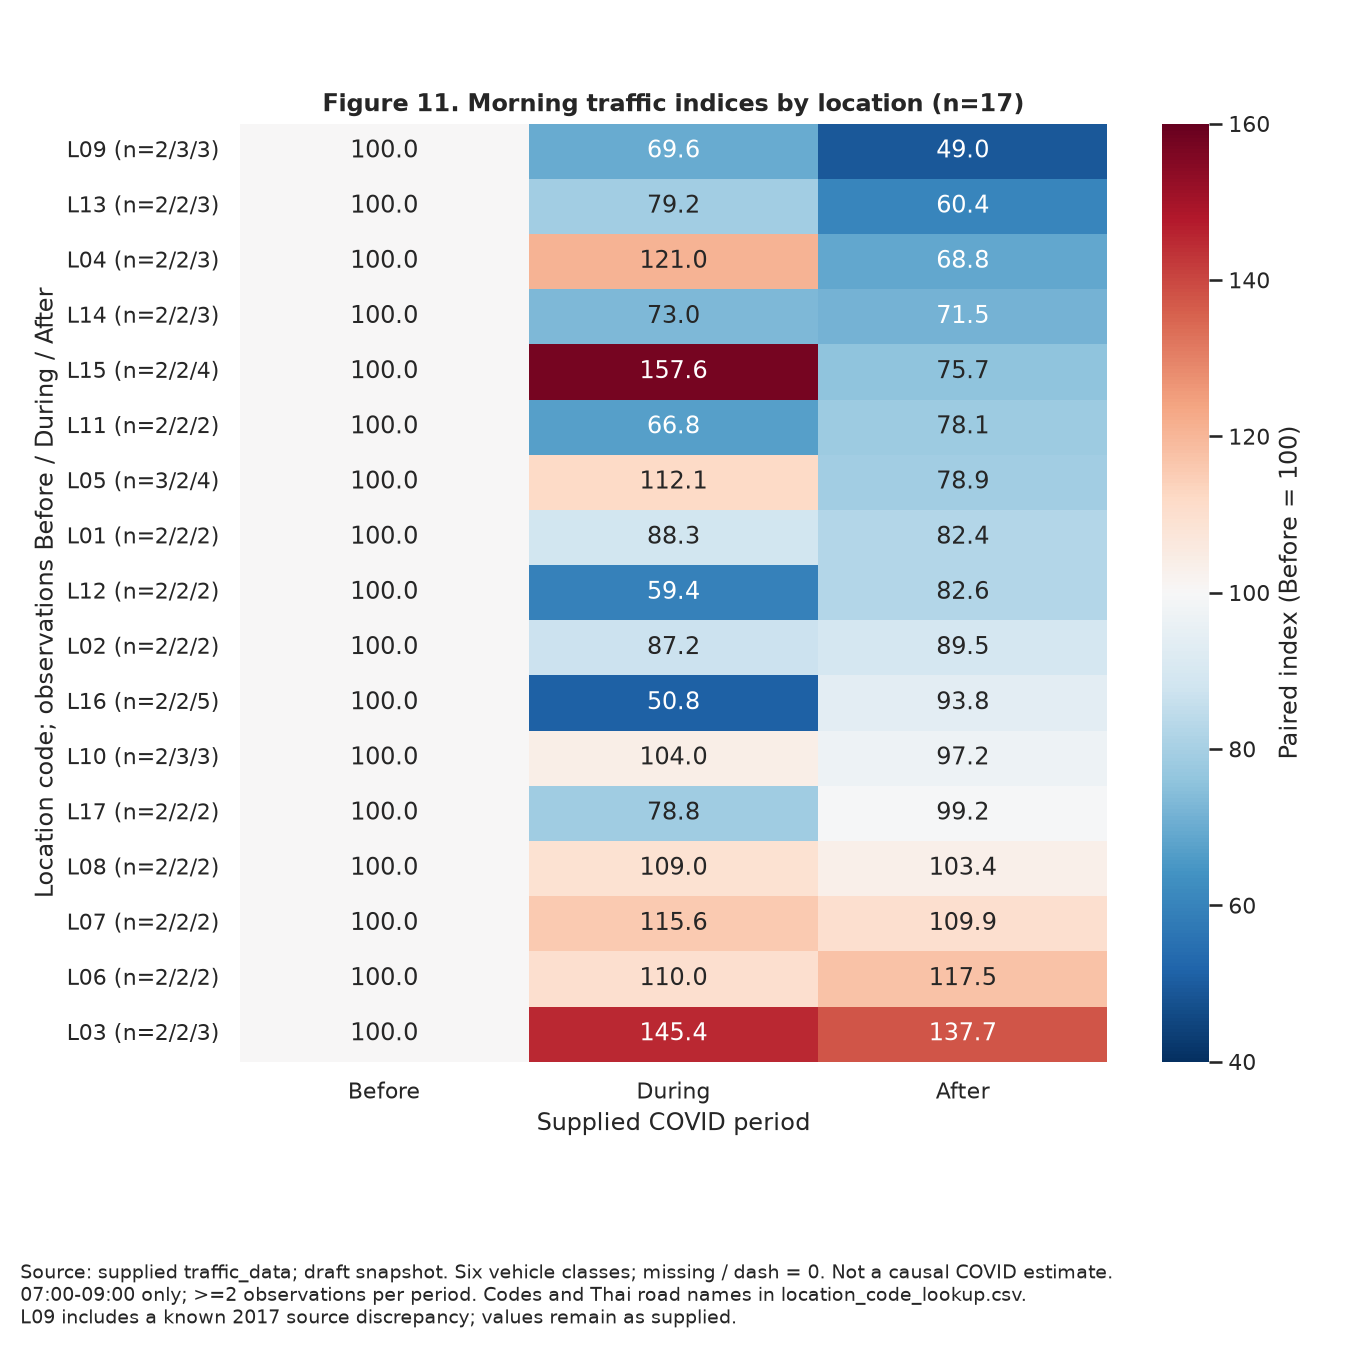

In [25]:
display(Image(filename=str(ROOT/'outputs/additional_visuals/figures'/'11_location_period_heatmap.png'), width=1050))

### วันสำรวจจริงรายสถานที่

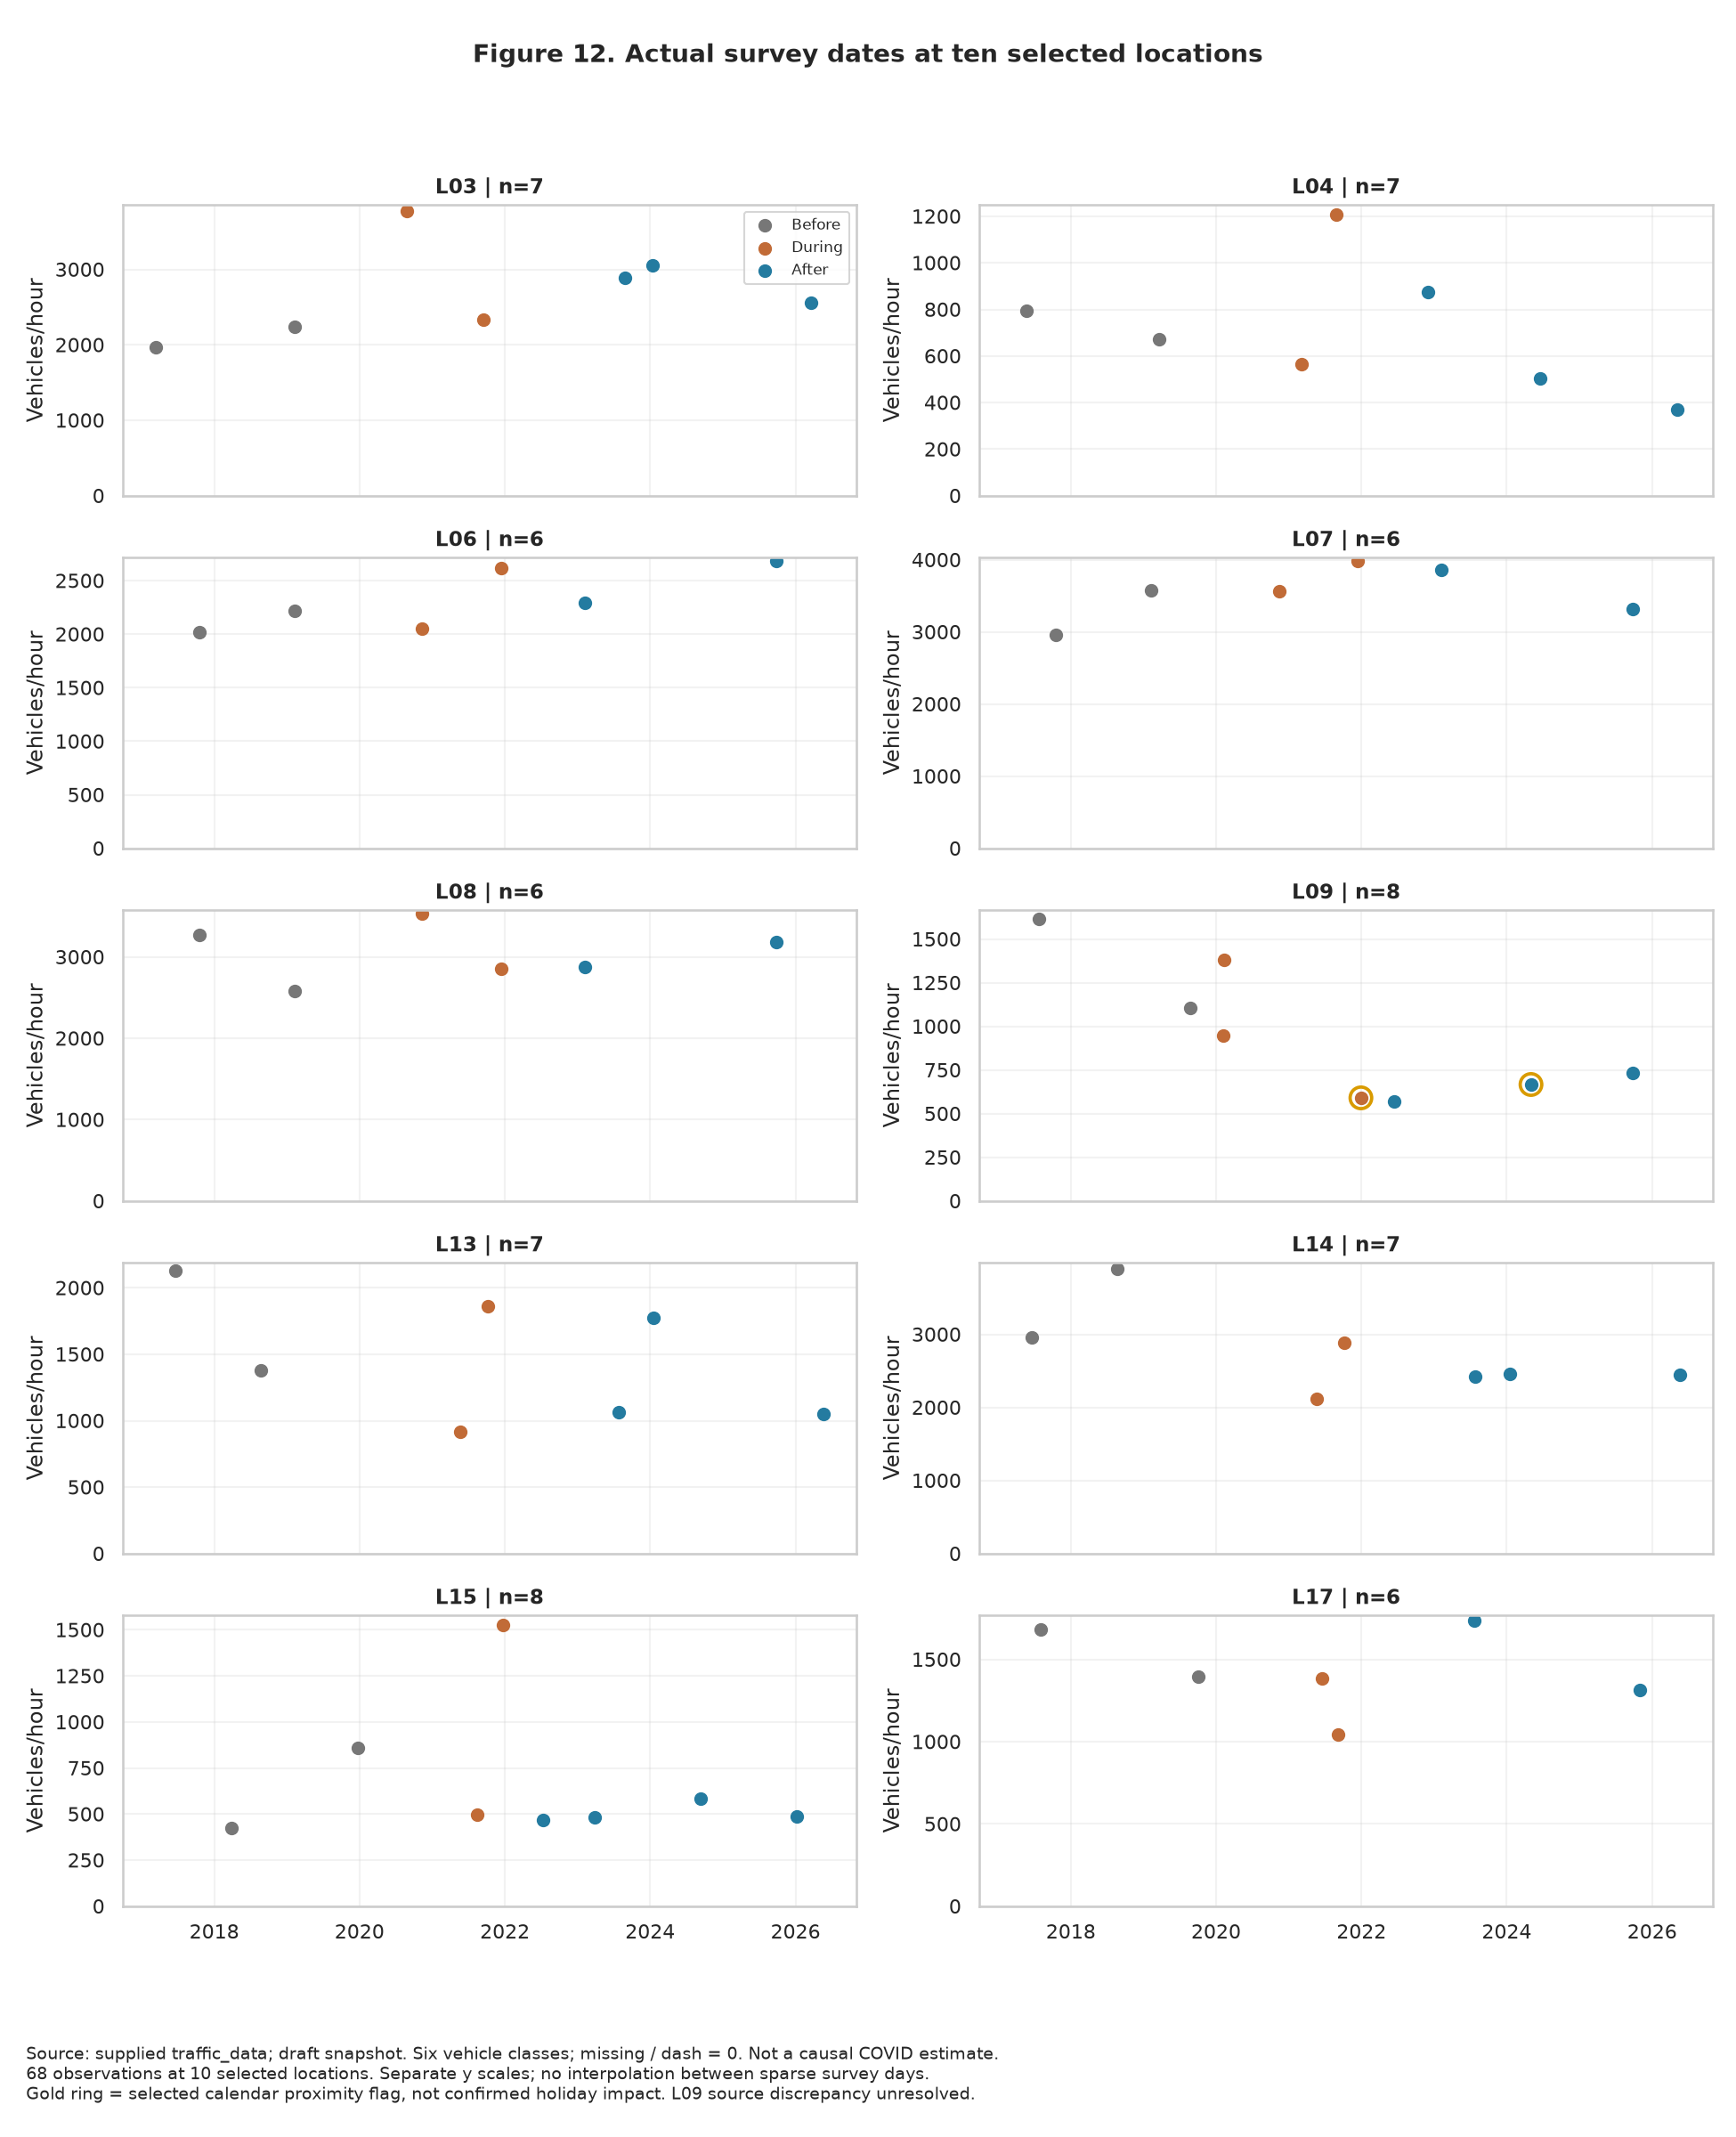

In [26]:
display(Image(filename=str(ROOT/'outputs/additional_visuals/figures'/'12_case_survey_dates.png'), width=1050))

### ปริมาณฐานกับการเปลี่ยนแปลงรายสถานที่

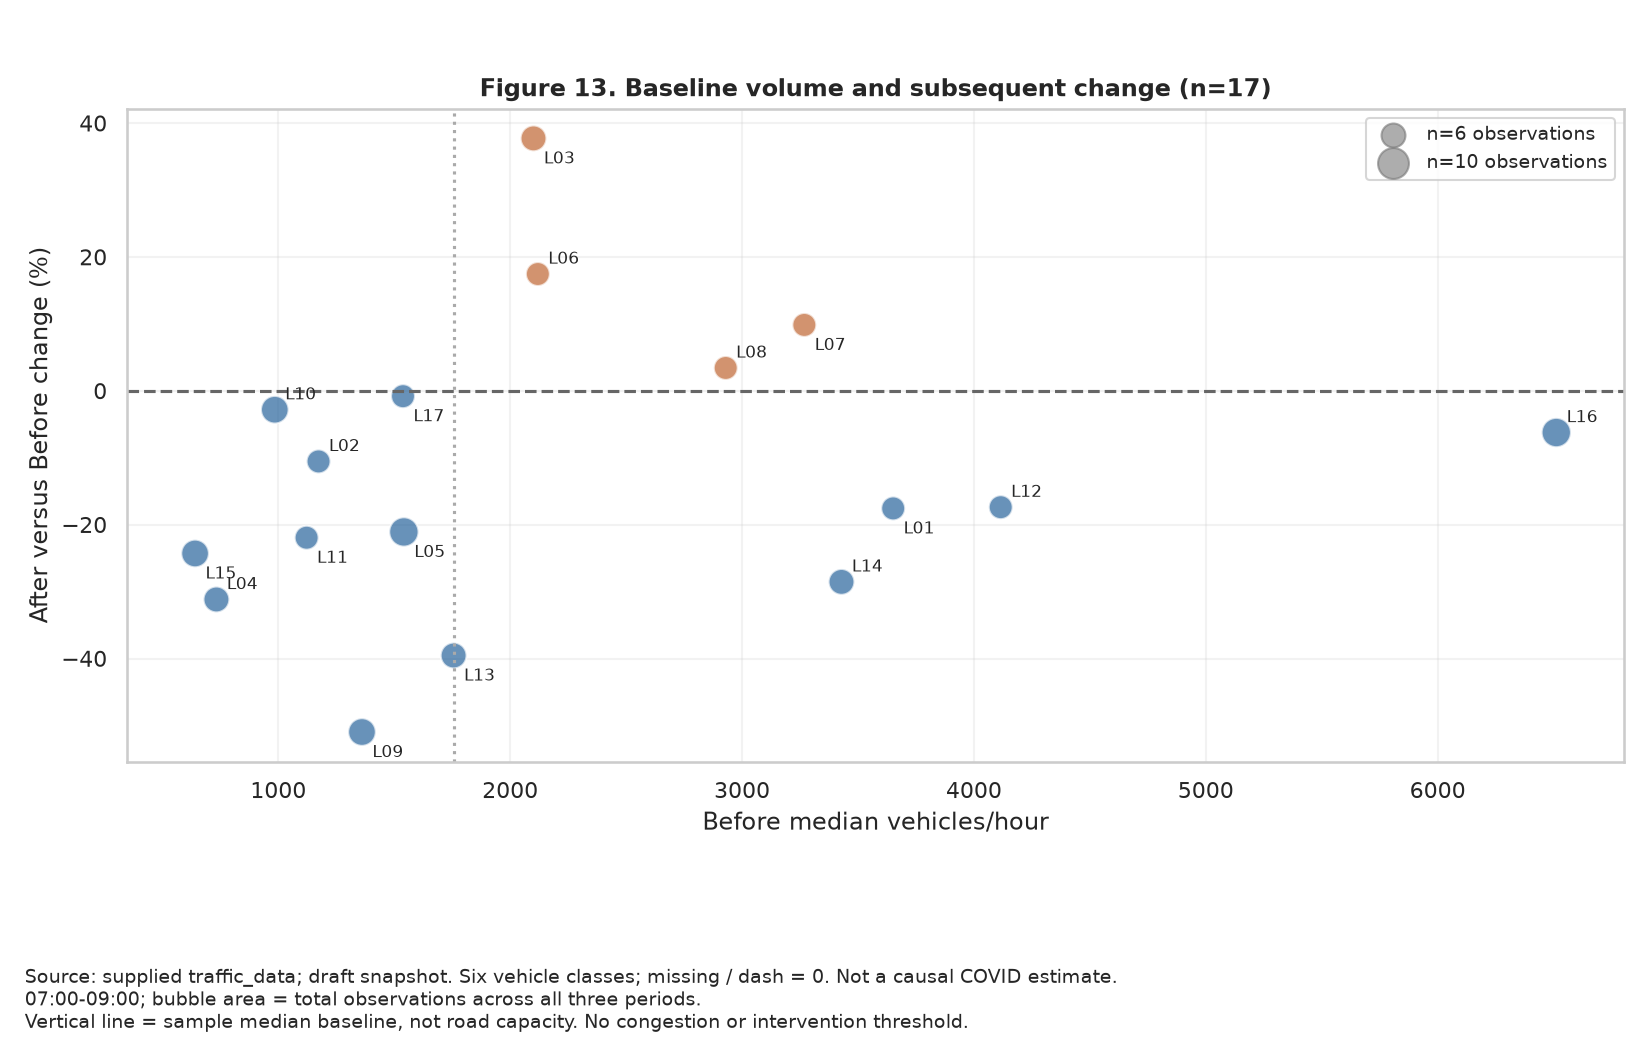

In [27]:
display(Image(filename=str(ROOT/'outputs/additional_visuals/figures'/'13_location_bubbles.png'), width=1050))

### ผลต่างค่าเฉลี่ยแยกประเภทรถ

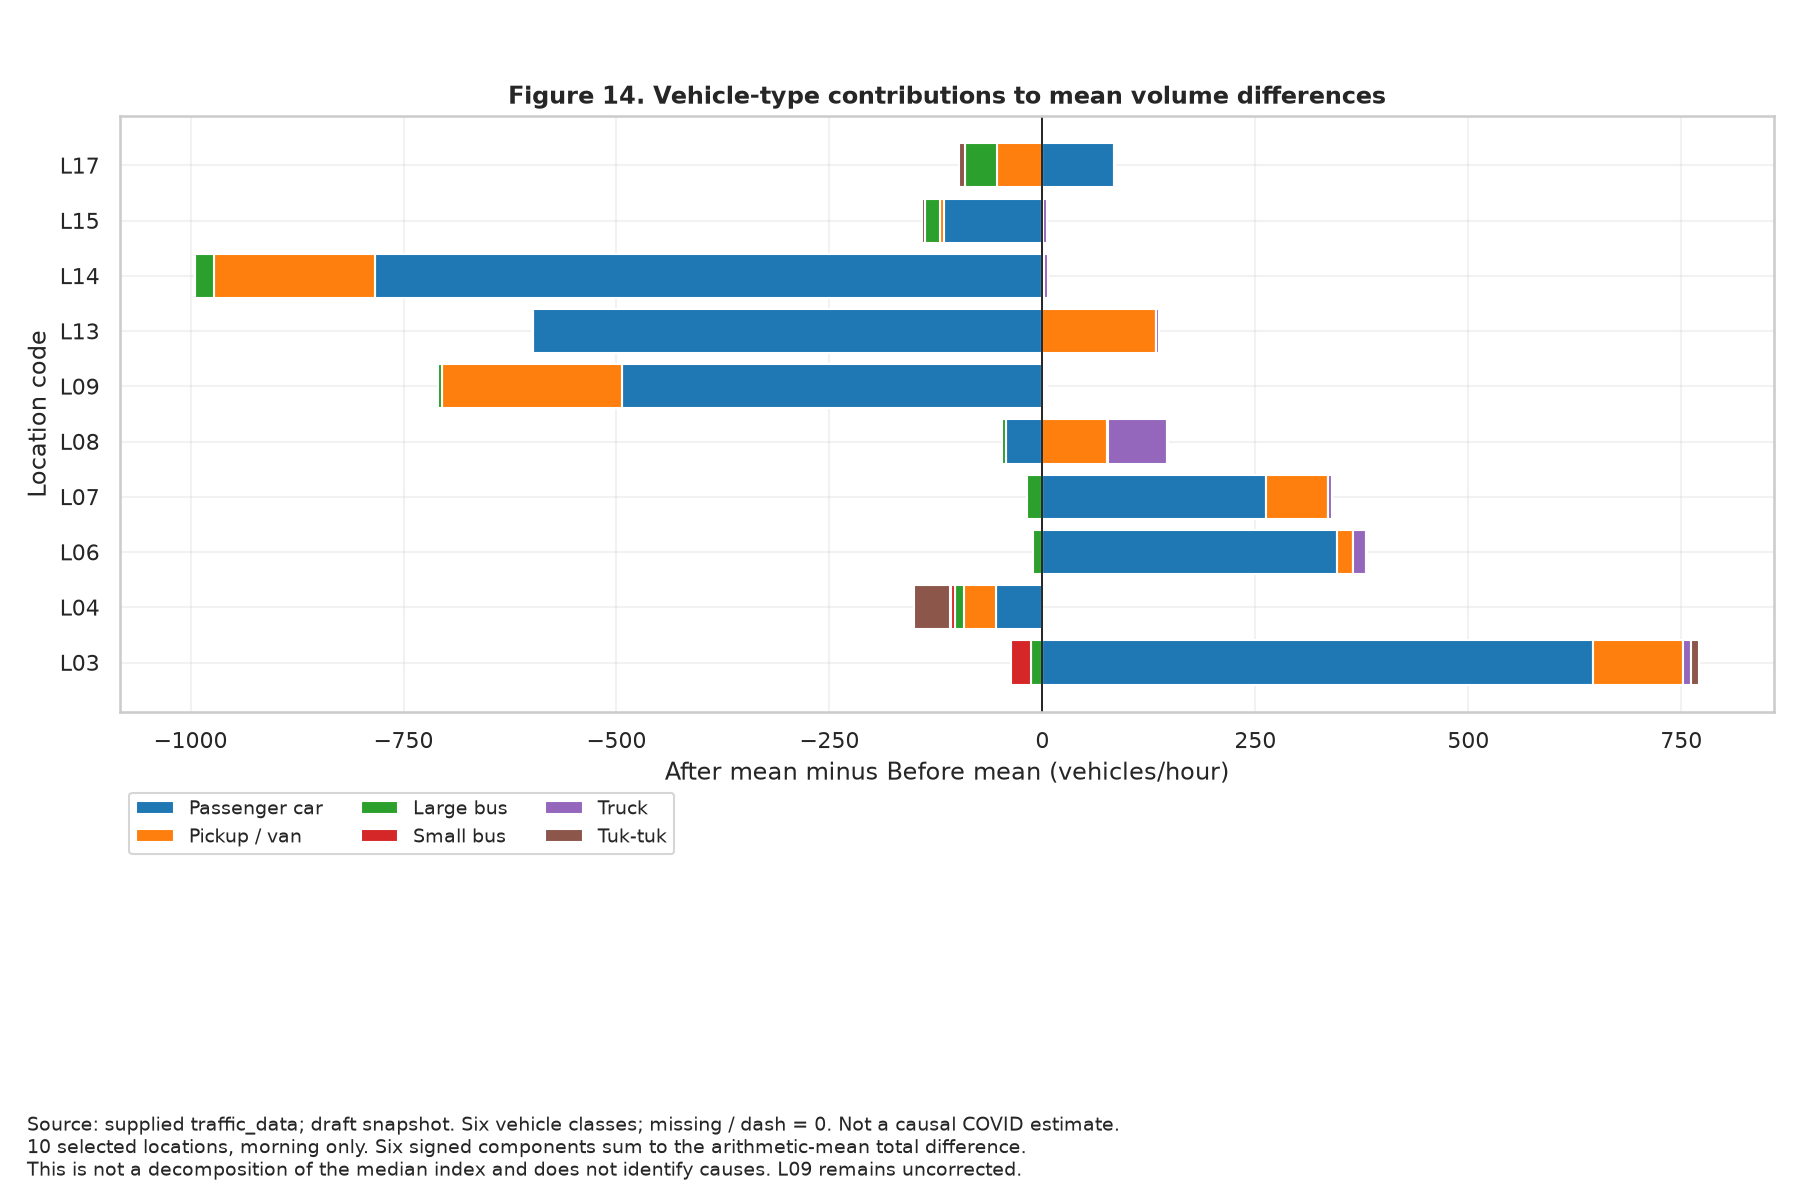

In [28]:
display(Image(filename=str(ROOT/'outputs/additional_visuals/figures'/'14_vehicle_contributions.png'), width=1050))

### ดัชนีพร้อมช่วงความไม่แน่นอน

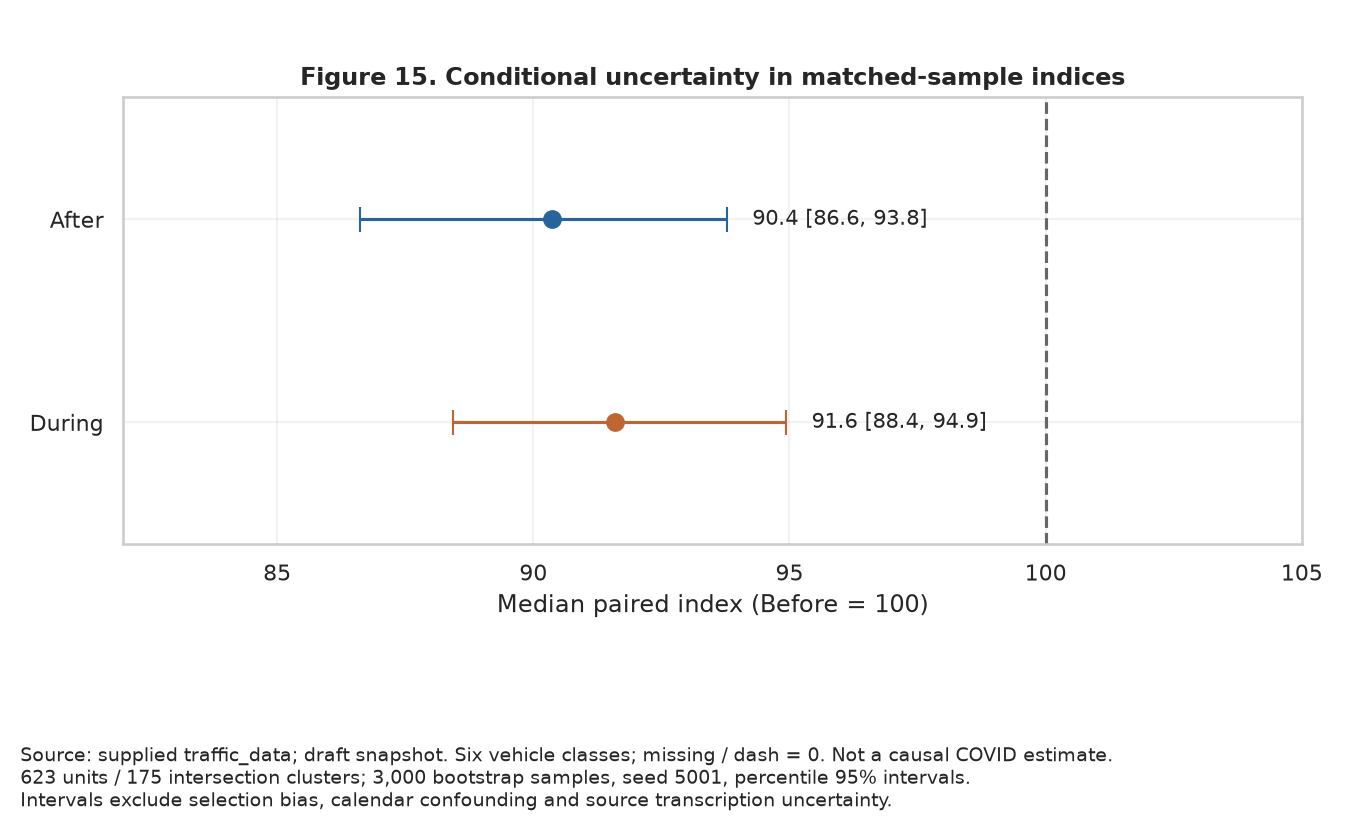

In [29]:
display(Image(filename=str(ROOT/'outputs/additional_visuals/figures'/'15_cluster_uncertainty.png'), width=1050))

### แผนที่กรุงเทพฯ เฉพาะทางแยกที่ตรวจพิกัดได้

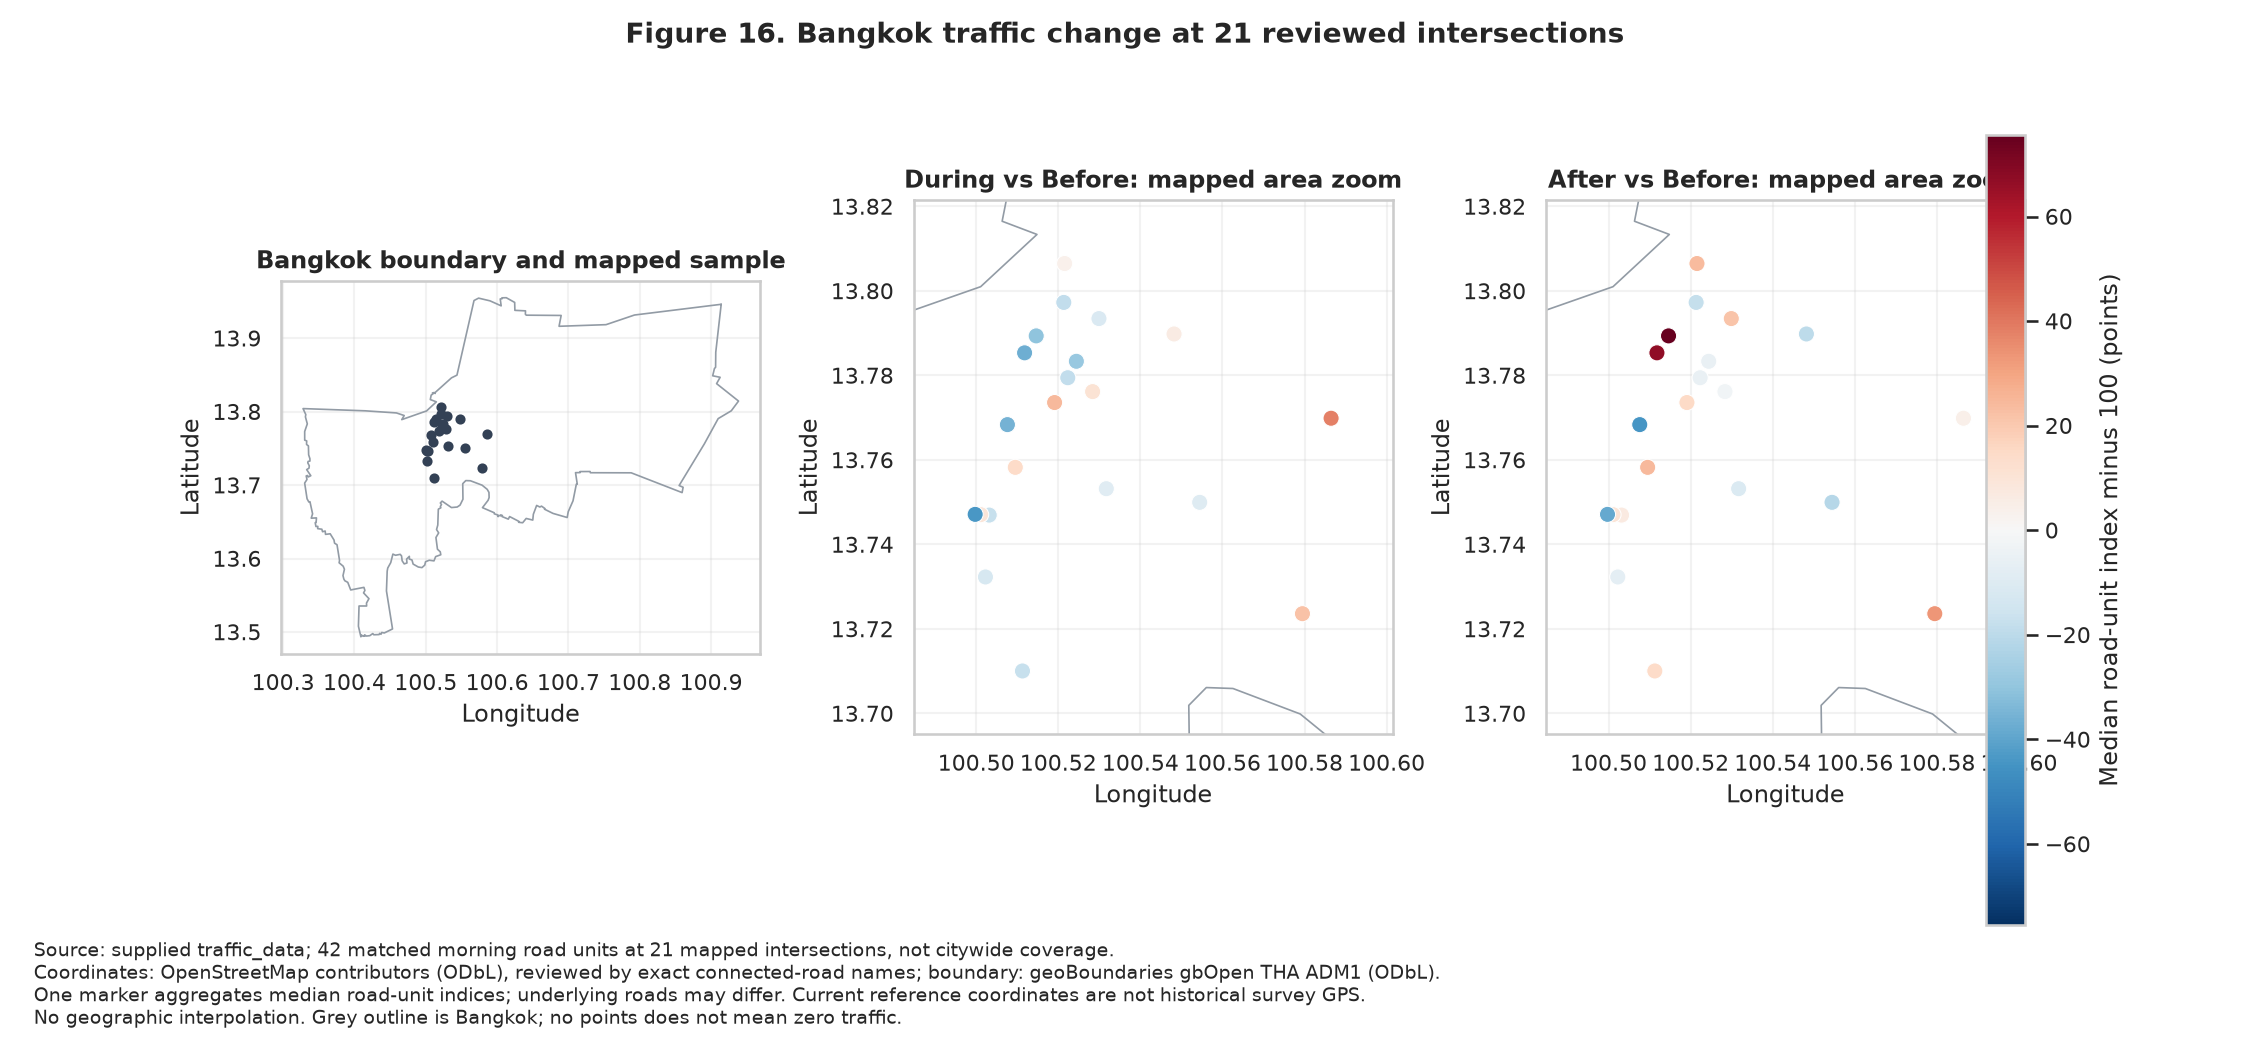

In [30]:
display(Image(filename=str(ROOT/'outputs/additional_visuals/figures'/'16_bangkok_matched_map.png'), width=1050))

In [31]:
display(pd.read_csv(ROOT/'outputs/additional_visuals/location_code_lookup.csv'))
display(pd.read_csv(ROOT/'outputs/additional_visuals/map_road_period_indices.csv'))

,intersection_key,road_key,Before,During,After,after_change_pct,location_code,n_Before,n_During,n_After
0,ถนนตก,พระรามที่ 3,3651.75,3224.00,3010.25,-17.566920,L01,2,2,2
1,ถนนตก,เจริญกรุง,1173.50,1023.50,1049.75,-10.545377,L02,2,2,2
2,บางขุนนนท์,จรัญสนิทวงศ์,2100.50,3054.00,2893.00,37.729112,L03,2,2,3
3,บางยี่เรือ,เทอดไท,733.00,887.00,504.50,-31.173261,L04,2,2,3
4,ประชาอุทิศ,ประชาอุทิศ,1541.50,1727.50,1216.50,-21.083360,L05,3,2,4
...,...,...,...,...,...,...,...,...,...,...
12,หลักสี่,กำแพงเพชร 6,1756.00,1391.00,1061.50,-39.550114,L13,2,2,3
13,หลักสี่,แจ้งวัฒนะ,3428.75,2503.25,2450.00,-28.545388,L14,2,2,3
14,ห้วยขวาง,ประชาสงเคราะห์,641.00,1010.50,485.25,-24.297972,L15,2,2,4
15,ห้วยขวาง,รัชดาภิเษก,6511.50,3306.75,6106.00,-6.227444,L16,2,2,5


,intersection_key,road_key,time_key,Before,During,...,accepted,review_rule,osm_url,access_date,inside_bangkok_boundary
0,จักรพรรดิพงษ์,จักรพรรดิพงษ์,07:00-09:00,100.0,94.441857,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/1699503382,2026-09-14,True
1,จักรพรรดิพงษ์,นครสวรรค์,07:00-09:00,100.0,134.873749,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/1699503382,2026-09-14,True
2,ตรอกจันทน์,จันทน์,07:00-09:00,100.0,92.031250,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/3495383061,2026-09-14,True
3,ตรอกจันทน์,เจริญกรุง,07:00-09:00,100.0,72.908672,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/3495383061,2026-09-14,True
4,ทองหล่อ,สุขุมวิท,07:00-09:00,100.0,121.852108,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/303606610,2026-09-14,True
...,...,...,...,...,...,...,...,...,...,...,...
37,เกียกกาย,ทหาร,07:00-09:00,100.0,203.069577,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/373456028,2026-09-14,True
38,เกียกกาย,ประชาราษฎร์สาย 1,07:00-09:00,100.0,74.348291,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/373456028,2026-09-14,True
39,เกียกกาย,สามเสน,07:00-09:00,100.0,81.403509,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/373456028,2026-09-14,True
40,เฉลิมกรุง,ตรีเพชร,07:00-09:00,100.0,51.633133,...,True,exact intersection after prefix removal AND ex...,https://www.openstreetmap.org/node/13167186218,2026-09-14,True


คำอธิบายกราฟพร้อมวิธีอ่าน ผลและข้อจำกัดอยู่ใน outputs/additional_visuals/Graph_Guide.md ภายใน ZIP; ตารางรายถนนแสดงลิงก์พิกัด OSM สำหรับตรวจย้อน

In [32]:
from zipfile import ZipFile, ZIP_DEFLATED
archive = ROOT.parent / 'bangkok_traffic_results.zip'
with ZipFile(archive, 'w', ZIP_DEFLATED) as z:
    for folder in [ROOT / 'outputs', ROOT / 'data/processed', ROOT / 'data/reference']:
        for path in folder.rglob('*'):
            if path.is_file():
                z.write(path, path.relative_to(ROOT))
print('Results ZIP:', archive.name)
if IN_COLAB:
    print('เปิดแถบ Files ทางซ้าย แล้วดาวน์โหลด bangkok_traffic_results.zip')

Results ZIP: bangkok_traffic_results.zip
